In [ ]:
import sys
import os
import re
import json
import random
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import HTML, display
import html

import torch
from transformers import pipeline
from tqdm.auto import tqdm
from datasets import load_dataset

CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / "src").is_dir():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / "src").is_dir():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    raise FileNotFoundError(
        "Could not locate the project root containing the 'src' directory."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import load_prepared_splits
from src.utils import (
    build_ranking_specs,
    collect_token_indices_from_items,
    highlight_spans,
    make_json_serializable,
    mask_spans_in_text,
    predict_with_pipeline,
    rank_indices_by_score,
    save_aopc_outputs,
    select_top_fraction_indices,
    trim_char_span,
)

/opt/conda/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [ ]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Dataset and model
DATASET_NAME = "timonziegenbein/appropriateness-corpus"
MODEL_NAME = "timonziegenbein/appropriateness-classifier-binary"

# Columns
TEXT_COL = "post_text"
TEXT_NORM_COL = "text_norm"
LABEL_COL = "Inappropriateness"
ID_COL = "post_id"

# Class labels used by the Hugging Face classifier
APPROPRIATE_LABEL = "LABEL_0"
INAPPROPRIATE_LABEL = "LABEL_1"

# Inference settings
MAX_LENGTH = 512
BATCH_SIZE = 16

if torch.cuda.is_available():
    TORCH_DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    TORCH_DEVICE = torch.device("mps")
else:
    TORCH_DEVICE = torch.device("cpu")

DEVICE = TORCH_DEVICE

# Attention settings
ATTENTION_METHODS = ["last_cls", "rollout"]
QUANTILE_VALUES = [0.3, 0.4, 0.50, 0.60, 0.70, 0.80, 0.85, 0.90, 0.95]
WINDOW_SIZE_VALUES = [0, 1, 2, 3]

# Output
BASE_DIR = PROJECT_ROOT / "results"
OUTPUT_DIR = BASE_DIR / "attention_results"
BASE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Attention cache settings
CACHE_DIR = OUTPUT_DIR / "cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

DEV_ATTENTION_CACHE_PATH = CACHE_DIR / "attention_cache_dev_tp.json"
TEST_ATTENTION_CACHE_PATH = CACHE_DIR / "attention_cache_test_tp.json"

OVERWRITE_ATTENTION_CACHE = False

# AOPC evaluates ranking quality, not quantile/window-size config quality.
AOPC_FRACTIONS = [0.01, 0.05, 0.10, 0.20, 0.50]

# Minimal merging only for directly adjacent selected tokens.
# This is not a tuned window-size setting.
AOPC_WINDOW_SIZE = 0

# Random control runs.
AOPC_RANDOM_RUNS = 10
AOPC_RANDOM_SEED = SEED

AOPC_OUTPUT_DIR = OUTPUT_DIR / "aopc_ranking_evaluation"
AOPC_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Cache dir:", CACHE_DIR)
print("AOPC fractions:", AOPC_FRACTIONS)
print("AOPC output dir:", AOPC_OUTPUT_DIR)

print("Pipeline device:", DEVICE)
print("Torch device:", TORCH_DEVICE)

In [4]:
pipe = pipeline(
    "text-classification",
    model=MODEL_NAME,
    device=DEVICE,
    top_k=None,
    truncation=True,
    max_length=MAX_LENGTH
)

tokenizer = pipe.tokenizer
model = pipe.model
model.to(TORCH_DEVICE)
model.eval()

MASK_TOKEN = tokenizer.mask_token if tokenizer.mask_token is not None else "[MASK]"

print("Mask token:", MASK_TOKEN)
print("Model labels:", model.config.id2label)

Mask token: [MASK]
Model labels: {0: 'LABEL_0', 1: 'LABEL_1'}


# Load prepared Data

In [ ]:
df_all, train_df, val_df, test_df = load_prepared_splits()

print("All:", df_all.shape)
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)


print("Train confusion types:")
display(train_df["confusion_type"].value_counts())

print("Validation confusion types:")
display(val_df["confusion_type"].value_counts())

print("Test confusion types:")
display(test_df["confusion_type"].value_counts())

# Attention-based span localization

This notebook evaluates attention-based span localization for the document-level inappropriateness classifier.

The method uses only `post_text` as input. It extracts candidate spans from internal attention distributions and validates them by masking the extracted spans and measuring the resulting drop in the predicted probability of the inappropriate class.

Two attention aggregation strategies are compared:

- `last_cls`: Uses the final transformer layer and averages the attention heads from the classification token to all input tokens. This is a simple raw-attention strategy.
- `rollout`: Aggregates attention across layers by multiplying normalized attention matrices with residual connections. This follows the intuition of Attention Rollout, which estimates how information flows through multiple transformer layers.

Attention is used here only as a candidate-generation signal, not as a faithful explanation by itself. Prior work has shown that attention weights should not automatically be interpreted as explanations of model predictions. Therefore, the extracted spans are validated through perturbation masking.

References:
- Jain and Wallace (2019): *Attention is not Explanation*
- Abnar and Zuidema (2020): *Quantifying Attention Flow in Transformers*

## Quantile and window size

The attention-based approach extracts spans in two steps: first, it selects tokens with high attention scores, and second, it merges nearby selected tokens into spans.

### Quantile

The `quantile` controls how selective the method is when choosing tokens based on their attention scores. For each argument, the attention scores of all valid text tokens are considered and a quantile threshold is computed.

For example:

- `quantile = 0.80` selects tokens in the top 20% of the attention-score distribution.
- `quantile = 0.90` selects tokens in the top 10%.
- `quantile = 0.95` selects only the top 5%.

Thus, higher quantiles usually produce shorter and more focused spans, while lower quantiles produce longer and more inclusive spans.

Example:

Assume an argument has the following simplified token-level attention scores:

| Token | Score |
|---|---:|
| I | 0.01 |
| think | 0.03 |
| you | 0.12 |
| are | 0.04 |
| wrong | 0.15 |
| because | 0.02 |

With a high quantile, for example `quantile = 0.90`, only the strongest tokens such as `you` and `wrong` may be selected. With a lower quantile, more surrounding tokens may also be selected.

### Window size

In this notebook, `window_size` is used as a merge-gap parameter. It does **not** add a fixed number of tokens to the left and right of each selected token. Instead, it determines how many unselected tokens may lie between selected tokens for them to be merged into one span.

For example:

```text
selected_token   unselected_token   selected_token

In [9]:
@torch.no_grad()
def get_attention_data(text, method="rollout", max_length=MAX_LENGTH):
    """
    Compute token-level attention scores for one text.
    
    method:
    - "last_cls": final-layer CLS attention averaged over heads
    - "rollout": attention rollout across all transformer layers
    
    Returns tokenizer tokens, character offsets, valid token mask, and normalized scores.
    """
    enc = tokenizer(
        text,
        truncation=True,
        max_length=max_length,
        return_offsets_mapping=True,
        return_special_tokens_mask=True,
        return_tensors="pt"
    )
    
    offset_mapping = enc.pop("offset_mapping")[0].tolist()
    special_tokens_mask = enc.pop("special_tokens_mask")[0].tolist()
    
    input_ids = enc["input_ids"][0].tolist()
    tokens = tokenizer.convert_ids_to_tokens(input_ids)
    
    enc = {k: v.to(TORCH_DEVICE) for k, v in enc.items()}
    
    outputs = model(**enc, output_attentions=True)
    attentions = outputs.attentions
    
    if attentions is None:
        raise ValueError("No attentions returned. Check whether output_attentions=True is supported.")
    
    # Each layer has shape: (batch, heads, seq_len, seq_len)
    attn_layers = [a[0].detach().cpu() for a in attentions]
    seq_len = attn_layers[0].shape[-1]
    cls_idx = 0
    
    if method == "last_cls":
        # Final layer, averaged over heads, CLS row.
        A = attn_layers[-1].mean(dim=0)
        scores = A[cls_idx].numpy()
    
    elif method == "rollout":
        # Attention rollout: average heads, add residual identity, row-normalize, multiply through layers.
        result = torch.eye(seq_len)
        
        for layer_attn in attn_layers:
            A = layer_attn.mean(dim=0)
            A = A + torch.eye(seq_len)
            A = A / A.sum(dim=-1, keepdim=True)
            result = A @ result
        
        scores = result[cls_idx].numpy()
    
    else:
        raise ValueError("method must be 'last_cls' or 'rollout'")
    
    valid_token_mask = []
    
    for i, (start, end) in enumerate(offset_mapping):
        is_real_text_token = (
            special_tokens_mask[i] == 0
            and end > start
            and start >= 0
            and end <= len(text)
        )
        valid_token_mask.append(is_real_text_token)
    
    valid_token_mask = np.array(valid_token_mask, dtype=bool)
    scores = np.array(scores, dtype=float)
    
    # Ignore special tokens.
    scores[~valid_token_mask] = 0.0
    
    # Normalize scores over real text tokens.
    total = scores[valid_token_mask].sum()
    if total > 0:
        scores = scores / total
    
    return {
        "text": text,
        "tokens": tokens,
        "offset_mapping": offset_mapping,
        "valid_token_mask": valid_token_mask,
        "attention_scores": scores,
        "method": method
    }

In [10]:
# Example
example_text = val_df.iloc[0][TEXT_COL]
predict_with_pipeline(example_text)
attn_data = get_attention_data(example_text, method="rollout")

pd.DataFrame({
    "token": attn_data["tokens"],
    "offset": attn_data["offset_mapping"],
    "valid": attn_data["valid_token_mask"],
    "score": attn_data["attention_scores"]
}).head(20)

Classifier inference:   0%|          | 0/17 [00:00<?, ?it/s]

,token,offset,valid,score
0,[CLS],"[0, 0]",False,0.000000
1,▁The,"[0, 3]",True,0.026088
2,▁only,"[3, 8]",True,0.011467
3,▁other,"[8, 14]",True,0.008776
4,▁choices,"[14, 22]",True,0.010174
5,▁are,"[22, 26]",True,0.018643
6,",","[26, 27]",True,0.036741
7,▁adoption,"[27, 36]",True,0.011849
8,▁or,"[36, 39]",True,0.016103
9,▁keep,"[39, 44]",True,0.008445


## Functions for precomputing and caching attention data

In [11]:
def serialize_attention_data(attn_data):
    """
    Convert attention data to a JSON-serializable format.
    """
    serialized = dict(attn_data)
    
    serialized["valid_token_mask"] = np.asarray(
        serialized["valid_token_mask"]
    ).astype(bool).tolist()
    
    serialized["attention_scores"] = np.asarray(
        serialized["attention_scores"]
    ).astype(float).tolist()
    
    serialized["offset_mapping"] = [
        [int(start), int(end)]
        for start, end in serialized["offset_mapping"]
    ]
    
    return serialized


def restore_attention_data(attn_data):
    """
    Restore cached attention data to the format expected by the extraction functions.
    """
    restored = dict(attn_data)
    
    restored["valid_token_mask"] = np.asarray(
        restored["valid_token_mask"],
        dtype=bool
    )
    
    restored["attention_scores"] = np.asarray(
        restored["attention_scores"],
        dtype=float
    )
    
    restored["offset_mapping"] = [
        tuple(offset)
        for offset in restored["offset_mapping"]
    ]
    
    return restored


def precompute_attention_cache(
    df,
    matrix_positions,
    attention_methods,
    cache_path=None,
    overwrite=False
):
    """
    Precompute attention data once per argument and attention method.

    The cache is keyed by global_row_id and attention_method.
    It can be reused for:
    - raw config search,
    - raw AOPC,
    - word-boundary config search,
    - word-boundary AOPC.
    """
    if cache_path is not None:
        cache_path = Path(cache_path)
        
        if cache_path.exists() and not overwrite:
            print("Loading attention cache from:", cache_path)
            
            with open(cache_path, "r", encoding="utf-8") as f:
                cache_items = json.load(f)
            
            attention_cache = {}
            
            for item in cache_items:
                global_row_id = int(item["global_row_id"])
                attention_cache[global_row_id] = {}
                
                for method, method_data in item["attention_data"].items():
                    if method_data.get("error") is not None:
                        attention_cache[global_row_id][method] = method_data
                    else:
                        attention_cache[global_row_id][method] = restore_attention_data(method_data)
            
            return attention_cache
    
    attention_cache = {}
    
    for matrix_pos in tqdm(matrix_positions, desc="Precomputing attention cache"):
        row = df.iloc[matrix_pos]
        global_row_id = int(row["global_row_id"])
        text = str(row[TEXT_NORM_COL])
        
        attention_cache[global_row_id] = {}
        
        for method in attention_methods:
            try:
                attn_data = get_attention_data(
                    text=text,
                    method=method,
                    max_length=MAX_LENGTH
                )
                
                attention_cache[global_row_id][method] = attn_data
            
            except Exception as e:
                attention_cache[global_row_id][method] = {
                    "error": str(e),
                    "text": text,
                    "tokens": [],
                    "offset_mapping": [],
                    "valid_token_mask": [],
                    "attention_scores": [],
                    "method": method
                }
    
    if cache_path is not None:
        cache_path.parent.mkdir(parents=True, exist_ok=True)
        
        serializable_cache = []
        
        for global_row_id, method_dict in attention_cache.items():
            serializable_methods = {}
            
            for method, attn_data in method_dict.items():
                if attn_data.get("error") is not None:
                    serializable_methods[method] = attn_data
                else:
                    serializable_methods[method] = serialize_attention_data(attn_data)
            
            serializable_cache.append({
                "global_row_id": int(global_row_id),
                "attention_data": serializable_methods
            })
        
        with open(cache_path, "w", encoding="utf-8") as f:
            json.dump(
                serializable_cache,
                f,
                ensure_ascii=False
            )
        
        print("Saved attention cache to:", cache_path)
    
    return attention_cache


def get_attention_data_for_row(row, method, attention_cache=None):
    """
    Return cached attention data if available. Otherwise compute it directly.
    """
    global_row_id = int(row["global_row_id"])
    
    if (
        attention_cache is not None
        and global_row_id in attention_cache
        and method in attention_cache[global_row_id]
    ):
        attn_data = attention_cache[global_row_id][method]
        
        if attn_data.get("error") is not None:
            raise RuntimeError(attn_data["error"])
        
        return attn_data
    
    text = str(row[TEXT_NORM_COL])
    
    return get_attention_data(
        text=text,
        method=method,
        max_length=MAX_LENGTH
    )

## Functions for Token Selection, Span Generation and Masking

In [ ]:
def selected_token_indices(attn_data, quantile):
    """Select valid tokens whose attention score is above the given quantile."""
    scores = attn_data["attention_scores"]
    valid = attn_data["valid_token_mask"]
    
    valid_scores = scores[valid]
    
    if len(valid_scores) == 0:
        return []
    
    threshold = np.quantile(valid_scores, quantile)
    selected = np.where((scores >= threshold) & valid)[0].tolist()
    
    return selected


def build_spans_from_selected_tokens(attn_data, selected_indices, window_size):
    """
    Build merged spans from selected attention tokens.
    
    In this attention setup, window_size is a merge-gap parameter:
    - window_size=0 merges only directly adjacent selected tokens.
    - window_size=1 also merges selected tokens with one unselected token in between.
    - window_size=2 allows up to two unselected tokens in between.
    
    This is not a symmetric left/right expansion as in the TF-IDF baseline.
    """
    text = attn_data["text"]
    tokens = attn_data["tokens"]
    offsets = attn_data["offset_mapping"]
    scores = attn_data["attention_scores"]
    
    if not selected_indices:
        return []
    
    selected_indices = sorted(selected_indices)
    
    groups = []
    current = [selected_indices[0]]
    
    for idx in selected_indices[1:]:
        previous = current[-1]
        
        if idx - previous <= window_size + 1:
            current.append(idx)
        else:
            groups.append(current)
            current = [idx]
    
    groups.append(current)
    
    spans = []
    
    for group in groups:
        token_start_idx = min(group)
        token_end_idx = max(group)
        
        char_start = offsets[token_start_idx][0]
        char_end = offsets[token_end_idx][1]
        char_start, char_end = trim_char_span(text, char_start, char_end)
        
        if char_end <= char_start:
            continue
        
        token_range = list(range(token_start_idx, token_end_idx + 1))
        selected_in_span = [idx for idx in group]
        
        spans.append({
            "char_start": int(char_start),
            "char_end": int(char_end),
            "token_start_idx": int(token_start_idx),
            "token_end_idx": int(token_end_idx),
            "span_text": text[char_start:char_end],
            "span_len_chars": int(char_end - char_start),
            "span_len_tokens": int(token_end_idx - token_start_idx + 1),
            "selected_token_indices": selected_in_span,
            "selected_token_texts": [tokens[idx] for idx in selected_in_span],
            "span_score_sum_attention": float(scores[selected_in_span].sum()),
            "span_score_mean_attention": float(scores[selected_in_span].mean()),
            "span_score_max_attention": float(scores[selected_in_span].max())
        })
    
    for span_idx, span in enumerate(spans):
        span["span_idx"] = int(span_idx)
    
    return spans

## Example

In [13]:
test_text = "You are a complete idiot and your argument makes no sense."

test_spans = [
    {
        "char_start": test_text.index("complete idiot"),
        "char_end": test_text.index("complete idiot") + len("complete idiot"),
        "span_text": "complete idiot",
        "span_len_tokens": 2
    },
    {
        "char_start": test_text.index("makes no sense"),
        "char_end": test_text.index("makes no sense") + len("makes no sense"),
        "span_text": "makes no sense",
        "span_len_tokens": 3
    }
]

print(mask_spans_in_text(
    text=test_text,
    spans=test_spans,
    mask_token=MASK_TOKEN
))

You are a [MASK] [MASK] and your argument [MASK] [MASK] [MASK].


## Application function

In [14]:
def run_attention_config_on_indices(
    df,
    matrix_positions,
    attention_methods,
    quantile_values,
    window_size_values,
    mask_token=MASK_TOKEN,
    attention_cache=None
):
    """
    Run attention span extraction and perturbation scoring.
    
    matrix_positions are split-local positions into df.
    global_row_id is stored as the stable identifier for downstream comparison.
    """
    all_results = []
    masked_texts_to_score = []
    masked_lookup = []
    
    for matrix_pos in tqdm(matrix_positions, desc="Building attention spans"):
        row = df.iloc[matrix_pos]
        
        text = str(row[TEXT_NORM_COL])
        label = int(row[LABEL_COL])
        
        for method in attention_methods:
            try:
                attn_data = get_attention_data_for_row(
                    row=row,
                    method=method,
                    attention_cache=attention_cache
                )
                
                n_model_tokens = int(attn_data["valid_token_mask"].sum())
                
                for quantile in quantile_values:
                    selected_indices = selected_token_indices(
                        attn_data=attn_data,
                        quantile=quantile
                    )
                    
                    for window_size in window_size_values:
                        merged_spans = build_spans_from_selected_tokens(
                            attn_data=attn_data,
                            selected_indices=selected_indices,
                            window_size=window_size
                        )
                        
                        masked_text = mask_spans_in_text(
                            text=text,
                            spans=merged_spans,
                            mask_token=mask_token
                        )
                        
                        total_masked_tokens = sum(
                            span["span_len_tokens"]
                            for span in merged_spans
                        )
                        total_masked_chars = sum(
                            span["span_len_chars"]
                            for span in merged_spans
                        )
                        
                        masked_token_ratio = (
                            total_masked_tokens / n_model_tokens
                            if n_model_tokens > 0
                            else 0.0
                        )
                        
                        selected_token_ratio = (
                            len(selected_indices) / n_model_tokens
                            if n_model_tokens > 0
                            else 0.0
                        )
                        
                        result = {
                            "global_row_id": int(row["global_row_id"]),
                            "split": row["split"],
                            "post_id": row[ID_COL] if ID_COL in df.columns else None,
                            "issue": row["issue"] if "issue" in df.columns else None,
                            
                            "label": label,
                            "predicted_label": row["predicted_label"],
                            "predicted_score": float(row["predicted_score"]),
                            "confusion_type": row["confusion_type"],
                            "is_true_positive": bool(row["is_true_positive"]),
                            "is_false_negative": bool(row["is_false_negative"]),
                            "is_false_positive": bool(row["is_false_positive"]),
                            "is_true_negative": bool(row["is_true_negative"]),
                            
                            "attention_method": method,
                            "quantile": float(quantile),
                            "window_size": int(window_size),
                            
                            "text": text,
                            "masked_text": masked_text,
                            
                            "p_inappropriate_original": float(row["p_inappropriate_original"]),
                            
                            "n_model_tokens": n_model_tokens,
                            "n_selected_tokens": int(len(selected_indices)),
                            "selected_token_ratio": float(selected_token_ratio),
                            
                            "n_merged_spans": int(len(merged_spans)),
                            "total_masked_tokens": int(total_masked_tokens),
                            "total_masked_chars": int(total_masked_chars),
                            "masked_token_ratio": float(masked_token_ratio),
                            
                            "selected_token_indices": selected_indices,
                            "selected_token_texts": [
                                attn_data["tokens"][idx]
                                for idx in selected_indices
                            ],
                            "merged_spans": merged_spans,
                            "error": None
                        }
                        
                        all_results.append(result)
                        masked_lookup.append(len(all_results) - 1)
                        masked_texts_to_score.append(masked_text)
            
            except Exception as e:
                result = {
                    "global_row_id": int(row["global_row_id"]),
                    "split": row["split"],
                    "post_id": row[ID_COL] if ID_COL in df.columns else None,
                    "issue": row["issue"] if "issue" in df.columns else None,
                    
                    "label": label,
                    "predicted_label": row["predicted_label"],
                    "predicted_score": float(row["predicted_score"]),
                    "confusion_type": row["confusion_type"],
                    "is_true_positive": bool(row["is_true_positive"]),
                    "is_false_negative": bool(row["is_false_negative"]),
                    "is_false_positive": bool(row["is_false_positive"]),
                    "is_true_negative": bool(row["is_true_negative"]),
                    
                    "attention_method": method,
                    "quantile": None,
                    "window_size": None,
                    
                    "text": text,
                    "masked_text": text,
                    
                    "p_inappropriate_original": float(row["p_inappropriate_original"]),
                    "p_inappropriate_masked": np.nan,
                    "predicted_label_masked": None,
                    "prob_drop": np.nan,
                    
                    "n_model_tokens": 0,
                    "n_selected_tokens": 0,
                    "selected_token_ratio": 0.0,
                    "n_merged_spans": 0,
                    "total_masked_tokens": 0,
                    "total_masked_chars": 0,
                    "masked_token_ratio": 0.0,
                    
                    "selected_token_indices": [],
                    "selected_token_texts": [],
                    "merged_spans": [],
                    "error": str(e)
                }
                all_results.append(result)
    
    if len(masked_texts_to_score) > 0:
        masked_predictions = predict_with_pipeline(
            masked_texts_to_score,
            batch_size=BATCH_SIZE
        )
        
        for result_idx, (_, pred_row) in zip(masked_lookup, masked_predictions.iterrows()):
            result = all_results[result_idx]
            p_masked = float(pred_row["p_inappropriate_original"])
            
            result["p_inappropriate_masked"] = p_masked
            result["predicted_label_masked"] = pred_row["predicted_label"]
            result["prob_drop"] = float(result["p_inappropriate_original"] - p_masked)
    
    return all_results

## Functions for building result dataframes

In [15]:
def build_argument_level_df(argument_results):
    """Flatten argument-level attention results for CSV export."""
    rows = []
    
    for result in argument_results:
        merged_span_texts = [span["span_text"] for span in result["merged_spans"]]
        merged_span_token_starts = [span["token_start_idx"] for span in result["merged_spans"]]
        merged_span_token_ends = [span["token_end_idx"] for span in result["merged_spans"]]
        merged_span_char_starts = [span["char_start"] for span in result["merged_spans"]]
        merged_span_char_ends = [span["char_end"] for span in result["merged_spans"]]
        
        rows.append({
            "global_row_id": result["global_row_id"],
            "split": result["split"],
            "post_id": result["post_id"],
            "issue": result["issue"],
            
            "label": result["label"],
            "predicted_label": result["predicted_label"],
            "predicted_score": result["predicted_score"],
            "confusion_type": result["confusion_type"],
            "is_true_positive": result["is_true_positive"],
            "is_false_negative": result["is_false_negative"],
            "is_false_positive": result["is_false_positive"],
            "is_true_negative": result["is_true_negative"],
            
            "attention_method": result["attention_method"],
            "quantile": result["quantile"],
            "window_size": result["window_size"],
            
            "p_inappropriate_original": result["p_inappropriate_original"],
            "p_inappropriate_masked": result["p_inappropriate_masked"],
            "predicted_label_masked": result["predicted_label_masked"],
            "prob_drop": result["prob_drop"],
            
            "n_model_tokens": result["n_model_tokens"],
            "n_selected_tokens": result["n_selected_tokens"],
            "selected_token_ratio": result["selected_token_ratio"],

            "word_boundary_postprocessed": result.get("word_boundary_postprocessed", False),
            "drop_punctuation_only_spans": result.get("drop_punctuation_only_spans", None),
            "word_boundary_fallback_used": result.get("word_boundary_fallback_used", False),
            "n_merged_spans_original_attention": result.get("n_merged_spans_original_attention", None),
            "n_merged_spans_word_boundary_before_fallback": result.get("n_merged_spans_word_boundary_before_fallback", None),
            
            "n_merged_spans": result["n_merged_spans"],
            "total_masked_tokens": result["total_masked_tokens"],
            "total_masked_chars": result["total_masked_chars"],
            "masked_token_ratio": result["masked_token_ratio"],
            
            "selected_token_indices": result["selected_token_indices"],
            "selected_token_texts": result["selected_token_texts"],
            
            "merged_span_texts": merged_span_texts,
            "merged_span_token_start_indices": merged_span_token_starts,
            "merged_span_token_end_indices": merged_span_token_ends,
            "merged_span_char_start_indices": merged_span_char_starts,
            "merged_span_char_end_indices": merged_span_char_ends,
            
            "selected_tokens_json": json.dumps(result["selected_token_texts"], ensure_ascii=False),
            "merged_spans_json": json.dumps(result["merged_spans"], ensure_ascii=False),
            
            "text": result["text"],
            "masked_text": result["masked_text"],
            "error": result["error"]
        })
    
    return pd.DataFrame(rows)


def build_span_level_df(argument_results):
    """Flatten span-level attention results for CSV export."""
    span_rows = []
    
    for result in argument_results:
        for span in result["merged_spans"]:
            span_rows.append({
                "global_row_id": result["global_row_id"],
                "split": result["split"],
                "post_id": result["post_id"],
                "issue": result["issue"],
                
                "label": result["label"],
                "predicted_label": result["predicted_label"],
                "confusion_type": result["confusion_type"],
                "is_true_positive": result["is_true_positive"],
                "is_false_negative": result["is_false_negative"],
                "is_false_positive": result["is_false_positive"],
                "is_true_negative": result["is_true_negative"],
                
                "attention_method": result["attention_method"],
                "quantile": result["quantile"],
                "window_size": result["window_size"],
                
                "span_idx": span["span_idx"],
                "span_text": span["span_text"],
                "char_start": span["char_start"],
                "char_end": span["char_end"],
                "token_start_idx": span["token_start_idx"],
                "token_end_idx": span["token_end_idx"],
                "span_len_chars": span["span_len_chars"],
                "span_len_tokens": span["span_len_tokens"],
                
                "selected_token_indices": span["selected_token_indices"],
                "selected_token_texts": span["selected_token_texts"],
                "span_score_sum_attention": span["span_score_sum_attention"],
                "span_score_mean_attention": span["span_score_mean_attention"],
                "span_score_max_attention": span["span_score_max_attention"],
                
                "p_inappropriate_original": result["p_inappropriate_original"],
                "p_inappropriate_masked": result["p_inappropriate_masked"],
                "prob_drop": result["prob_drop"],
                
                "n_model_tokens": result["n_model_tokens"],
                "n_selected_tokens": result["n_selected_tokens"],
                "selected_token_ratio": result["selected_token_ratio"],
                "masked_token_ratio": result["masked_token_ratio"],
                
                "text": result["text"],
                "masked_text": result["masked_text"]
            })
    
    return pd.DataFrame(span_rows)

# Building dev set

In [16]:
dev_df = pd.concat(
    [train_df, val_df],
    ignore_index=True
)

train_tp_positions = train_df.index[
    train_df["confusion_type"] == "TP"
].tolist()

val_tp_positions = val_df.index[
    val_df["confusion_type"] == "TP"
].tolist()

dev_tp_positions = dev_df.index[
    dev_df["confusion_type"] == "TP"
].tolist()

print("Training examples:", len(train_df))
print("Training true positives:", len(train_tp_positions))
print("Validation examples:", len(val_df))
print("Validation true positives:", len(val_tp_positions))

Training examples: 1533
Training true positives: 785
Validation examples: 220
Validation true positives: 88


# AOPC ranking evaluation for Attention

AOPC evaluates the quality of the underlying token ranking, independently of the later span configuration.

For the attention-based method, tokens are ranked by their attention scores. Then fixed fractions of the highest-ranked tokens are selected and masked. This differs from the quantile/window-size config search: AOPC does not tune a span configuration, but tests whether the ranking itself identifies tokens whose removal decreases the model's predicted probability for the inappropriate class.

Because this notebook uses both raw attention spans and word-boundary post-processing, AOPC is computed in two variants:

1. `raw_attention`: selected attention tokens are masked directly after minimal adjacent-token merging.
2. `word_boundary`: selected attention tokens are first expanded to readable word boundaries, punctuation-only spans are handled by the fallback rule, and then the resulting spans are masked.

A random ranking baseline is included for both variants using the same perturbation budgets.

## Precompute and cache attention data

In [17]:
dev_attention_cache = precompute_attention_cache(
    df=dev_df,
    matrix_positions=dev_tp_positions,
    attention_methods=ATTENTION_METHODS,
    cache_path=DEV_ATTENTION_CACHE_PATH,
    overwrite=OVERWRITE_ATTENTION_CACHE
)

Precomputing attention cache:   0%|          | 0/873 [00:00<?, ?it/s]

Saved attention cache to: attention_results_aopc/cache/attention_cache_dev_tp.json


## AOPC functions

In [ ]:
def build_aopc_attention_spans(
    attn_data,
    selected_token_indices_by_rank,
    use_word_boundary=False
):
    """
    Build AOPC spans from selected attention-token indices.
    
    For AOPC, window_size is fixed to AOPC_WINDOW_SIZE and is not tuned.
    If use_word_boundary=True, the raw token spans are post-processed to
    readable word boundaries.
    """
    text = attn_data["text"]
    
    selected_token_indices_in_text_order = sorted(selected_token_indices_by_rank)
    
    raw_spans = build_spans_from_selected_tokens(
        attn_data=attn_data,
        selected_indices=selected_token_indices_in_text_order,
        window_size=AOPC_WINDOW_SIZE
    )
    
    word_boundary_fallback_used = False
    
    if not use_word_boundary:
        return raw_spans, word_boundary_fallback_used
    
    boundary_spans_before_fallback = apply_word_boundary_to_spans(
        text=text,
        merged_spans=raw_spans,
        drop_punctuation_only=DROP_PUNCTUATION_ONLY_SPANS
    )
    
    boundary_spans = boundary_spans_before_fallback
    
    # Same fallback rule as in the main word-boundary config search.
    if len(boundary_spans_before_fallback) == 0 and len(raw_spans) > 0:
        boundary_spans = raw_spans
        word_boundary_fallback_used = True
    
    return boundary_spans, word_boundary_fallback_used

In [ ]:
def run_attention_aopc_on_indices(
    df,
    matrix_positions,
    attention_methods,
    fractions=AOPC_FRACTIONS,
    random_runs=AOPC_RANDOM_RUNS,
    random_seed=AOPC_RANDOM_SEED,
    mask_token=MASK_TOKEN,
    attention_cache=None,
    use_word_boundary=False
):
    """
    Run AOPC ranking evaluation for attention.

    This evaluates raw ranking quality:
    - no quantile tuning
    - no window-size tuning
    - no final span configuration selection

    The same function can evaluate raw attention masking and word-boundary
    post-processed masking.
    """
    rng = np.random.default_rng(random_seed)
    
    aopc_variant = "word_boundary" if use_word_boundary else "raw_attention"
    
    all_rows = []
    masked_texts_to_score = []
    masked_lookup = []
    
    for matrix_pos in tqdm(matrix_positions, desc=f"AOPC Attention ({aopc_variant})"):
        row = df.iloc[matrix_pos]
        text = str(row[TEXT_NORM_COL])
        label = int(row[LABEL_COL])
        
        for method in attention_methods:
            try:
                attn_data = get_attention_data_for_row(
                    row=row,
                    method=method,
                    attention_cache=attention_cache
                )
                
                n_model_tokens = int(attn_data["valid_token_mask"].sum())
                valid_token_indices = np.where(attn_data["valid_token_mask"])[0].tolist()

                attention_ranked_token_indices = rank_indices_by_score(
                    scores=attn_data["attention_scores"],
                    candidate_indices=valid_token_indices,
                )
                
                ranking_specs = build_ranking_specs(
                    primary_name="attention",
                    primary_ranked_indices=attention_ranked_token_indices,
                    candidate_indices=valid_token_indices,
                    random_runs=random_runs,
                    rng=rng,
                )
                
                for ranking_method, random_run, ranked_token_indices in ranking_specs:
                    for fraction in fractions:
                        selected_token_indices_by_rank = (
                            select_top_fraction_indices(
                                ranked_indices=ranked_token_indices,
                                total_items=n_model_tokens,
                                fraction=fraction,
                                min_k=1,
                            )
                        )
                        
                        selected_token_indices_in_text_order = sorted(
                            selected_token_indices_by_rank
                        )
                        
                        merged_spans, word_boundary_fallback_used = build_aopc_attention_spans(
                            attn_data=attn_data,
                            selected_token_indices_by_rank=selected_token_indices_by_rank,
                            use_word_boundary=use_word_boundary
                        )
                        
                        masked_text = mask_spans_in_text(
                            text=text,
                            spans=merged_spans,
                            mask_token=mask_token
                        )
                        
                        total_masked_tokens = sum(
                            span.get("span_len_tokens", 0)
                            for span in merged_spans
                        )
                        
                        total_masked_chars = sum(
                            span.get("span_len_chars", 0)
                            for span in merged_spans
                        )
                        
                        masked_token_ratio = (
                            total_masked_tokens / n_model_tokens
                            if n_model_tokens > 0
                            else 0.0
                        )
                        
                        selected_token_ratio = (
                            len(selected_token_indices_by_rank) / n_model_tokens
                            if n_model_tokens > 0
                            else 0.0
                        )
                        
                        result = {
                            "global_row_id": int(row["global_row_id"]),
                            "split": row["split"],
                            "post_id": row[ID_COL] if ID_COL in df.columns else None,
                            "issue": row["issue"] if "issue" in df.columns else None,
                            
                            "label": label,
                            "predicted_label": row["predicted_label"],
                            "predicted_score": float(row["predicted_score"]),
                            "confusion_type": row["confusion_type"],
                            "is_true_positive": bool(row["is_true_positive"]),
                            "is_false_negative": bool(row["is_false_negative"]),
                            "is_false_positive": bool(row["is_false_positive"]),
                            "is_true_negative": bool(row["is_true_negative"]),
                            
                            "aopc_variant": aopc_variant,
                            "attention_method": method,
                            "ranking_method": ranking_method,
                            "random_run": random_run,
                            
                            "perturbation_fraction": float(fraction),
                            "top_k_tokens": int(len(selected_token_indices_by_rank)),
                            "window_size": int(AOPC_WINDOW_SIZE),
                            
                            "word_boundary_postprocessed": bool(use_word_boundary),
                            "word_boundary_fallback_used": bool(word_boundary_fallback_used),
                            
                            "text": text,
                            "masked_text": masked_text,
                            
                            "p_inappropriate_original": float(row["p_inappropriate_original"]),
                            
                            "n_model_tokens": n_model_tokens,
                            "n_selected_tokens": int(len(selected_token_indices_by_rank)),
                            "selected_token_ratio": float(selected_token_ratio),
                            
                            "n_merged_spans": int(len(merged_spans)),
                            "total_masked_tokens": int(total_masked_tokens),
                            "total_masked_chars": int(total_masked_chars),
                            "masked_token_ratio": float(masked_token_ratio),
                            
                            "selected_token_indices_by_rank": [
                                int(idx) for idx in selected_token_indices_by_rank
                            ],
                            "selected_token_indices": [
                                int(idx) for idx in selected_token_indices_in_text_order
                            ],
                            "selected_token_texts": [
                                attn_data["tokens"][idx]
                                for idx in selected_token_indices_in_text_order
                            ],
                            "merged_spans": merged_spans,
                            "error": None
                        }
                        
                        all_rows.append(result)
                        masked_lookup.append(len(all_rows) - 1)
                        masked_texts_to_score.append(masked_text)
            
            except Exception as e:
                all_rows.append({
                    "global_row_id": int(row["global_row_id"]),
                    "split": row["split"],
                    "post_id": row[ID_COL] if ID_COL in df.columns else None,
                    "issue": row["issue"] if "issue" in df.columns else None,
                    "label": label,
                    "predicted_label": row["predicted_label"],
                    "predicted_score": float(row["predicted_score"]),
                    "confusion_type": row["confusion_type"],
                    "aopc_variant": aopc_variant,
                    "attention_method": method,
                    "ranking_method": "attention",
                    "random_run": None,
                    "perturbation_fraction": np.nan,
                    "top_k_tokens": 0,
                    "window_size": int(AOPC_WINDOW_SIZE),
                    "word_boundary_postprocessed": bool(use_word_boundary),
                    "word_boundary_fallback_used": False,
                    "text": text,
                    "masked_text": text,
                    "p_inappropriate_original": float(row["p_inappropriate_original"]),
                    "p_inappropriate_masked": np.nan,
                    "predicted_label_masked": None,
                    "prob_drop": np.nan,
                    "n_model_tokens": 0,
                    "n_selected_tokens": 0,
                    "selected_token_ratio": 0.0,
                    "n_merged_spans": 0,
                    "total_masked_tokens": 0,
                    "total_masked_chars": 0,
                    "masked_token_ratio": 0.0,
                    "selected_token_indices_by_rank": [],
                    "selected_token_indices": [],
                    "selected_token_texts": [],
                    "merged_spans": [],
                    "error": str(e)
                })
    
    if len(masked_texts_to_score) > 0:
        masked_predictions = predict_with_pipeline(
            masked_texts_to_score,
            batch_size=BATCH_SIZE
        )
        
        for result_idx, (_, pred_row) in zip(masked_lookup, masked_predictions.iterrows()):
            result = all_rows[result_idx]
            p_masked = float(pred_row["p_inappropriate_original"])
            
            result["p_inappropriate_masked"] = p_masked
            result["predicted_label_masked"] = pred_row["predicted_label"]
            result["prob_drop"] = float(result["p_inappropriate_original"] - p_masked)
    
    return pd.DataFrame(all_rows)

In [21]:
def summarize_attention_aopc_results(aopc_df):
    """
    Summarize Attention AOPC results.

    Random runs are averaged per argument and perturbation fraction before
    computing global summaries.
    """
    valid_df = aopc_df[
        aopc_df["error"].isna()
    ].copy()
    
    step_df = (
        valid_df
        .groupby(
            [
                "aopc_variant",
                "attention_method",
                "ranking_method",
                "global_row_id",
                "split",
                "post_id",
                "perturbation_fraction"
            ],
            as_index=False
        )
        .agg(
            prob_drop=("prob_drop", "mean"),
            p_inappropriate_original=("p_inappropriate_original", "first"),
            p_inappropriate_masked=("p_inappropriate_masked", "mean"),
            masked_token_ratio=("masked_token_ratio", "mean"),
            selected_token_ratio=("selected_token_ratio", "mean"),
            top_k_tokens=("top_k_tokens", "mean"),
            total_masked_tokens=("total_masked_tokens", "mean"),
            total_masked_chars=("total_masked_chars", "mean"),
            n_merged_spans=("n_merged_spans", "mean"),
            fallback_rate=("word_boundary_fallback_used", "mean"),
        )
    )
    
    curve_summary = (
        step_df
        .groupby(
            [
                "aopc_variant",
                "attention_method",
                "ranking_method",
                "perturbation_fraction"
            ],
            as_index=False
        )
        .agg(
            n_arguments=("global_row_id", "nunique"),
            mean_prob_drop=("prob_drop", "mean"),
            median_prob_drop=("prob_drop", "median"),
            std_prob_drop=("prob_drop", "std"),
            positive_drop_rate=("prob_drop", lambda x: float((x > 0).mean())),
            mean_p_original=("p_inappropriate_original", "mean"),
            mean_p_masked=("p_inappropriate_masked", "mean"),
            mean_masked_token_ratio=("masked_token_ratio", "mean"),
            median_masked_token_ratio=("masked_token_ratio", "median"),
            mean_selected_token_ratio=("selected_token_ratio", "mean"),
            mean_top_k_tokens=("top_k_tokens", "mean"),
            mean_total_masked_tokens=("total_masked_tokens", "mean"),
            mean_total_masked_chars=("total_masked_chars", "mean"),
            mean_n_merged_spans=("n_merged_spans", "mean"),
            fallback_rate=("fallback_rate", "mean"),
        )
    )
    
    per_argument_aopc = (
        step_df
        .groupby(
            [
                "aopc_variant",
                "attention_method",
                "ranking_method",
                "global_row_id",
                "split",
                "post_id"
            ],
            as_index=False
        )
        .agg(
            aopc_mean_prob_drop=("prob_drop", "mean"),
            aopc_median_prob_drop=("prob_drop", "median"),
            max_prob_drop=("prob_drop", "max"),
            min_prob_drop=("prob_drop", "min"),
            positive_steps_rate=("prob_drop", lambda x: float((x > 0).mean())),
            mean_masked_token_ratio=("masked_token_ratio", "mean"),
            max_masked_token_ratio=("masked_token_ratio", "max"),
            mean_total_masked_tokens=("total_masked_tokens", "mean"),
            fallback_rate=("fallback_rate", "mean"),
        )
    )
    
    global_summary = (
        per_argument_aopc
        .groupby(
            [
                "aopc_variant",
                "attention_method",
                "ranking_method"
            ],
            as_index=False
        )
        .agg(
            n_arguments=("global_row_id", "nunique"),
            aopc_mean_prob_drop=("aopc_mean_prob_drop", "mean"),
            aopc_median_prob_drop=("aopc_mean_prob_drop", "median"),
            aopc_std_prob_drop=("aopc_mean_prob_drop", "std"),
            mean_positive_steps_rate=("positive_steps_rate", "mean"),
            mean_masked_token_ratio=("mean_masked_token_ratio", "mean"),
            mean_max_masked_token_ratio=("max_masked_token_ratio", "mean"),
            mean_total_masked_tokens=("mean_total_masked_tokens", "mean"),
            fallback_rate=("fallback_rate", "mean"),
        )
        .sort_values(["aopc_variant", "attention_method", "ranking_method"])
    )
    
    return step_df, curve_summary, per_argument_aopc, global_summary

In [ ]:
def plot_attention_aopc_curve(curve_summary, output_dir, filename, title):
    """Plot AOPC curves."""
    plot_df = curve_summary.sort_values(
        [
            "aopc_variant",
            "attention_method",
            "ranking_method",
            "perturbation_fraction"
        ]
    ).copy()
    
    plt.figure(figsize=(9, 6))
    
    for (variant, method, ranking_method), subset in plot_df.groupby(
        ["aopc_variant", "attention_method", "ranking_method"]
    ):
        subset = subset.sort_values("perturbation_fraction")
        
        label = f"{variant} | {method} | {ranking_method}"
        
        plt.plot(
            subset["perturbation_fraction"],
            subset["mean_prob_drop"],
            marker="o",
            label=label
        )
    
    plt.axhline(0.0, linestyle="--", linewidth=1)
    plt.xlabel("Perturbation fraction of model tokens")
    plt.ylabel("Mean probability drop")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    
    plot_path = Path(output_dir) / filename
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Saved plot:", plot_path)


def plot_attention_aopc_global_bar(global_summary, output_dir, filename, title):
    """Plot global AOPC bar chart."""
    plot_df = global_summary.copy()
    plot_df["label"] = (
        plot_df["aopc_variant"]
        + " | "
        + plot_df["attention_method"]
        + " | "
        + plot_df["ranking_method"]
    )
    
    plot_df = plot_df.sort_values("label")
    
    plt.figure(figsize=(10, 5))
    
    plt.bar(
        plot_df["label"],
        plot_df["aopc_mean_prob_drop"]
    )
    
    plt.axhline(0.0, linestyle="--", linewidth=1)
    plt.xlabel("AOPC variant / method / ranking")
    plt.ylabel("AOPC mean probability drop")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y")
    
    plot_path = Path(output_dir) / filename
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Saved plot:", plot_path)

# Config Selection on dev set

In [23]:
dev_tp_results = run_attention_config_on_indices(
    df=dev_df,
    matrix_positions=dev_tp_positions,
    attention_methods=ATTENTION_METHODS,
    quantile_values=QUANTILE_VALUES,
    window_size_values=WINDOW_SIZE_VALUES,
    mask_token=MASK_TOKEN,
    attention_cache=dev_attention_cache
)

dev_tp_argument_df = build_argument_level_df(dev_tp_results)
dev_tp_span_df = build_span_level_df(dev_tp_results)

display(dev_tp_argument_df.head())
display(dev_tp_span_df.head())

Building attention spans:   0%|          | 0/873 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/3929 [00:00<?, ?it/s]

,global_row_id,split,post_id,issue,label,predicted_label,predicted_score,confusion_type,is_true_positive,is_false_negative,...,merged_span_texts,merged_span_token_start_indices,merged_span_token_end_indices,merged_span_char_start_indices,merged_span_char_end_indices,selected_tokens_json,merged_spans_json,text,masked_text,error
0,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,[people cant be forced to wear school uniforms...,"[1, 21, 27, 40]","[15, 21, 37, 41]","[0, 93, 119, 191]","[69, 97, 179, 204]","[""▁people"", ""▁can"", ""t"", ""▁be"", ""▁forced"", ""▁t...","[{""char_start"": 0, ""char_end"": 69, ""token_star...","people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None
1,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,[people cant be forced to wear school uniforms...,"[1, 21, 27, 40]","[15, 21, 37, 41]","[0, 93, 119, 191]","[69, 97, 179, 204]","[""▁people"", ""▁can"", ""t"", ""▁be"", ""▁forced"", ""▁t...","[{""char_start"": 0, ""char_end"": 69, ""token_star...","people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None
2,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,[people cant be forced to wear school uniforms...,"[1, 21, 27]","[15, 21, 41]","[0, 93, 119]","[69, 97, 204]","[""▁people"", ""▁can"", ""t"", ""▁be"", ""▁forced"", ""▁t...","[{""char_start"": 0, ""char_end"": 69, ""token_star...","people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None
3,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,[people cant be forced to wear school uniforms...,"[1, 21, 27]","[15, 21, 41]","[0, 93, 119]","[69, 97, 204]","[""▁people"", ""▁can"", ""t"", ""▁be"", ""▁forced"", ""▁t...","[{""char_start"": 0, ""char_end"": 69, ""token_star...","people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None
4,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,[people cant be forced to wear school uniforms...,"[1, 15, 21, 27, 36, 41]","[13, 15, 21, 34, 36, 41]","[0, 66, 93, 119, 167, 201]","[58, 69, 97, 156, 173, 204]","[""▁people"", ""▁can"", ""t"", ""▁be"", ""▁forced"", ""▁t...","[{""char_start"": 0, ""char_end"": 58, ""token_star...","people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None


,global_row_id,split,post_id,issue,label,predicted_label,confusion_type,is_true_positive,is_false_negative,is_false_positive,...,span_score_max_attention,p_inappropriate_original,p_inappropriate_masked,prob_drop,n_model_tokens,n_selected_tokens,selected_token_ratio,masked_token_ratio,text,masked_text
0,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,0.091563,0.997032,0.909959,0.087074,42,29,0.690476,0.690476,"people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...
1,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,0.018986,0.997032,0.909959,0.087074,42,29,0.690476,0.690476,"people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...
2,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,0.056030,0.997032,0.909959,0.087074,42,29,0.690476,0.690476,"people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...
3,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,0.017655,0.997032,0.909959,0.087074,42,29,0.690476,0.690476,"people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...
4,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,0.091563,0.997032,0.909959,0.087074,42,29,0.690476,0.690476,"people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...


In [24]:
dev_tp_argument_df_valid = dev_tp_argument_df[
    dev_tp_argument_df["error"].isna()
].copy()

dev_config_summary = (
    dev_tp_argument_df_valid
    .groupby(["attention_method", "window_size", "quantile"])
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        strong_drop_rate_001=("prob_drop", lambda x: (x > 0.01).mean()),
        strong_drop_rate_005=("prob_drop", lambda x: (x > 0.05).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_n_selected_tokens=("n_selected_tokens", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        median_total_masked_tokens=("total_masked_tokens", "median"),
        mean_total_masked_chars=("total_masked_chars", "mean"),
        mean_selected_token_ratio=("selected_token_ratio", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
        median_masked_token_ratio=("masked_token_ratio", "median"),
    )
    .reset_index()
)

span_len_summary = (
    dev_tp_span_df
    .groupby(["attention_method", "window_size", "quantile"])
    .agg(
        n_spans=("span_text", "count"),
        mean_span_len_tokens=("span_len_tokens", "mean"),
        median_span_len_tokens=("span_len_tokens", "median"),
        mean_span_len_chars=("span_len_chars", "mean"),
        median_span_len_chars=("span_len_chars", "median"),
        mean_span_score_sum_attention=("span_score_sum_attention", "mean"),
        mean_span_score_mean_attention=("span_score_mean_attention", "mean"),
    )
    .reset_index()
)

dev_config_summary = dev_config_summary.merge(
    span_len_summary,
    on=["attention_method", "window_size", "quantile"],
    how="left"
)

dev_config_summary["prob_drop_per_masked_token"] = (
    dev_config_summary["mean_prob_drop"] /
    dev_config_summary["mean_total_masked_tokens"].replace(0, np.nan)
)

dev_config_summary["prob_drop_per_masked_ratio"] = (
    dev_config_summary["mean_prob_drop"] /
    dev_config_summary["mean_masked_token_ratio"].replace(0, np.nan)
)

dev_config_summary = dev_config_summary.sort_values(
    ["attention_method", "window_size", "quantile"]
)

display(dev_config_summary)

,attention_method,window_size,quantile,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,strong_drop_rate_001,strong_drop_rate_005,...,median_masked_token_ratio,n_spans,mean_span_len_tokens,median_span_len_tokens,mean_span_len_chars,median_span_len_chars,mean_span_score_sum_attention,mean_span_score_mean_attention,prob_drop_per_masked_token,prob_drop_per_masked_ratio
0,last_cls,0,0.30,873,0.300063,0.254326,0.248184,0.979381,0.917526,0.762887,...,0.698276,13374,4.219157,2.0,17.066697,8.0,0.057351,0.011928,0.004642,0.430406
1,last_cls,0,0.40,873,0.158977,0.049591,0.218088,0.965636,0.789233,0.498282,...,0.600000,14676,3.302398,2.0,12.664214,5.0,0.049090,0.012981,0.002864,0.265092
2,last_cls,0,0.50,873,0.076464,0.011071,0.167319,0.951890,0.531501,0.263459,...,0.502488,14903,2.725424,1.0,9.848420,4.0,0.044875,0.014363,0.001643,0.151402
3,last_cls,0,0.60,873,0.044583,0.005052,0.143957,0.936999,0.305842,0.146621,...,0.402516,13870,2.343619,1.0,7.882120,3.0,0.043558,0.016420,0.001197,0.110330
4,last_cls,0,0.70,873,0.028357,0.002785,0.130648,0.923253,0.172967,0.077892,...,0.302857,11933,2.049191,1.0,6.377860,3.0,0.044184,0.019508,0.001012,0.093105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,rollout,3,0.70,873,0.026831,0.002248,0.121684,0.898053,0.192440,0.084765,...,0.550459,6518,6.866370,5.0,26.963332,17.0,0.076245,0.022437,0.000523,0.048793
68,rollout,3,0.80,873,0.008989,0.000917,0.096047,0.838488,0.065292,0.033219,...,0.346667,7519,3.751164,2.0,13.144833,5.0,0.053117,0.025988,0.000278,0.025754
69,rollout,3,0.85,873,0.005543,0.000618,0.082413,0.791523,0.045819,0.029782,...,0.236264,7368,2.629750,1.0,8.116721,3.0,0.045926,0.028775,0.000250,0.023109
70,rollout,3,0.90,873,0.002722,0.000387,0.076151,0.757159,0.030928,0.019473,...,0.136364,6358,1.792859,1.0,4.259044,1.0,0.042421,0.033053,0.000208,0.018849


In [25]:
dev_output_dir = OUTPUT_DIR / "dev_config_selection"
dev_output_dir.mkdir(parents=True, exist_ok=True)

dev_tp_argument_df.to_csv(
    dev_output_dir / "attention_dev_tp_argument_level.csv",
    index=False,
    encoding="utf-8"
)

dev_tp_span_df.to_csv(
    dev_output_dir / "attention_dev_tp_span_level.csv",
    index=False,
    encoding="utf-8"
)

dev_config_summary.to_csv(
    dev_output_dir / "attention_dev_config_summary.csv",
    index=False,
    encoding="utf-8"
)

print("Saved dev config selection files to:", dev_output_dir)

Saved dev config selection files to: attention_results_aopc/dev_config_selection


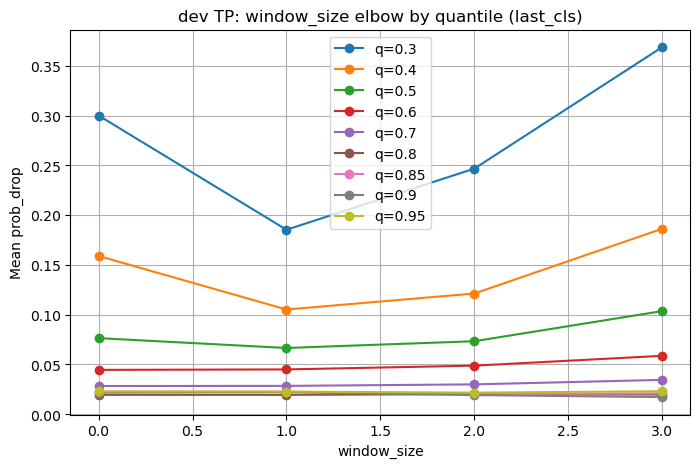

Saved plot: attention_results_aopc/dev_config_selection/attention_dev_window_elbow_by_quantile_last_cls.png


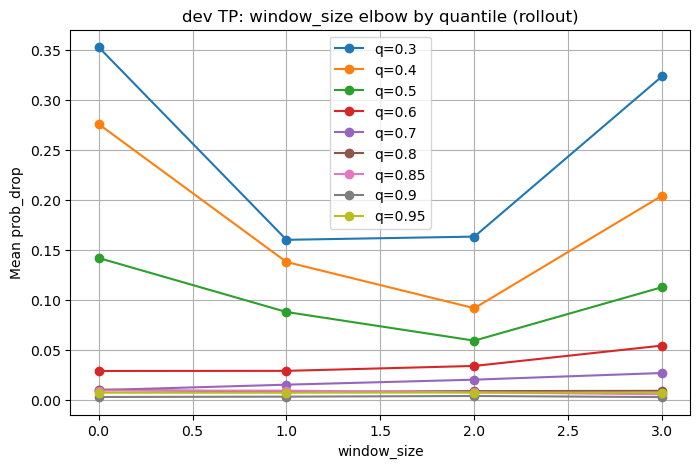

Saved plot: attention_results_aopc/dev_config_selection/attention_dev_window_elbow_by_quantile_rollout.png


In [26]:
for method in sorted(dev_config_summary["attention_method"].unique()):
    method_df = dev_config_summary[
        dev_config_summary["attention_method"] == method
    ].copy()
    
    plt.figure(figsize=(8, 5))
    
    for quantile in sorted(method_df["quantile"].unique()):
        subset = method_df[
            method_df["quantile"] == quantile
        ].sort_values("window_size")
        
        plt.plot(
            subset["window_size"],
            subset["mean_prob_drop"],
            marker="o",
            label=f"q={quantile}"
        )
    
    plt.xlabel("window_size")
    plt.ylabel("Mean prob_drop")
    plt.title(f"dev TP: window_size elbow by quantile ({method})")
    plt.grid(True)
    plt.legend()
    
    plot_path = dev_output_dir / f"attention_dev_window_elbow_by_quantile_{method}.png"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Saved plot:", plot_path)

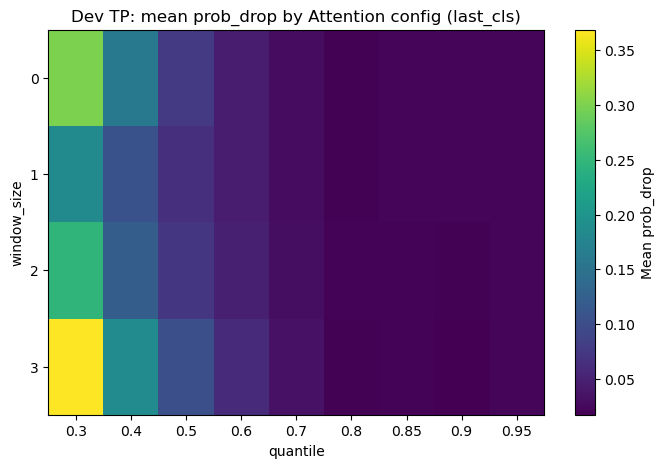

Saved plot: attention_results_aopc/dev_config_selection/attention_dev_find_config_heatmap_last_cls.png


quantile,0.30,0.40,0.50,0.60,0.70,0.80,0.85,0.90,0.95
window_size,,,,,,,,,
0,0.300063,0.158977,0.076464,0.044583,0.028357,0.019480,0.022703,0.021796,0.022878
1,0.185337,0.105221,0.066584,0.045046,0.028513,0.019461,0.022630,0.022111,0.022755
2,0.246754,0.121302,0.073373,0.048838,0.030020,0.020258,0.020069,0.019278,0.021713
3,0.368820,0.186348,0.103646,0.058704,0.034557,0.019837,0.021096,0.017260,0.023132


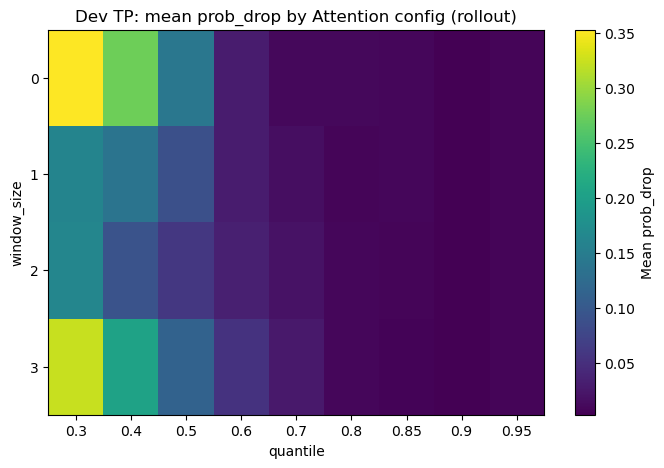

Saved plot: attention_results_aopc/dev_config_selection/attention_dev_find_config_heatmap_rollout.png


quantile,0.30,0.40,0.50,0.60,0.70,0.80,0.85,0.90,0.95
window_size,,,,,,,,,
0,0.353042,0.275997,0.141957,0.028856,0.009696,0.010182,0.009260,0.002819,0.007105
1,0.160124,0.137934,0.087881,0.028964,0.015131,0.007818,0.009159,0.003161,0.007087
2,0.163334,0.091695,0.059205,0.033895,0.020149,0.008696,0.007426,0.003813,0.007276
3,0.323902,0.204429,0.112780,0.054281,0.026831,0.008989,0.005543,0.002722,0.007225


In [27]:
for method in sorted(dev_config_summary["attention_method"].unique()):
    method_df = dev_config_summary[
        dev_config_summary["attention_method"] == method
    ].copy()
    
    heatmap_data = method_df.pivot(
        index="window_size",
        columns="quantile",
        values="mean_prob_drop"
    )
    
    plt.figure(figsize=(8, 5))
    plt.imshow(heatmap_data, aspect="auto")
    plt.colorbar(label="Mean prob_drop")
    
    plt.xticks(
        ticks=np.arange(len(heatmap_data.columns)),
        labels=heatmap_data.columns
    )
    plt.yticks(
        ticks=np.arange(len(heatmap_data.index)),
        labels=heatmap_data.index
    )
    
    plt.xlabel("quantile")
    plt.ylabel("window_size")
    plt.title(f"Dev TP: mean prob_drop by Attention config ({method})")
    
    plot_path = dev_output_dir / f"attention_dev_find_config_heatmap_{method}.png"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Saved plot:", plot_path)
    display(heatmap_data)

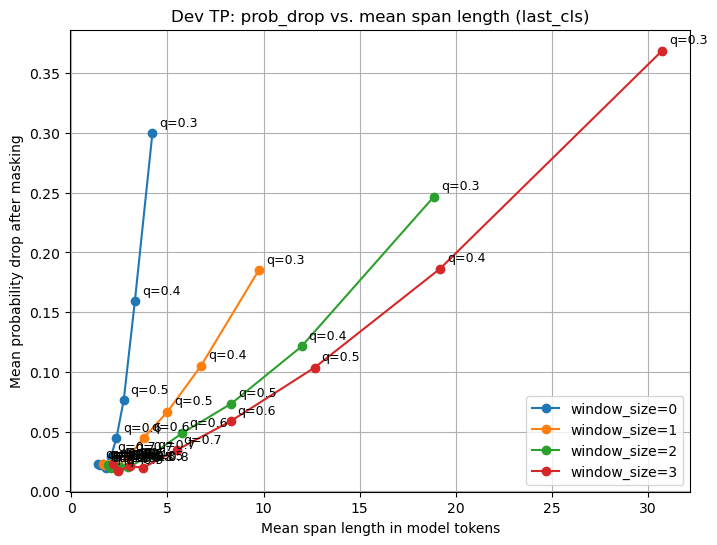

Saved plot: attention_results_aopc/dev_config_selection/attention_dev_prob_drop_vs_mean_span_len_last_cls.png


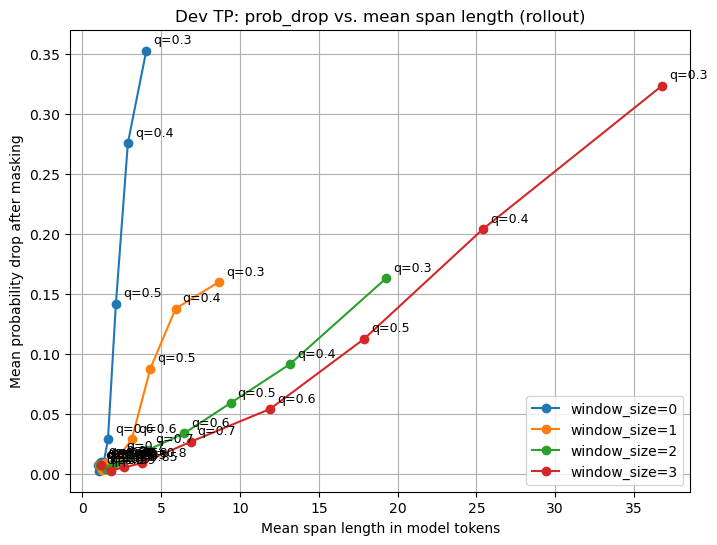

Saved plot: attention_results_aopc/dev_config_selection/attention_dev_prob_drop_vs_mean_span_len_rollout.png


In [28]:
for method in sorted(dev_config_summary["attention_method"].unique()):
    method_df = dev_config_summary[
        dev_config_summary["attention_method"] == method
    ].copy()
    
    plt.figure(figsize=(8, 6))
    
    for window_size in sorted(method_df["window_size"].unique()):
        subset = method_df[
            method_df["window_size"] == window_size
        ].sort_values("quantile")
        
        plt.plot(
            subset["mean_span_len_tokens"],
            subset["mean_prob_drop"],
            marker="o",
            label=f"window_size={window_size}"
        )
        
        for _, row in subset.iterrows():
            plt.annotate(
                f"q={row['quantile']}",
                (row["mean_span_len_tokens"], row["mean_prob_drop"]),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=9
            )
    
    plt.xlabel("Mean span length in model tokens")
    plt.ylabel("Mean probability drop after masking")
    plt.title(f"Dev TP: prob_drop vs. mean span length ({method})")
    plt.grid(True)
    plt.legend()
    
    plot_path = dev_output_dir / f"attention_dev_prob_drop_vs_mean_span_len_{method}.png"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Saved plot:", plot_path)

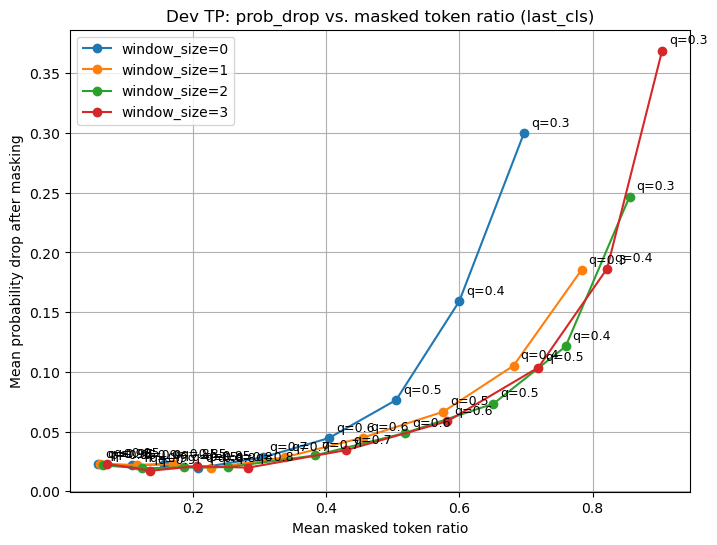

Saved plot: attention_results_aopc/dev_config_selection/attention_dev_prob_drop_vs_masked_token_ratio_last_cls.png


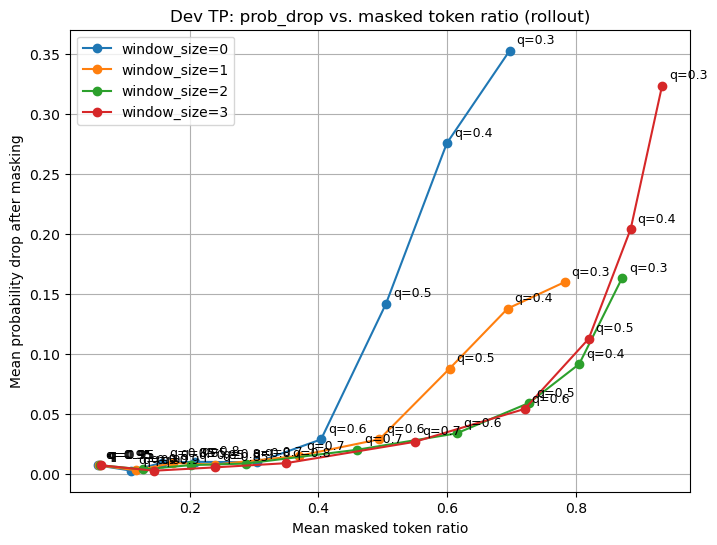

Saved plot: attention_results_aopc/dev_config_selection/attention_dev_prob_drop_vs_masked_token_ratio_rollout.png


In [29]:
for method in sorted(dev_config_summary["attention_method"].unique()):
    method_df = dev_config_summary[
        dev_config_summary["attention_method"] == method
    ].copy()
    
    plt.figure(figsize=(8, 6))
    
    for window_size in sorted(method_df["window_size"].unique()):
        subset = method_df[
            method_df["window_size"] == window_size
        ].sort_values("quantile")
        
        plt.plot(
            subset["mean_masked_token_ratio"],
            subset["mean_prob_drop"],
            marker="o",
            label=f"window_size={window_size}"
        )
        
        for _, row in subset.iterrows():
            plt.annotate(
                f"q={row['quantile']}",
                (row["mean_masked_token_ratio"], row["mean_prob_drop"]),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=9
            )
    
    plt.xlabel("Mean masked token ratio")
    plt.ylabel("Mean probability drop after masking")
    plt.title(f"Dev TP: prob_drop vs. masked token ratio ({method})")
    plt.grid(True)
    plt.legend()
    
    plot_path = dev_output_dir / f"attention_dev_prob_drop_vs_masked_token_ratio_{method}.png"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Saved plot:", plot_path)

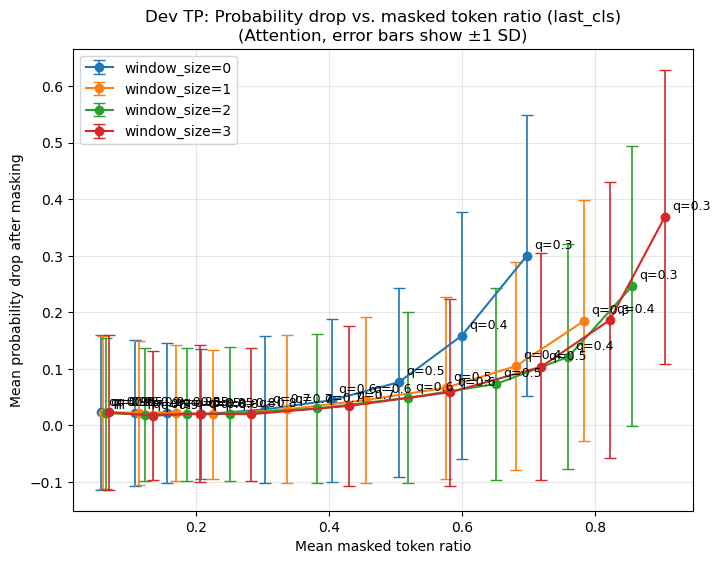

Saved plot: attention_results_aopc/dev_config_selection/attention_dev_prob_drop_vs_masked_token_ratio_with_std_last_cls.png


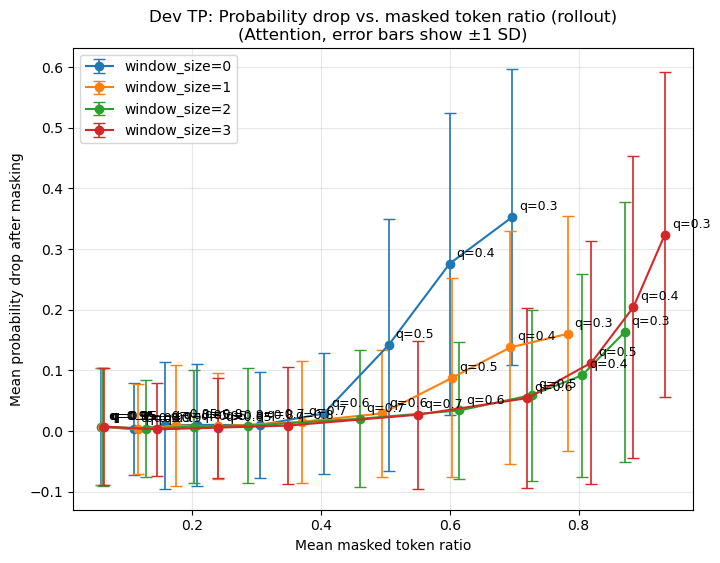

Saved plot: attention_results_aopc/dev_config_selection/attention_dev_prob_drop_vs_masked_token_ratio_with_std_rollout.png


In [30]:
for method in sorted(dev_config_summary["attention_method"].unique()):

    method_df = dev_config_summary[
        dev_config_summary["attention_method"] == method
    ].copy()
    
    plt.figure(figsize=(8, 6))
    
    for window_size in sorted(method_df["window_size"].unique()):
        subset = method_df[
            method_df["window_size"] == window_size
        ].sort_values("quantile")
    
        plt.errorbar(
            subset["mean_masked_token_ratio"],
            subset["mean_prob_drop"],
            yerr=subset["std_prob_drop"],
            marker="o",
            linestyle="-",
            capsize=4,
            elinewidth=1.2,
            label=f"window_size={window_size}"
        )
    
        for _, row in subset.iterrows():
            plt.annotate(
                f"q={row['quantile']}",
                (
                    row["mean_masked_token_ratio"],
                    row["mean_prob_drop"]
                ),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=9
            )
    
    plt.xlabel("Mean masked token ratio")
    plt.ylabel("Mean probability drop after masking")
    plt.title(
        f"Dev TP: Probability drop vs. masked token ratio ({method})\n"
        "(Attention, error bars show ±1 SD)"
    )
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plot_path = (
        dev_output_dir
        / f"attention_dev_prob_drop_vs_masked_token_ratio_with_std_{method}.png"
    )
    
    plt.savefig(
        plot_path,
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    
    print("Saved plot:", plot_path)

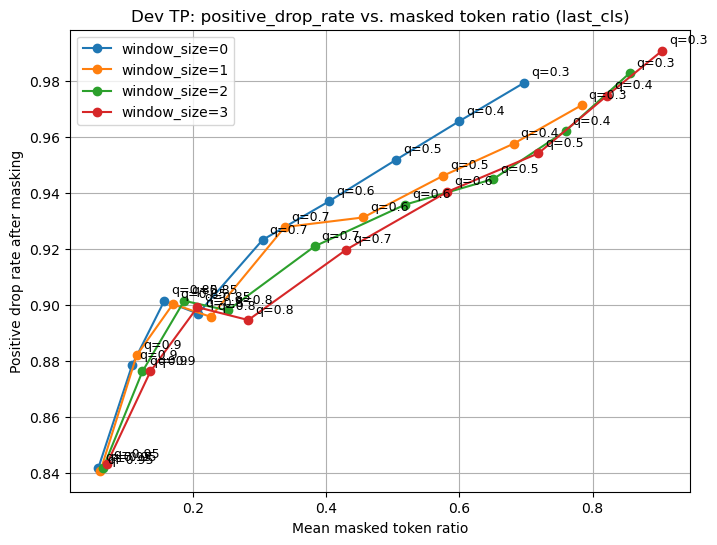

Saved plot: attention_results_aopc/dev_config_selection/attention_dev_positive_drop_rate_vs_masked_token_ratio_last_cls.png


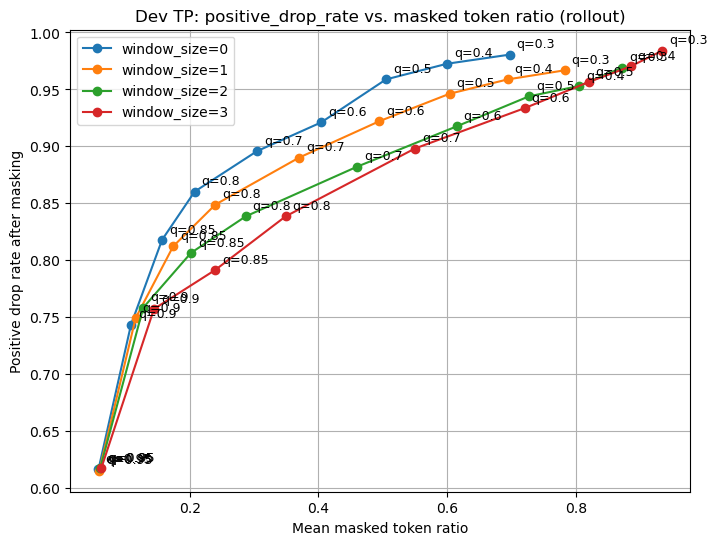

Saved plot: attention_results_aopc/dev_config_selection/attention_dev_positive_drop_rate_vs_masked_token_ratio_rollout.png


In [31]:
for method in sorted(dev_config_summary["attention_method"].unique()):
    method_df = dev_config_summary[
        dev_config_summary["attention_method"] == method
    ].copy()
    
    plt.figure(figsize=(8, 6))
    
    for window_size in sorted(method_df["window_size"].unique()):
        subset = method_df[
            method_df["window_size"] == window_size
        ].sort_values("quantile")
        
        plt.plot(
            subset["mean_masked_token_ratio"],
            subset["positive_drop_rate"],
            marker="o",
            label=f"window_size={window_size}"
        )
        
        for _, row in subset.iterrows():
            plt.annotate(
                f"q={row['quantile']}",
                (row["mean_masked_token_ratio"], row["positive_drop_rate"]),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=9
            )
    
    plt.xlabel("Mean masked token ratio")
    plt.ylabel("Positive drop rate after masking")
    plt.title(f"Dev TP: positive_drop_rate vs. masked token ratio ({method})")
    plt.grid(True)
    plt.legend()
    
    plot_path = dev_output_dir / f"attention_dev_positive_drop_rate_vs_masked_token_ratio_{method}.png"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Saved plot:", plot_path)

In [32]:
# Provisional config from raw attention validation results.
# This is not the final config yet.
# It is only used for qualitative inspection before word-boundary post-processing.

RAW_BEST_ATTENTION_METHOD = "rollout"
RAW_BEST_QUANTILE = 0.4
RAW_BEST_WINDOW_SIZE = 0

selected_config_summary_raw = dev_config_summary[
    (dev_config_summary["attention_method"] == RAW_BEST_ATTENTION_METHOD) &
    (dev_config_summary["quantile"] == RAW_BEST_QUANTILE) &
    (dev_config_summary["window_size"] == RAW_BEST_WINDOW_SIZE)
]

display(selected_config_summary_raw)

,attention_method,window_size,quantile,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,strong_drop_rate_001,strong_drop_rate_005,...,median_masked_token_ratio,n_spans,mean_span_len_tokens,median_span_len_tokens,mean_span_len_chars,median_span_len_chars,mean_span_score_sum_attention,mean_span_score_mean_attention,prob_drop_per_masked_token,prob_drop_per_masked_ratio
37,rollout,0,0.4,873,0.275997,0.220642,0.249166,0.972509,0.867125,0.691867,...,0.6,16826,2.880423,2.0,10.162427,6.0,0.041818,0.014692,0.004971,0.460219


## Raw dev AOPC

In [ ]:
dev_aopc_raw_df = run_attention_aopc_on_indices(
    df=dev_df,
    matrix_positions=dev_tp_positions,
    attention_methods=ATTENTION_METHODS,
    fractions=AOPC_FRACTIONS,
    random_runs=AOPC_RANDOM_RUNS,
    random_seed=AOPC_RANDOM_SEED,
    mask_token=MASK_TOKEN,
    attention_cache=dev_attention_cache,
    use_word_boundary=False
)

dev_aopc_raw_step_df, dev_aopc_raw_curve_summary, dev_aopc_raw_per_argument, dev_aopc_raw_global_summary = summarize_attention_aopc_results(
    dev_aopc_raw_df
)

display(dev_aopc_raw_curve_summary)
display(dev_aopc_raw_global_summary)

save_aopc_outputs(
    aopc_df=dev_aopc_raw_df,
    step_df=dev_aopc_raw_step_df,
    curve_summary=dev_aopc_raw_curve_summary,
    per_argument_aopc=dev_aopc_raw_per_argument,
    global_summary=dev_aopc_raw_global_summary,
    output_dir=AOPC_OUTPUT_DIR,
    prefix="attention_aopc_dev_tp_raw_attention"
)

AOPC Attention (raw_attention):   0%|          | 0/873 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/6002 [00:00<?, ?it/s]

,aopc_variant,attention_method,ranking_method,perturbation_fraction,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,mean_p_original,mean_p_masked,mean_masked_token_ratio,median_masked_token_ratio,mean_selected_token_ratio,mean_top_k_tokens,mean_total_masked_tokens,mean_total_masked_chars,mean_n_merged_spans,fallback_rate
0,raw_attention,last_cls,attention,0.01,873,0.013397,0.000248,0.106717,0.766323,0.98933,0.975933,0.021825,0.015504,0.021862,1.447881,1.446735,4.176403,1.289805,0.0
1,raw_attention,last_cls,attention,0.05,873,0.022878,0.000578,0.136576,0.841924,0.98933,0.966452,0.058150,0.054878,0.058187,5.087056,5.085911,12.784651,3.608247,0.0
2,raw_attention,last_cls,attention,0.10,873,0.021796,0.000957,0.129178,0.878580,0.98933,0.967534,0.108799,0.104895,0.108836,9.709049,9.707904,24.360825,6.468499,0.0
3,raw_attention,last_cls,attention,0.20,873,0.019480,0.001761,0.114929,0.896907,0.98933,0.969850,0.207722,0.204420,0.207797,18.922108,18.918671,53.646048,10.650630,0.0
4,raw_attention,last_cls,attention,0.50,873,0.076464,0.011071,0.167319,0.951890,0.98933,0.912866,0.505040,0.502488,0.505060,46.528064,46.525773,168.122566,17.071019,0.0
5,raw_attention,last_cls,random,0.01,873,0.002772,0.000002,0.022991,0.513173,0.98933,0.986558,0.021851,0.015504,0.021862,1.447881,1.447537,5.301375,1.442153,0.0
6,raw_attention,last_cls,random,0.05,873,0.001813,0.000125,0.033373,0.714777,0.98933,0.987517,0.058170,0.054878,0.058187,5.087056,5.086483,19.007560,4.855899,0.0
7,raw_attention,last_cls,random,0.10,873,0.001741,0.000254,0.041150,0.797251,0.98933,0.987589,0.108818,0.104938,0.108836,9.709049,9.708362,36.756586,8.778923,0.0
8,raw_attention,last_cls,random,0.20,873,0.005425,0.000464,0.054061,0.837342,0.98933,0.983905,0.207772,0.204545,0.207797,18.922108,18.921077,73.119015,15.255441,0.0
9,raw_attention,last_cls,random,0.50,873,0.018416,0.003384,0.069451,0.924399,0.98933,0.970914,0.505043,0.502513,0.505060,46.528064,46.527262,191.240206,23.643757,0.0


,aopc_variant,attention_method,ranking_method,n_arguments,aopc_mean_prob_drop,aopc_median_prob_drop,aopc_std_prob_drop,mean_positive_steps_rate,mean_masked_token_ratio,mean_max_masked_token_ratio,mean_total_masked_tokens,fallback_rate
0,raw_attention,last_cls,attention,873,0.030803,0.003480,0.092046,0.867125,0.180307,0.505040,16.336999,0.0
1,raw_attention,last_cls,random,873,0.006033,0.000989,0.036571,0.757388,0.180331,0.505043,16.338144,0.0
2,raw_attention,rollout,attention,873,0.032438,0.007102,0.072840,0.694616,0.180286,0.505005,16.335624,0.0
3,raw_attention,rollout,random,873,0.006540,0.000924,0.035184,0.743643,0.180327,0.505032,16.337892,0.0


Saved:
attention_results_aopc/aopc_ranking_evaluation/attention_aopc_dev_tp_raw_attention_raw.csv
attention_results_aopc/aopc_ranking_evaluation/attention_aopc_dev_tp_raw_attention_step_summary.csv
attention_results_aopc/aopc_ranking_evaluation/attention_aopc_dev_tp_raw_attention_curve_summary.csv
attention_results_aopc/aopc_ranking_evaluation/attention_aopc_dev_tp_raw_attention_per_argument.csv
attention_results_aopc/aopc_ranking_evaluation/attention_aopc_dev_tp_raw_attention_global_summary.csv


## Provisionally selected attention configuration

The attention-based method was tuned on validation true positives, i.e., arguments that were labeled as inappropriate and also predicted as inappropriate by the document-level classifier. This keeps the configuration selection comparable to the other span localization methods.

The evaluated configurations varied:

- `attention_method ∈ {last_cls, rollout}`
- `quantile ∈ {0.50, 0.60, 0.70, 0.80, 0.85, 0.90, 0.95}`
- `window_size ∈ {0, 1, 2, 3}`

In this notebook, `window_size` is a merge-gap parameter for attention-based spans. It does not add a symmetric token window around selected tokens. Instead, it controls how many unselected tokens may lie between selected tokens for them to be merged into one span.

The final configuration was selected based on the validation trade-off between probability drop and masked token ratio. The selected setting is:

- `attention_method = rollout`
- `quantile = 0.4`
- `window_size = 0`

This setting produces very short spans while still yielding a positive average probability drop after masking. However, because attention weights are not guaranteed to be faithful explanations, the method is interpreted as a candidate-generation approach validated through perturbation.

## Qualitative inspection of the provisional raw-attention configuration

Before applying the selected attention configuration to the full dataset, the extracted validation examples are inspected qualitatively.

This step is important because the quantitative validation results may still favor configurations that produce tokenizer artifacts rather than interpretable evidence spans. In particular, attention-based extraction operates on model tokens and may therefore highlight:

- subword fragments such as `'t` from `don't`
- punctuation-only spans such as `"`, `.`, or `."`

If such artifacts occur frequently, the raw attention extraction is not sufficiently interpretable, even if the masking-based probability drop is high. In that case, a word-boundary post-processing step is introduced and the validation-based hyperparameter search is repeated using the post-processed spans.

In [ ]:
def show_attention_example(result_df, index=0):
    """Display one attention result with highlighted masked spans."""
    row = result_df.iloc[index]
    
    spans = json.loads(row["merged_spans_json"])
    marked = highlight_spans(row["text"], spans)
    
    display(HTML(f"""
    <div style="
        border:1px solid #ccc;
        border-radius:8px;
        padding:14px;
        margin:12px 0;
        font-family:Arial, sans-serif;
        line-height:1.45;
    ">
        <b>global_row_id:</b> {html.escape(str(row["global_row_id"]))}<br>
        <b>post_id:</b> {html.escape(str(row["post_id"]))}<br>
        <b>split:</b> {html.escape(str(row["split"]))}<br>
        <b>confusion_type:</b> {html.escape(str(row["confusion_type"]))}<br>
        <b>issue:</b> {html.escape(str(row["issue"]))}<br>
        <b>method:</b> {html.escape(str(row["attention_method"]))} |
        <b>quantile:</b> {row["quantile"]} |
        <b>window_size:</b> {row["window_size"]}<br>
        <b>merged_spans:</b> {html.escape(str(row["merged_span_texts"]))}<br>
        <b>p_original:</b> {float(row["p_inappropriate_original"]):.4f}<br>
        <b>p_masked:</b> {float(row["p_inappropriate_masked"]):.4f}<br>
        <b>prob_drop:</b> {float(row["prob_drop"]):.4f}<br>
        <b>masked_token_ratio:</b> {float(row["masked_token_ratio"]):.4f}<br>
        <hr>
        <p>{marked}</p>
    </div>
    """))

In [35]:
dev_raw_best_examples = dev_tp_argument_df[
    (dev_tp_argument_df["attention_method"] == RAW_BEST_ATTENTION_METHOD) &
    (dev_tp_argument_df["quantile"] == RAW_BEST_QUANTILE) &
    (dev_tp_argument_df["window_size"] == RAW_BEST_WINDOW_SIZE) &
    (dev_tp_argument_df["error"].isna())
].copy()

print("Dev examples for provisional raw config:", len(dev_raw_best_examples))
display(
    dev_raw_best_examples[
        [
            "global_row_id",
            "post_id",
            "prob_drop",
            "masked_token_ratio",
            "merged_span_texts"
        ]
    ].head()
)

Dev examples for provisional raw config: 873


,global_row_id,post_id,prob_drop,masked_token_ratio,merged_span_texts
40,0,1,0.029803,0.595238,"[people cant be forced to wear, uniforms, i, h..."
112,1,2,0.612050,0.600000,"[That form of, degrades this forum, and will, ..."
184,3,4,0.012809,0.593750,"[No I wouldn', in my spouse., the girl that i,..."
256,4,5,0.014057,0.594595,"[TV is, . Except for, . That's an alright, ., ..."
328,5,6,0.013503,0.600000,"[I love, , I, in them. They also, your literat..."


In [36]:
tmp_raw_top = (
    dev_raw_best_examples
    .sort_values("prob_drop", ascending=False)
    .reset_index(drop=True)
)

for i in range(min(5, len(tmp_raw_top))):
    show_attention_example(tmp_raw_top, index=i)

# Summary and saving results without word boundary

In [ ]:
def run_final_attention_on_split(df, split_name):
    """
    Run the selected Attention configuration on one split.
    
    The final configuration is fixed and not re-tuned per split.
    """
    positions = list(range(len(df)))
    
    raw_results = run_attention_config_on_indices(
        df=df,
        matrix_positions=positions,
        attention_methods=[RAW_BEST_ATTENTION_METHOD],
        quantile_values=[RAW_BEST_QUANTILE],
        window_size_values=[RAW_BEST_WINDOW_SIZE],
        mask_token=MASK_TOKEN
    )
    
    argument_df = build_argument_level_df(raw_results)
    span_df = build_span_level_df(raw_results)
    
    print(f"{split_name} argument level:", argument_df.shape)
    print(f"{split_name} span level:", span_df.shape)
    
    return raw_results, argument_df, span_df


train_results, train_argument_df, train_span_df = run_final_attention_on_split(
    train_df,
    "train"
)

val_results, val_argument_df, val_span_df = run_final_attention_on_split(
    val_df,
    "validation"
)

test_results, test_argument_df, test_span_df = run_final_attention_on_split(
    test_df,
    "test"
)

Building attention spans:   0%|          | 0/438 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/28 [00:00<?, ?it/s]

test raw argument level: (438, 43)
test raw span level: (8859, 36)


In [ ]:
final_argument_df = pd.concat(
    [train_argument_df, val_argument_df, test_argument_df],
    ignore_index=True
)

final_span_df = pd.concat(
    [train_span_df, val_span_df, test_span_df],
    ignore_index=True
)

display(final_argument_df.head())
display(final_span_df.head())

print("Final argument-level rows:", len(final_argument_df))
print("Final span-level rows:", len(final_span_df))

,global_row_id,split,post_id,issue,label,predicted_label,predicted_score,confusion_type,is_true_positive,is_false_negative,...,merged_span_texts,merged_span_token_start_indices,merged_span_token_end_indices,merged_span_char_start_indices,merged_span_char_end_indices,selected_tokens_json,merged_spans_json,text,masked_text,error
0,1753,test,0,Is the school uniform a good or bad idea:,1,LABEL_0,0.892726,FN,False,True,...,"[students should, they, and feel, their clothes]","[1, 5, 7, 11]","[2, 5, 8, 12]","[0, 26, 36, 56]","[15, 30, 44, 69]","[""▁students"", ""▁should"", ""▁they"", ""▁and"", ""▁fe...","[{""char_start"": 0, ""char_end"": 15, ""token_star...",students should wear what they like and feel f...,[MASK] [MASK] wear what [MASK] like [MASK] [MA...,None
1,1754,test,8,Tv is better than books:,1,LABEL_1,0.997475,TP,True,False,...,"[I thick that book are, is it is, i, you in a,...","[1, 9, 13, 16, 24]","[5, 11, 13, 18, 27]","[0, 37, 53, 63, 91]","[21, 45, 54, 71, 112]","[""▁I"", ""▁thick"", ""▁that"", ""▁book"", ""▁are"", ""▁i...","[{""char_start"": 0, ""char_end"": 21, ""token_star...",I thick that book are better than TV is it is ...,[MASK] [MASK] [MASK] [MASK] [MASK] better than...,None
2,1755,test,9,Tv is better than books:,1,LABEL_1,0.998255,TP,True,False,...,"[Books enlighten the soul. Books, ', the moral...","[1, 8, 11, 15, 18, 21, 25, 28, 33, 35, 38, 41,...","[6, 8, 13, 15, 18, 23, 26, 30, 33, 36, 38, 42,...","[0, 35, 46, 68, 82, 96, 117, 129, 159, 169, 18...","[31, 36, 59, 69, 85, 107, 123, 143, 160, 174, ...","[""▁Books"", ""▁enlighten"", ""▁the"", ""▁soul"", ""."",...","[{""char_start"": 0, ""char_end"": 31, ""token_star...",Books enlighten the soul. Books don't destroy ...,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] don[...,None
3,1756,test,12,India has the potential to lead the world:,1,LABEL_1,0.995627,TP,True,False,...,"[india is is, but a, and, should be a, developer]","[1, 6, 10, 12, 16]","[3, 7, 10, 14, 16]","[0, 25, 45, 56, 74]","[11, 30, 48, 67, 83]","[""▁india"", ""▁is"", ""▁is"", ""▁but"", ""▁a"", ""▁and"",...","[{""char_start"": 0, ""char_end"": 11, ""token_star...",india is is good adopter but a bad developer a...,[MASK] [MASK] [MASK] good adopter [MASK] [MASK...,None
4,1757,test,15,Is it better to have a lousy father or to be f...,0,LABEL_0,0.993661,TN,False,False,...,"[Honestly, I'd, be, ,, that, is, , albeit a lo...","[1, 7, 11, 14, 17, 22, 27, 33, 41, 48, 50, 55,...","[5, 7, 11, 14, 17, 25, 30, 35, 41, 48, 53, 58,...","[0, 21, 45, 58, 74, 99, 119, 143, 186, 224, 23...","[13, 23, 46, 62, 76, 115, 131, 155, 189, 227, ...","[""▁Honestly"", "","", ""▁I"", ""'"", ""d"", ""▁be"", "","",...","[{""char_start"": 0, ""char_end"": 13, ""token_star...","Honestly, I'd rather be completely fatherless,...",[MASK] [MASK] [MASK] [MASK] [MASK] rather [MAS...,None


,global_row_id,split,post_id,issue,label,predicted_label,confusion_type,is_true_positive,is_false_negative,is_false_positive,...,span_score_max_attention,p_inappropriate_original,p_inappropriate_masked,prob_drop,n_model_tokens,n_selected_tokens,selected_token_ratio,masked_token_ratio,text,masked_text
0,1753,test,0,Is the school uniform a good or bad idea:,1,LABEL_0,FN,False,True,False,...,0.105267,0.107274,0.910977,-0.803703,12,7,0.583333,0.583333,students should wear what they like and feel f...,[MASK] [MASK] wear what [MASK] like [MASK] [MA...
1,1753,test,0,Is the school uniform a good or bad idea:,1,LABEL_0,FN,False,True,False,...,0.084161,0.107274,0.910977,-0.803703,12,7,0.583333,0.583333,students should wear what they like and feel f...,[MASK] [MASK] wear what [MASK] like [MASK] [MA...
2,1753,test,0,Is the school uniform a good or bad idea:,1,LABEL_0,FN,False,True,False,...,0.134787,0.107274,0.910977,-0.803703,12,7,0.583333,0.583333,students should wear what they like and feel f...,[MASK] [MASK] wear what [MASK] like [MASK] [MA...
3,1753,test,0,Is the school uniform a good or bad idea:,1,LABEL_0,FN,False,True,False,...,0.125380,0.107274,0.910977,-0.803703,12,7,0.583333,0.583333,students should wear what they like and feel f...,[MASK] [MASK] wear what [MASK] like [MASK] [MA...
4,1754,test,8,Tv is better than books:,1,LABEL_1,TP,True,False,False,...,0.044088,0.997475,0.972826,0.024650,27,16,0.592593,0.592593,I thick that book are better than TV is it is ...,[MASK] [MASK] [MASK] [MASK] [MASK] better than...


Final argument-level rows: 438
Final span-level rows: 8859


In [39]:
final_argument_df_valid = final_argument_df[
    final_argument_df["error"].isna()
].copy()

overall_summary = (
    final_argument_df_valid
    .groupby(["split", "attention_method", "window_size", "quantile"])
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        strong_drop_rate_001=("prob_drop", lambda x: (x > 0.01).mean()),
        strong_drop_rate_005=("prob_drop", lambda x: (x > 0.05).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
    )
    .reset_index()
)

confusion_summary = (
    final_argument_df_valid
    .groupby(["split", "confusion_type"])
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
    )
    .reset_index()
    .sort_values(["split", "confusion_type"])
)

display(overall_summary)
display(confusion_summary)

,split,attention_method,window_size,quantile,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,strong_drop_rate_001,strong_drop_rate_005,mean_p_original,mean_p_masked,mean_n_merged_spans,mean_total_masked_tokens,mean_masked_token_ratio
0,test,rollout,0,0.4,438,-0.069014,0.009295,0.447021,0.563927,0.495434,0.378995,0.590804,0.659818,20.226027,57.97032,0.599908


,split,confusion_type,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,mean_p_original,mean_p_masked,mean_n_merged_spans,mean_total_masked_tokens,mean_masked_token_ratio
0,test,FN,39,-0.502262,-0.425041,0.216775,0.000000,0.049638,0.551901,22.743590,65.358974,0.599475
1,test,FP,71,0.270124,0.158195,0.263937,0.929577,0.971585,0.701461,18.154930,51.408451,0.600268
2,test,TN,142,-0.520877,-0.432638,0.225277,0.014085,0.037216,0.558093,22.894366,65.957746,0.599689
3,test,TP,186,0.237344,0.134223,0.250078,0.962366,0.981555,0.744211,18.451613,52.827957,0.600029


In [40]:
test_argument_df_valid = test_argument_df[
    test_argument_df["error"].isna()
].copy()

test_overall_summary = (
    test_argument_df_valid
    .groupby(["attention_method", "window_size", "quantile"])
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        strong_drop_rate_001=("prob_drop", lambda x: (x > 0.01).mean()),
        strong_drop_rate_005=("prob_drop", lambda x: (x > 0.05).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
    )
    .reset_index()
)

test_confusion_summary = (
    test_argument_df_valid
    .groupby("confusion_type")
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
    )
    .reset_index()
    .sort_values("confusion_type")
)

display(test_overall_summary)
display(test_confusion_summary)

,attention_method,window_size,quantile,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,strong_drop_rate_001,strong_drop_rate_005,mean_p_original,mean_p_masked,mean_n_merged_spans,mean_total_masked_tokens,mean_masked_token_ratio
0,rollout,0,0.4,438,-0.069014,0.009295,0.447021,0.563927,0.495434,0.378995,0.590804,0.659818,20.226027,57.97032,0.599908


,confusion_type,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,mean_p_original,mean_p_masked,mean_n_merged_spans,mean_total_masked_tokens,mean_masked_token_ratio
0,FN,39,-0.502262,-0.425041,0.216775,0.000000,0.049638,0.551901,22.743590,65.358974,0.599475
1,FP,71,0.270124,0.158195,0.263937,0.929577,0.971585,0.701461,18.154930,51.408451,0.600268
2,TN,142,-0.520877,-0.432638,0.225277,0.014085,0.037216,0.558093,22.894366,65.957746,0.599689
3,TP,186,0.237344,0.134223,0.250078,0.962366,0.981555,0.744211,18.451613,52.827957,0.600029


In [42]:
final_output_dir = OUTPUT_DIR / "attention_results_final" 
final_output_dir.mkdir(parents=True, exist_ok=True)

argument_csv_path = final_output_dir / (
    f"attention_final_all_splits_{RAW_BEST_ATTENTION_METHOD}"
    f"_q{RAW_BEST_QUANTILE}_window{RAW_BEST_WINDOW_SIZE}_argument_level.csv"
)

span_csv_path = final_output_dir / (
    f"attention_final_all_splits_{RAW_BEST_ATTENTION_METHOD}"
    f"_q{RAW_BEST_QUANTILE}_window{RAW_BEST_WINDOW_SIZE}_span_level.csv"
)

overall_summary_csv_path = final_output_dir / (
    f"attention_final_all_splits_{RAW_BEST_ATTENTION_METHOD}"
    f"_q{RAW_BEST_QUANTILE}_window{RAW_BEST_WINDOW_SIZE}_overall_summary.csv"
)

confusion_summary_csv_path = final_output_dir / (
    f"attention_final_all_splits_{RAW_BEST_ATTENTION_METHOD}"
    f"_q{RAW_BEST_QUANTILE}_window{RAW_BEST_WINDOW_SIZE}_confusion_summary.csv"
)

test_summary_csv_path = final_output_dir / (
    f"attention_final_test_{RAW_BEST_ATTENTION_METHOD}"
    f"_q{RAW_BEST_QUANTILE}_window{RAW_BEST_WINDOW_SIZE}_summary.csv"
)

jsonl_path = final_output_dir / (
    f"attention_final_all_splits_{RAW_BEST_ATTENTION_METHOD}"
    f"_q{RAW_BEST_QUANTILE}_window{RAW_BEST_WINDOW_SIZE}_argument_level.jsonl"
)

final_argument_df.to_csv(argument_csv_path, index=False, encoding="utf-8")
final_span_df.to_csv(span_csv_path, index=False, encoding="utf-8")
overall_summary.to_csv(overall_summary_csv_path, index=False, encoding="utf-8")
confusion_summary.to_csv(confusion_summary_csv_path, index=False, encoding="utf-8")
test_overall_summary.to_csv(test_summary_csv_path, index=False, encoding="utf-8")

all_results = test_results

with open(jsonl_path, "w", encoding="utf-8") as f:
    for result in all_results:
        safe_result = make_json_serializable(result)
        f.write(json.dumps(safe_result, ensure_ascii=False) + "\n")

print("Saved:")
print(argument_csv_path)
print(span_csv_path)
print(overall_summary_csv_path)
print(confusion_summary_csv_path)
print(test_summary_csv_path)
print(jsonl_path)

Saved:
attention_results_aopc/attention_results_final/attention_final_all_splits_rollout_q0.4_window0_argument_level.csv
attention_results_aopc/attention_results_final/attention_final_all_splits_rollout_q0.4_window0_span_level.csv
attention_results_aopc/attention_results_final/attention_final_all_splits_rollout_q0.4_window0_overall_summary.csv
attention_results_aopc/attention_results_final/attention_final_all_splits_rollout_q0.4_window0_confusion_summary.csv
attention_results_aopc/attention_results_final/attention_final_test_rollout_q0.4_window0_summary.csv
attention_results_aopc/attention_results_final/attention_final_all_splits_rollout_q0.4_window0_argument_level.jsonl


In [43]:
# Best test examples by probability drop
tmp = (
    test_argument_df_valid
    .sort_values("prob_drop", ascending=False)
    .reset_index(drop=True)
)

for i in range(min(5, len(tmp))):
    show_attention_example(tmp, index=i)

In [44]:
# Test examples with the smallest or negative probability drops
tmp_low = (
    test_argument_df_valid
    .sort_values("prob_drop", ascending=True)
    .reset_index(drop=True)
)

for i in range(min(5, len(tmp_low))):
    show_attention_example(tmp_low, index=i)

## Re-tuning after Word-boundary post-processing

The attention-based extraction operates on model tokens, not on linguistic words. Since transformer tokenizers often split words into subword units and punctuation tokens, extracted spans may contain only fragments such as `'t` from `can't` or punctuation-only spans such as `"`, `.`, or `."`.

This is problematic for span localization because the goal of this thesis is not to identify tokenizer artifacts, but interpretable text spans that can be read as meaningful evidence for the model prediction.

To reduce such artifacts, this section adds a word-boundary post-processing step after attention-based span extraction:

1. If an extracted span overlaps with a word, the span is expanded to cover the full word.
2. For example, a selected fragment such as `'t` in `don't` is expanded to the full word `can't`.
3. Spans that consist only of punctuation and do not overlap with any word are removed.
4. After expansion, overlapping spans are merged.
5. The resulting word-boundary spans are masked again and the probability drop is recomputed.

This does not change how attention scores are computed. It only changes how token-level attention candidates are converted into readable character spans. Therefore, this step should be interpreted as a post-processing improvement for human interpretability, not as a new attribution method.

In [45]:
# Output folder for word-boundary post-processing results
WORD_BOUNDARY_OUTPUT_DIR = OUTPUT_DIR / "attention_results_word_boundary"
WORD_BOUNDARY_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Whether punctuation-only spans should be removed.
# This is important because punctuation often receives high attention but is rarely interpretable as evidence by itself.
DROP_PUNCTUATION_ONLY_SPANS = True

print("Word-boundary output directory:", WORD_BOUNDARY_OUTPUT_DIR)

Word-boundary output directory: attention_results_aopc/attention_results_word_boundary


### Fallback for punctuation-only spans

The word-boundary post-processing removes punctuation-only spans because they are often tokenizer artifacts and are usually difficult to interpret as meaningful evidence.

However, removing all punctuation-only spans can also be too strict. In some arguments, the raw attention extraction may select only punctuation tokens. If all of these are removed, the resulting span list becomes empty, no text is masked, and the probability drop is necessarily zero. This would make the result less informative, because the original attention method did identify model-relevant tokens.

Therefore, this notebook uses a conservative fallback rule:

- If word-boundary post-processing produces at least one span, the post-processed spans are used.
- If word-boundary post-processing removes all spans, the original raw attention spans are kept.
- A boolean flag `word_boundary_fallback_used` records whether this fallback was applied.

This keeps the method interpretable where possible, while avoiding empty span outputs when the raw attention method selected only punctuation.

In [46]:
def get_word_spans(text):
    """
    Return word-like character spans in text.
    
    This pattern keeps common contractions and hyphenated words together:
    - can't
    - don't
    - day-to-day
    """
    text = str(text)
    pattern = re.compile(r"\b\w+(?:['’\-]\w+)*\b", flags=re.UNICODE)
    
    return [
        {
            "char_start": int(match.start()),
            "char_end": int(match.end()),
            "word": match.group(0)
        }
        for match in pattern.finditer(text)
    ]


def get_token_offsets_for_text(text):
    """
    Tokenize text and return valid model-token offsets.
    
    This is used only for updating token-level metadata after word-boundary expansion.
    """
    enc = tokenizer(
        text,
        truncation=True,
        max_length=MAX_LENGTH,
        return_offsets_mapping=True,
        return_special_tokens_mask=True,
        return_tensors="pt"
    )
    
    offsets = enc["offset_mapping"][0].tolist()
    special_mask = enc["special_tokens_mask"][0].tolist()
    tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"][0].tolist())
    
    valid_token_rows = []
    
    for idx, ((start, end), is_special) in enumerate(zip(offsets, special_mask)):
        if is_special == 0 and end > start:
            valid_token_rows.append({
                "token_idx": int(idx),
                "token": tokens[idx],
                "char_start": int(start),
                "char_end": int(end)
            })
    
    return valid_token_rows

def expand_span_to_word_boundary(span, word_spans):
    """
    Expand one extracted span to full word boundaries.
    
    If the span overlaps one or more words, the returned character span covers
    the full overlapping word(s). If the span overlaps no word, None is returned.
    """
    span_start = int(span["char_start"])
    span_end = int(span["char_end"])
    
    overlapping_words = [
        word
        for word in word_spans
        if word["char_start"] < span_end and word["char_end"] > span_start
    ]
    
    if not overlapping_words:
        return None
    
    new_start = min(word["char_start"] for word in overlapping_words)
    new_end = max(word["char_end"] for word in overlapping_words)
    
    expanded_span = dict(span)
    expanded_span["char_start"] = int(new_start)
    expanded_span["char_end"] = int(new_end)
    expanded_span["span_text"] = None
    expanded_span["span_len_chars"] = int(new_end - new_start)
    expanded_span["word_boundary_expanded"] = True
    
    return expanded_span


def merge_overlapping_boundary_spans(spans, text):
    """
    Merge spans that overlap after word-boundary expansion.
    """
    if not spans:
        return []
    
    spans = sorted(spans, key=lambda x: (x["char_start"], x["char_end"]))
    merged = []
    
    current = dict(spans[0])
    
    for span in spans[1:]:
        if span["char_start"] <= current["char_end"]:
            current["char_end"] = max(current["char_end"], span["char_end"])
            current["span_len_chars"] = current["char_end"] - current["char_start"]
            
            current["selected_token_indices"] = sorted(
                set(current.get("selected_token_indices", []))
                | set(span.get("selected_token_indices", []))
            )
            
            current["selected_token_texts"] = (
                current.get("selected_token_texts", [])
                + span.get("selected_token_texts", [])
            )
            
            current["span_score_sum_attention"] = float(
                current.get("span_score_sum_attention", 0.0)
                + span.get("span_score_sum_attention", 0.0)
            )
            
            current["span_score_max_attention"] = max(
                float(current.get("span_score_max_attention", 0.0)),
                float(span.get("span_score_max_attention", 0.0))
            )
        else:
            merged.append(current)
            current = dict(span)
    
    merged.append(current)
    
    for idx, span in enumerate(merged):
        span["span_idx"] = int(idx)
        span["span_text"] = text[span["char_start"]:span["char_end"]]
        span["span_len_chars"] = int(span["char_end"] - span["char_start"])
        
        if len(span.get("selected_token_indices", [])) > 0:
            span["span_score_mean_attention"] = float(
                span["span_score_sum_attention"] / len(span["selected_token_indices"])
            )
        else:
            span["span_score_mean_attention"] = 0.0
    
    return merged

def update_span_token_metadata(spans, text):
    """
    Update token start/end indices and token lengths after character spans were expanded.
    """
    if not spans:
        return []
    
    token_rows = get_token_offsets_for_text(text)
    updated_spans = []
    
    for span in spans:
        span = dict(span)
        start = int(span["char_start"])
        end = int(span["char_end"])
        
        overlapping_tokens = [
            token
            for token in token_rows
            if token["char_start"] < end and token["char_end"] > start
        ]
        
        if overlapping_tokens:
            token_start_idx = min(token["token_idx"] for token in overlapping_tokens)
            token_end_idx = max(token["token_idx"] for token in overlapping_tokens)
            span_len_tokens = token_end_idx - token_start_idx + 1
        else:
            token_start_idx = span.get("token_start_idx", None)
            token_end_idx = span.get("token_end_idx", None)
            span_len_tokens = span.get("span_len_tokens", 0)
        
        span["token_start_idx"] = int(token_start_idx) if token_start_idx is not None else None
        span["token_end_idx"] = int(token_end_idx) if token_end_idx is not None else None
        span["span_len_tokens"] = int(span_len_tokens)
        
        updated_spans.append(span)
    
    return updated_spans


def apply_word_boundary_to_spans(text, merged_spans, drop_punctuation_only=True):
    """
    Apply word-boundary post-processing to extracted attention spans.
    
    Punctuation-only spans are removed if they do not overlap with a word.
    Subword fragments are expanded to the full word they belong to.
    """
    text = str(text)
    word_spans = get_word_spans(text)
    
    boundary_spans = []
    
    for span in merged_spans:
        expanded = expand_span_to_word_boundary(span, word_spans)
        
        if expanded is None:
            if drop_punctuation_only:
                continue
            
            copied = dict(span)
            copied["word_boundary_expanded"] = False
            boundary_spans.append(copied)
        else:
            expanded["span_text"] = text[expanded["char_start"]:expanded["char_end"]]
            boundary_spans.append(expanded)
    
    boundary_spans = merge_overlapping_boundary_spans(boundary_spans, text)
    boundary_spans = update_span_token_metadata(boundary_spans, text)
    
    return boundary_spans

In [47]:
def apply_word_boundary_to_argument_results(argument_results):
    """
    Apply word-boundary post-processing to already extracted attention results,
    then recompute masked text and probability drop.
    
    Fallback rule:
    If word-boundary post-processing removes all spans, keep the original raw
    attention spans instead of returning an empty span list.
    """
    updated_results = []
    masked_texts_to_score = []
    masked_lookup = []
    
    for result in tqdm(argument_results, desc="Applying word-boundary post-processing"):
        updated = dict(result)
        text = str(updated["text"])
        
        original_spans = updated.get("merged_spans", [])
        
        boundary_spans_before_fallback = apply_word_boundary_to_spans(
            text=text,
            merged_spans=original_spans,
            drop_punctuation_only=DROP_PUNCTUATION_ONLY_SPANS
        )
        
        word_boundary_fallback_used = False
        boundary_spans = boundary_spans_before_fallback
        
        # Fallback: do not allow word-boundary post-processing to remove all spans.
        # If all spans would be removed, keep the original raw attention spans.
        if len(boundary_spans_before_fallback) == 0 and len(original_spans) > 0:
            boundary_spans = original_spans
            word_boundary_fallback_used = True
        
        masked_text = mask_spans_in_text(
            text=text,
            spans=boundary_spans,
            mask_token=MASK_TOKEN
        )
        
        total_masked_tokens = sum(
            span.get("span_len_tokens", 0)
            for span in boundary_spans
        )
        
        total_masked_chars = sum(
            span.get("span_len_chars", 0)
            for span in boundary_spans
        )
        
        n_model_tokens = int(updated.get("n_model_tokens", 0))
        masked_token_ratio = (
            total_masked_tokens / n_model_tokens
            if n_model_tokens > 0
            else 0.0
        )
        
        updated["merged_spans_original_attention"] = original_spans
        updated["merged_spans"] = boundary_spans
        updated["masked_text"] = masked_text
        
        updated["n_merged_spans_original_attention"] = int(len(original_spans))
        updated["n_merged_spans_word_boundary_before_fallback"] = int(
            len(boundary_spans_before_fallback)
        )
        updated["word_boundary_fallback_used"] = bool(word_boundary_fallback_used)
        
        updated["n_merged_spans"] = int(len(boundary_spans))
        updated["total_masked_tokens"] = int(total_masked_tokens)
        updated["total_masked_chars"] = int(total_masked_chars)
        updated["masked_token_ratio"] = float(masked_token_ratio)
        
        updated["word_boundary_postprocessed"] = True
        updated["drop_punctuation_only_spans"] = bool(DROP_PUNCTUATION_ONLY_SPANS)
        
        updated_results.append(updated)
        masked_lookup.append(len(updated_results) - 1)
        masked_texts_to_score.append(masked_text)
    
    if len(masked_texts_to_score) > 0:
        masked_predictions = predict_with_pipeline(
            masked_texts_to_score,
            batch_size=BATCH_SIZE
        )
        
        for result_idx, (_, pred_row) in zip(masked_lookup, masked_predictions.iterrows()):
            result = updated_results[result_idx]
            p_masked = float(pred_row["p_inappropriate_original"])
            
            result["p_inappropriate_masked"] = p_masked
            result["predicted_label_masked"] = pred_row["predicted_label"]
            result["prob_drop"] = float(result["p_inappropriate_original"] - p_masked)
    
    return updated_results

## Apply word boundary processing to dev set
## New Config Search using word boundary

In [48]:
dev_tp_results_word_boundary = apply_word_boundary_to_argument_results(dev_tp_results)

dev_tp_argument_df_word_boundary = build_argument_level_df(dev_tp_results_word_boundary)
dev_tp_span_df_word_boundary = build_span_level_df(dev_tp_results_word_boundary)

display(dev_tp_argument_df_word_boundary.head())
display(dev_tp_span_df_word_boundary.head())

Applying word-boundary post-processing:   0%|          | 0/62856 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/3929 [00:00<?, ?it/s]

,global_row_id,split,post_id,issue,label,predicted_label,predicted_score,confusion_type,is_true_positive,is_false_negative,...,merged_span_texts,merged_span_token_start_indices,merged_span_token_end_indices,merged_span_char_start_indices,merged_span_char_end_indices,selected_tokens_json,merged_spans_json,text,masked_text,error
0,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,[people cant be forced to wear school uniforms...,"[1, 21, 27, 40]","[15, 21, 37, 41]","[0, 93, 119, 191]","[69, 97, 179, 204]","[""▁people"", ""▁can"", ""t"", ""▁be"", ""▁forced"", ""▁t...","[{""char_start"": 0, ""char_end"": 69, ""token_star...","people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None
1,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,[people cant be forced to wear school uniforms...,"[1, 21, 27, 40]","[15, 21, 37, 41]","[0, 93, 119, 191]","[69, 97, 179, 204]","[""▁people"", ""▁can"", ""t"", ""▁be"", ""▁forced"", ""▁t...","[{""char_start"": 0, ""char_end"": 69, ""token_star...","people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None
2,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,[people cant be forced to wear school uniforms...,"[1, 21, 27]","[15, 21, 41]","[0, 93, 119]","[69, 97, 204]","[""▁people"", ""▁can"", ""t"", ""▁be"", ""▁forced"", ""▁t...","[{""char_start"": 0, ""char_end"": 69, ""token_star...","people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None
3,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,[people cant be forced to wear school uniforms...,"[1, 21, 27]","[15, 21, 41]","[0, 93, 119]","[69, 97, 204]","[""▁people"", ""▁can"", ""t"", ""▁be"", ""▁forced"", ""▁t...","[{""char_start"": 0, ""char_end"": 69, ""token_star...","people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None
4,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,[people cant be forced to wear school uniforms...,"[1, 15, 21, 27, 36, 41]","[13, 15, 21, 34, 36, 41]","[0, 66, 93, 119, 167, 201]","[58, 69, 97, 156, 173, 204]","[""▁people"", ""▁can"", ""t"", ""▁be"", ""▁forced"", ""▁t...","[{""char_start"": 0, ""char_end"": 58, ""token_star...","people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None


,global_row_id,split,post_id,issue,label,predicted_label,confusion_type,is_true_positive,is_false_negative,is_false_positive,...,span_score_max_attention,p_inappropriate_original,p_inappropriate_masked,prob_drop,n_model_tokens,n_selected_tokens,selected_token_ratio,masked_token_ratio,text,masked_text
0,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,0.091563,0.997032,0.909959,0.087074,42,29,0.690476,0.690476,"people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...
1,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,0.018986,0.997032,0.909959,0.087074,42,29,0.690476,0.690476,"people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...
2,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,0.056030,0.997032,0.909959,0.087074,42,29,0.690476,0.690476,"people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...
3,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,0.017655,0.997032,0.909959,0.087074,42,29,0.690476,0.690476,"people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...
4,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,0.091563,0.997032,0.909959,0.087074,42,29,0.690476,0.690476,"people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...


In [49]:
dev_tp_argument_df_word_boundary_valid = dev_tp_argument_df_word_boundary[
    dev_tp_argument_df_word_boundary["error"].isna()
].copy()

dev_config_summary_word_boundary = (
    dev_tp_argument_df_word_boundary_valid
    .groupby(["attention_method", "window_size", "quantile"])
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        strong_drop_rate_001=("prob_drop", lambda x: (x > 0.01).mean()),
        strong_drop_rate_005=("prob_drop", lambda x: (x > 0.05).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_n_selected_tokens=("n_selected_tokens", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        median_total_masked_tokens=("total_masked_tokens", "median"),
        mean_total_masked_chars=("total_masked_chars", "mean"),
        mean_selected_token_ratio=("selected_token_ratio", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
    )
    .reset_index()
)

span_len_summary_word_boundary = (
    dev_tp_span_df_word_boundary
    .groupby(["attention_method", "window_size", "quantile"])
    .agg(
        n_spans=("span_text", "count"),
        mean_span_len_tokens=("span_len_tokens", "mean"),
        median_span_len_tokens=("span_len_tokens", "median"),
        mean_span_len_chars=("span_len_chars", "mean"),
        median_span_len_chars=("span_len_chars", "median"),
        mean_span_score_sum_attention=("span_score_sum_attention", "mean"),
        mean_span_score_mean_attention=("span_score_mean_attention", "mean"),
    )
    .reset_index()
)

dev_config_summary_word_boundary = dev_config_summary_word_boundary.merge(
    span_len_summary_word_boundary,
    on=["attention_method", "window_size", "quantile"],
    how="left"
)

dev_config_summary_word_boundary["prob_drop_per_masked_token"] = (
    dev_config_summary_word_boundary["mean_prob_drop"] /
    dev_config_summary_word_boundary["mean_total_masked_tokens"].replace(0, np.nan)
)

dev_config_summary_word_boundary["prob_drop_per_masked_ratio"] = (
    dev_config_summary_word_boundary["mean_prob_drop"] /
    dev_config_summary_word_boundary["mean_masked_token_ratio"].replace(0, np.nan)
)

dev_config_summary_word_boundary = dev_config_summary_word_boundary.sort_values(
    ["attention_method", "window_size", "quantile"]
)

display(dev_config_summary_word_boundary)

,attention_method,window_size,quantile,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,strong_drop_rate_001,strong_drop_rate_005,...,mean_masked_token_ratio,n_spans,mean_span_len_tokens,median_span_len_tokens,mean_span_len_chars,median_span_len_chars,mean_span_score_sum_attention,mean_span_score_mean_attention,prob_drop_per_masked_token,prob_drop_per_masked_ratio
0,last_cls,0,0.30,873,0.096136,0.012011,0.194212,0.947308,0.536082,0.295533,...,0.653482,12053,4.391604,2.0,18.721729,9.0,0.061652,0.011402,0.001586,0.147113
1,last_cls,0,0.40,873,0.050718,0.004405,0.157775,0.931271,0.323024,0.147766,...,0.551774,12894,3.454165,2.0,14.189623,7.0,0.053386,0.012498,0.000994,0.091917
2,last_cls,0,0.50,873,0.034600,0.002502,0.146845,0.908362,0.190149,0.088202,...,0.455232,12614,2.896544,1.0,11.410021,5.0,0.049725,0.013915,0.000827,0.076006
3,last_cls,0,0.60,873,0.026587,0.001709,0.139552,0.876289,0.119129,0.061856,...,0.355161,11220,2.542692,1.0,9.499554,4.0,0.049346,0.016053,0.000814,0.074858
4,last_cls,0,0.70,873,0.017344,0.001213,0.114725,0.861397,0.077892,0.046964,...,0.258926,9021,2.313158,1.0,8.197428,4.0,0.051637,0.019303,0.000726,0.066984
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,rollout,3,0.70,873,0.018609,0.000922,0.118728,0.836197,0.100802,0.054983,...,0.491712,5619,7.190603,5.0,30.507742,21.0,0.081620,0.020708,0.000402,0.037846
68,rollout,3,0.80,873,0.005515,0.000388,0.092844,0.741123,0.040092,0.022910,...,0.276891,5420,4.138930,3.0,17.094649,12.0,0.058355,0.022603,0.000215,0.019918
69,rollout,3,0.85,873,0.003143,0.000171,0.084833,0.664376,0.028637,0.017182,...,0.162974,4327,3.020800,2.0,12.170095,8.0,0.051629,0.024624,0.000210,0.019288
70,rollout,3,0.90,873,0.000401,0.000030,0.071498,0.544101,0.020619,0.011455,...,0.079127,2653,2.093856,1.0,7.733886,3.0,0.053144,0.032951,0.000063,0.005063


In [50]:
dev_tp_argument_df_word_boundary.to_csv(
    WORD_BOUNDARY_OUTPUT_DIR / "attention_dev_tp_argument_level_word_boundary.csv",
    index=False,
    encoding="utf-8"
)

dev_tp_span_df_word_boundary.to_csv(
    WORD_BOUNDARY_OUTPUT_DIR / "attention_dev_tp_span_level_word_boundary.csv",
    index=False,
    encoding="utf-8"
)

dev_config_summary_word_boundary.to_csv(
    WORD_BOUNDARY_OUTPUT_DIR / "attention_dev_config_summary_word_boundary.csv",
    index=False,
    encoding="utf-8"
)

print("Saved validation word-boundary files to:", WORD_BOUNDARY_OUTPUT_DIR)

Saved validation word-boundary files to: attention_results_aopc/attention_results_word_boundary


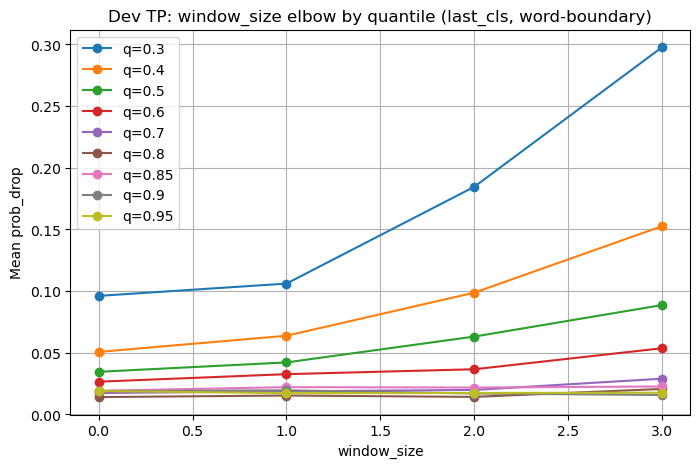

Saved plot: attention_results_aopc/attention_results_word_boundary/attention_dev_window_elbow_by_quantile_last_cls_word_boundary.png


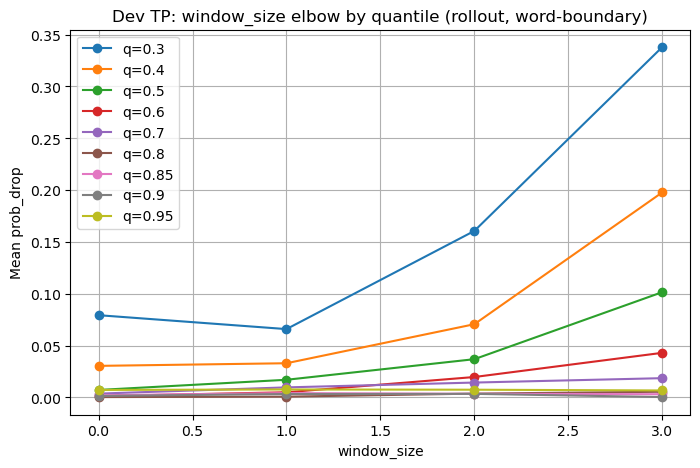

Saved plot: attention_results_aopc/attention_results_word_boundary/attention_dev_window_elbow_by_quantile_rollout_word_boundary.png


In [51]:
for method in sorted(dev_config_summary_word_boundary["attention_method"].unique()):
    method_df = dev_config_summary_word_boundary[
        dev_config_summary_word_boundary["attention_method"] == method
    ].copy()
    
    plt.figure(figsize=(8, 5))
    
    for quantile in sorted(method_df["quantile"].unique()):
        subset = method_df[
            method_df["quantile"] == quantile
        ].sort_values("window_size")
        
        plt.plot(
            subset["window_size"],
            subset["mean_prob_drop"],
            marker="o",
            label=f"q={quantile}"
        )
    
    plt.xlabel("window_size")
    plt.ylabel("Mean prob_drop")
    plt.title(f"Dev TP: window_size elbow by quantile ({method}, word-boundary)")
    plt.grid(True)
    plt.legend()
    
    plot_path = WORD_BOUNDARY_OUTPUT_DIR / f"attention_dev_window_elbow_by_quantile_{method}_word_boundary.png"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Saved plot:", plot_path)

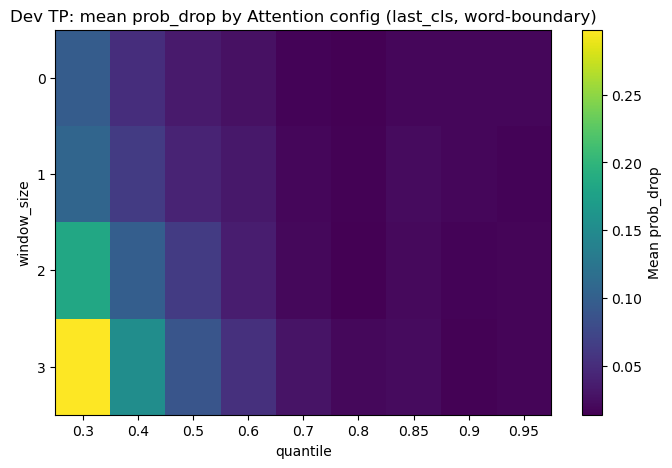

Saved plot: attention_results_aopc/attention_results_word_boundary/attention_dev_find_config_heatmap_last_cls_word_boundary.png


quantile,0.30,0.40,0.50,0.60,0.70,0.80,0.85,0.90,0.95
window_size,,,,,,,,,
0,0.096136,0.050718,0.034600,0.026587,0.017344,0.014109,0.019233,0.018877,0.018981
1,0.106102,0.063831,0.042210,0.032681,0.018780,0.015384,0.022171,0.019601,0.017305
2,0.184610,0.098769,0.063163,0.036673,0.019899,0.014279,0.021834,0.017001,0.017467
3,0.297806,0.152707,0.088733,0.053725,0.029025,0.020721,0.022712,0.015812,0.017657


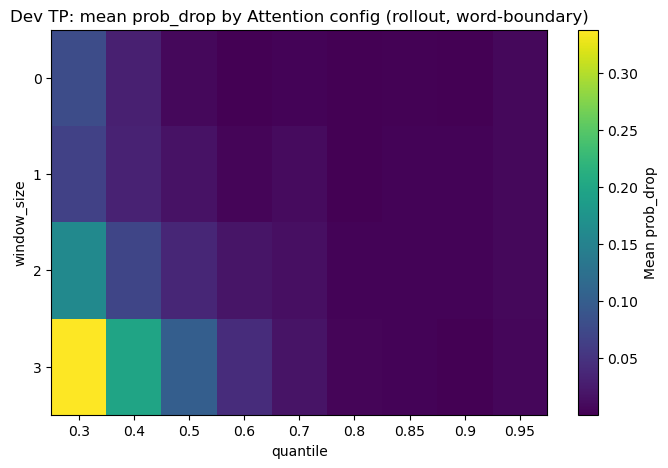

Saved plot: attention_results_aopc/attention_results_word_boundary/attention_dev_find_config_heatmap_rollout_word_boundary.png


quantile,0.30,0.40,0.50,0.60,0.70,0.80,0.85,0.90,0.95
window_size,,,,,,,,,
0,0.079341,0.030468,0.007233,0.001292,0.003714,0.000367,0.002091,0.001462,0.007250
1,0.065935,0.033004,0.017052,0.005013,0.009717,0.000777,0.004207,0.003339,0.007707
2,0.160618,0.070645,0.036914,0.019722,0.014371,0.003712,0.003535,0.003475,0.007472
3,0.337927,0.197775,0.101551,0.043043,0.018609,0.005515,0.003143,0.000401,0.006744


In [52]:
for method in sorted(dev_config_summary_word_boundary["attention_method"].unique()):
    method_df = dev_config_summary_word_boundary[
        dev_config_summary_word_boundary["attention_method"] == method
    ].copy()
    
    heatmap_data = method_df.pivot(
        index="window_size",
        columns="quantile",
        values="mean_prob_drop"
    )
    
    plt.figure(figsize=(8, 5))
    plt.imshow(heatmap_data, aspect="auto")
    plt.colorbar(label="Mean prob_drop")
    
    plt.xticks(
        ticks=np.arange(len(heatmap_data.columns)),
        labels=heatmap_data.columns
    )
    plt.yticks(
        ticks=np.arange(len(heatmap_data.index)),
        labels=heatmap_data.index
    )
    
    plt.xlabel("quantile")
    plt.ylabel("window_size")
    plt.title(f"Dev TP: mean prob_drop by Attention config ({method}, word-boundary)")
    
    plot_path = WORD_BOUNDARY_OUTPUT_DIR / f"attention_dev_find_config_heatmap_{method}_word_boundary.png"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Saved plot:", plot_path)
    display(heatmap_data)

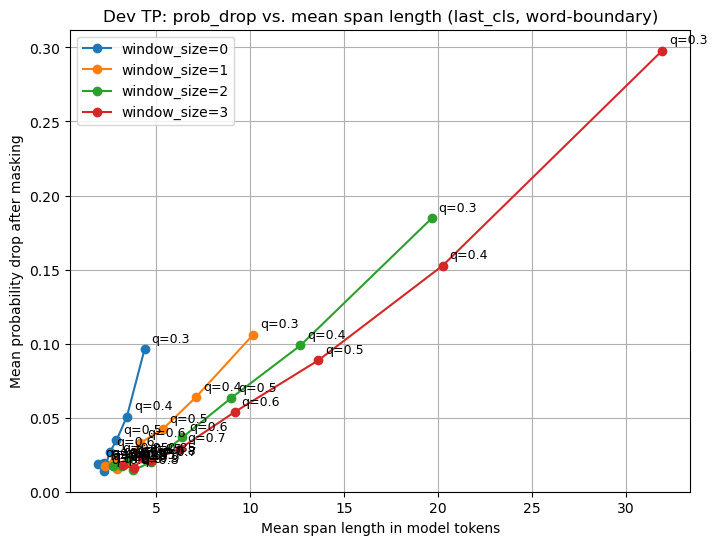

Saved plot: attention_results_aopc/attention_results_word_boundary/attention_dev_prob_drop_vs_mean_span_len_last_cls_word_boundary.png


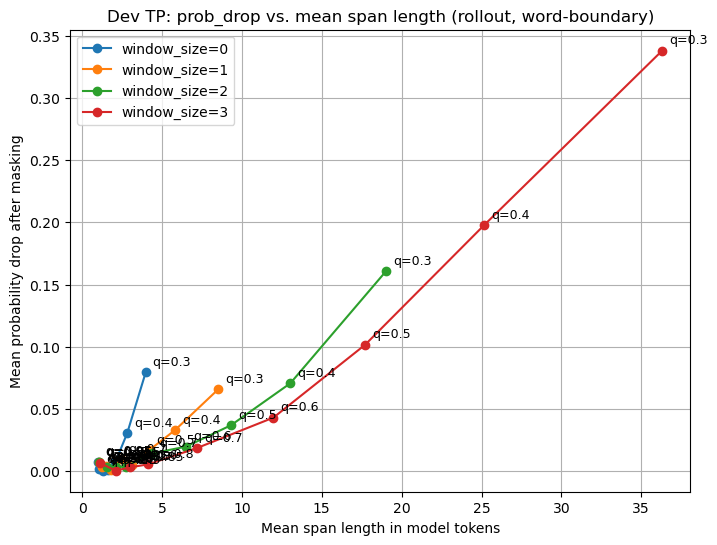

Saved plot: attention_results_aopc/attention_results_word_boundary/attention_dev_prob_drop_vs_mean_span_len_rollout_word_boundary.png


In [53]:
for method in sorted(dev_config_summary_word_boundary["attention_method"].unique()):
    method_df = dev_config_summary_word_boundary[
        dev_config_summary_word_boundary["attention_method"] == method
    ].copy()
    
    plt.figure(figsize=(8, 6))
    
    for window_size in sorted(method_df["window_size"].unique()):
        subset = method_df[
            method_df["window_size"] == window_size
        ].sort_values("quantile")
        
        plt.plot(
            subset["mean_span_len_tokens"],
            subset["mean_prob_drop"],
            marker="o",
            label=f"window_size={window_size}"
        )
        
        for _, row in subset.iterrows():
            plt.annotate(
                f"q={row['quantile']}",
                (row["mean_span_len_tokens"], row["mean_prob_drop"]),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=9
            )
    
    plt.xlabel("Mean span length in model tokens")
    plt.ylabel("Mean probability drop after masking")
    plt.title(f"Dev TP: prob_drop vs. mean span length ({method}, word-boundary)")
    plt.grid(True)
    plt.legend()
    
    plot_path = WORD_BOUNDARY_OUTPUT_DIR / f"attention_dev_prob_drop_vs_mean_span_len_{method}_word_boundary.png"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Saved plot:", plot_path)

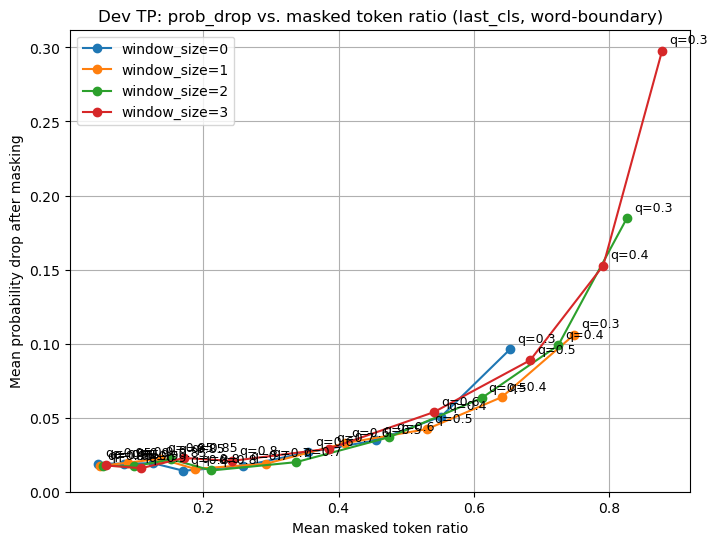

Saved plot: attention_results_aopc/attention_results_word_boundary/attention_dev_prob_drop_vs_masked_token_ratio_last_cls_word_boundary.png


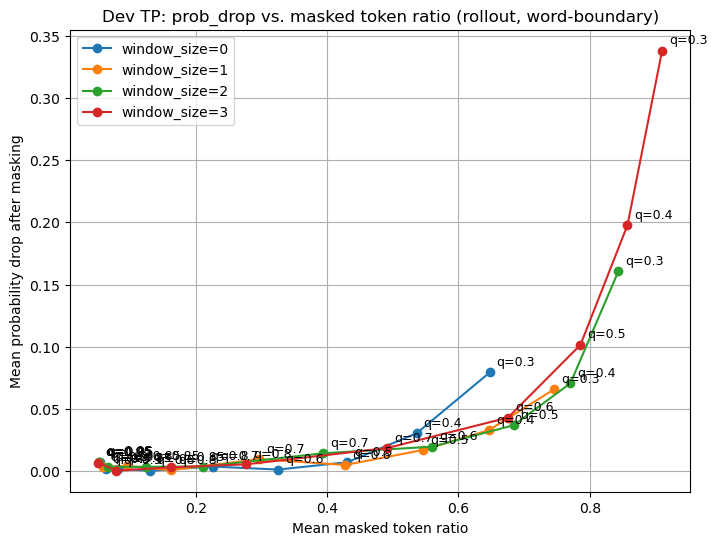

Saved plot: attention_results_aopc/attention_results_word_boundary/attention_dev_prob_drop_vs_masked_token_ratio_rollout_word_boundary.png


In [54]:
for method in sorted(dev_config_summary_word_boundary["attention_method"].unique()):
    method_df = dev_config_summary_word_boundary[
        dev_config_summary_word_boundary["attention_method"] == method
    ].copy()
    
    plt.figure(figsize=(8, 6))
    
    for window_size in sorted(method_df["window_size"].unique()):
        subset = method_df[
            method_df["window_size"] == window_size
        ].sort_values("quantile")
        
        plt.plot(
            subset["mean_masked_token_ratio"],
            subset["mean_prob_drop"],
            marker="o",
            label=f"window_size={window_size}"
        )
        
        for _, row in subset.iterrows():
            plt.annotate(
                f"q={row['quantile']}",
                (row["mean_masked_token_ratio"], row["mean_prob_drop"]),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=9
            )
    
    plt.xlabel("Mean masked token ratio")
    plt.ylabel("Mean probability drop after masking")
    plt.title(f"Dev TP: prob_drop vs. masked token ratio ({method}, word-boundary)")
    plt.grid(True)
    plt.legend()
    
    plot_path = WORD_BOUNDARY_OUTPUT_DIR / f"attention_dev_prob_drop_vs_masked_token_ratio_{method}_word_boundary.png"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Saved plot:", plot_path)

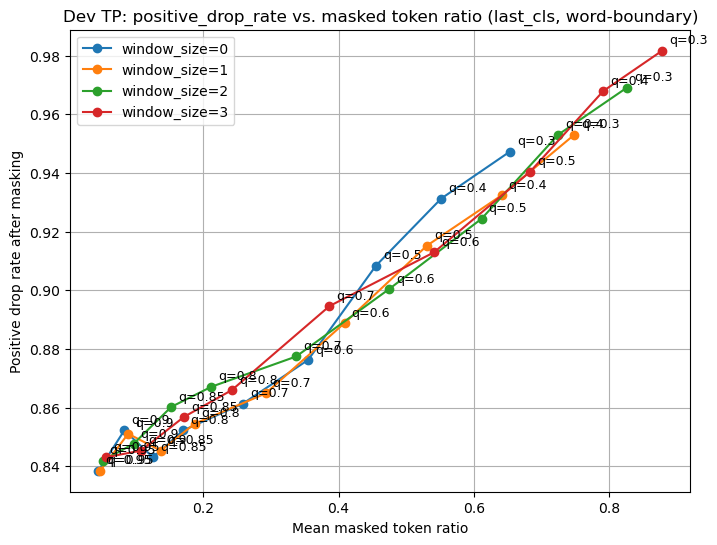

Saved plot: attention_results_aopc/attention_results_word_boundary/attention_dev_positive_drop_rate_vs_masked_token_ratio_last_cls_word_boundary.png


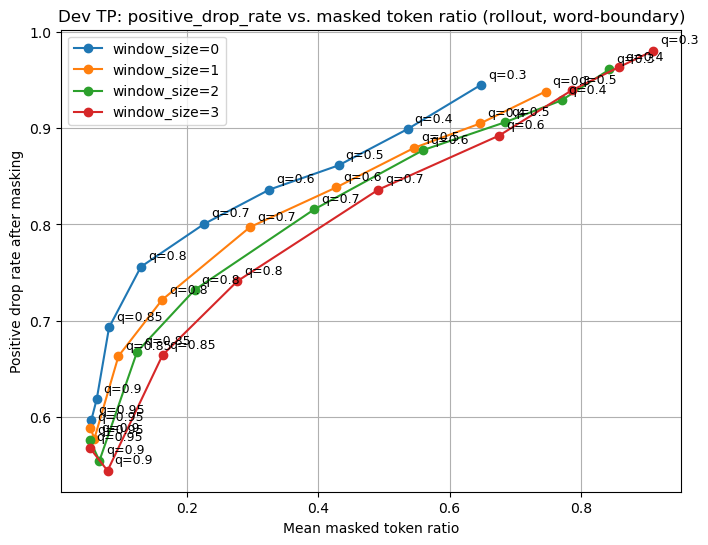

Saved plot: attention_results_aopc/attention_results_word_boundary/attention_dev_positive_drop_rate_vs_masked_token_ratio_rollout_word_boundary.png


In [55]:
for method in sorted(dev_config_summary_word_boundary["attention_method"].unique()):
    method_df = dev_config_summary_word_boundary[
        dev_config_summary_word_boundary["attention_method"] == method
    ].copy()
    
    plt.figure(figsize=(8, 6))
    
    for window_size in sorted(method_df["window_size"].unique()):
        subset = method_df[
            method_df["window_size"] == window_size
        ].sort_values("quantile")
        
        plt.plot(
            subset["mean_masked_token_ratio"],
            subset["positive_drop_rate"],
            marker="o",
            label=f"window_size={window_size}"
        )
        
        for _, row in subset.iterrows():
            plt.annotate(
                f"q={row['quantile']}",
                (row["mean_masked_token_ratio"], row["positive_drop_rate"]),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=9
            )
    
    plt.xlabel("Mean masked token ratio")
    plt.ylabel("Positive drop rate after masking")
    plt.title(f"Dev TP: positive_drop_rate vs. masked token ratio ({method}, word-boundary)")
    plt.grid(True)
    plt.legend()
    
    plot_path = WORD_BOUNDARY_OUTPUT_DIR / f"attention_dev_positive_drop_rate_vs_masked_token_ratio_{method}_word_boundary.png"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Saved plot:", plot_path)

In [56]:
# Final config after repeating validation with word-boundary post-processing.
# Set these values based on the plots and summary above.

BEST_ATTENTION_METHOD = "last_cls"
BEST_QUANTILE = 0.4
BEST_WINDOW_SIZE = 0

selected_config_summary_word_boundary = dev_config_summary_word_boundary[
    (dev_config_summary_word_boundary["attention_method"] == BEST_ATTENTION_METHOD) &
    (dev_config_summary_word_boundary["quantile"] == BEST_QUANTILE) &
    (dev_config_summary_word_boundary["window_size"] == BEST_WINDOW_SIZE)
]

display(selected_config_summary_word_boundary)

,attention_method,window_size,quantile,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,strong_drop_rate_001,strong_drop_rate_005,...,mean_masked_token_ratio,n_spans,mean_span_len_tokens,median_span_len_tokens,mean_span_len_chars,median_span_len_chars,mean_span_score_sum_attention,mean_span_score_mean_attention,prob_drop_per_masked_token,prob_drop_per_masked_ratio
1,last_cls,0,0.4,873,0.050718,0.004405,0.157775,0.931271,0.323024,0.147766,...,0.551774,12894,3.454165,2.0,14.189623,7.0,0.053386,0.012498,0.000994,0.091917


## Selected attention configuration using word boundary

The final attention configuration is selected only after repeating the validation-based analysis with word-boundary post-processing.

The selected configuration is therefore based on:

- raw attention scoring,
- span extraction via quantile and window size,
- word-boundary expansion,
- removal of punctuation-only artifacts,
- masking-based validation on validation true positives.

Selected configuration:

- `attention_method = last_cls`
- `quantile = 0.4`
- `window_size = 0`

## Run AOPC with word boundary

In [ ]:
dev_aopc_word_boundary_df = run_attention_aopc_on_indices(
    df=dev_df,
    matrix_positions=dev_tp_positions,
    attention_methods=ATTENTION_METHODS,
    fractions=AOPC_FRACTIONS,
    random_runs=AOPC_RANDOM_RUNS,
    random_seed=AOPC_RANDOM_SEED,
    mask_token=MASK_TOKEN,
    attention_cache=dev_attention_cache,
    use_word_boundary=True
)

dev_aopc_word_boundary_step_df, dev_aopc_word_boundary_curve_summary, dev_aopc_word_boundary_per_argument, dev_aopc_word_boundary_global_summary = summarize_attention_aopc_results(
    dev_aopc_word_boundary_df
)

display(dev_aopc_word_boundary_curve_summary)
display(dev_aopc_word_boundary_global_summary)

save_aopc_outputs(
    aopc_df=dev_aopc_word_boundary_df,
    step_df=dev_aopc_word_boundary_step_df,
    curve_summary=dev_aopc_word_boundary_curve_summary,
    per_argument_aopc=dev_aopc_word_boundary_per_argument,
    global_summary=dev_aopc_word_boundary_global_summary,
    output_dir=WORD_BOUNDARY_OUTPUT_DIR / "aopc_ranking_evaluation",
    prefix="attention_aopc_dev_tp_word_boundary"
)

AOPC Attention (word_boundary):   0%|          | 0/873 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/6002 [00:00<?, ?it/s]

,aopc_variant,attention_method,ranking_method,perturbation_fraction,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,mean_p_original,mean_p_masked,mean_masked_token_ratio,median_masked_token_ratio,mean_selected_token_ratio,mean_top_k_tokens,mean_total_masked_tokens,mean_total_masked_chars,mean_n_merged_spans,fallback_rate
0,word_boundary,last_cls,attention,0.01,873,0.017169,0.000299,0.115508,0.814433,0.98933,0.972161,0.022772,0.014706,0.021862,1.447881,1.387171,4.261168,1.084765,0.081329
1,word_boundary,last_cls,attention,0.05,873,0.018981,0.000507,0.122094,0.838488,0.98933,0.970349,0.045178,0.040698,0.058187,5.087056,3.709049,12.088202,1.911798,0.026346
2,word_boundary,last_cls,attention,0.10,873,0.018877,0.000638,0.126769,0.852234,0.98933,0.970453,0.083391,0.076923,0.108836,9.709049,7.391753,23.780069,3.317297,0.003436
3,word_boundary,last_cls,attention,0.20,873,0.014109,0.000916,0.103808,0.852234,0.98933,0.975221,0.170475,0.166667,0.207797,18.922108,15.734250,52.688431,7.045819,0.000000
4,word_boundary,last_cls,attention,0.50,873,0.034600,0.002502,0.146845,0.908362,0.98933,0.954730,0.455232,0.454545,0.505060,46.528064,41.852234,164.863688,14.449026,0.000000
5,word_boundary,last_cls,random,0.01,873,0.002335,0.000006,0.021861,0.541810,0.98933,0.986995,0.025035,0.017241,0.021862,1.447881,1.643070,5.902291,1.357045,0.079954
6,word_boundary,last_cls,random,0.05,873,0.001400,0.000106,0.032751,0.713631,0.98933,0.987930,0.061699,0.057333,0.058187,5.087056,5.385796,20.567354,4.306873,0.011569
7,word_boundary,last_cls,random,0.10,873,0.000686,0.000233,0.042500,0.780069,0.98933,0.988644,0.112611,0.107792,0.108836,9.709049,10.077434,39.198511,7.781558,0.001031
8,word_boundary,last_cls,random,0.20,873,0.003683,0.000436,0.052747,0.825888,0.98933,0.985647,0.209450,0.204651,0.207797,18.922108,19.093356,76.383620,13.590722,0.000000
9,word_boundary,last_cls,random,0.50,873,0.012246,0.001793,0.064245,0.901489,0.98933,0.977084,0.487025,0.487054,0.505060,46.528064,44.947995,192.939404,21.626117,0.000000


,aopc_variant,attention_method,ranking_method,n_arguments,aopc_mean_prob_drop,aopc_median_prob_drop,aopc_std_prob_drop,mean_positive_steps_rate,mean_masked_token_ratio,mean_max_masked_token_ratio,mean_total_masked_tokens,fallback_rate
0,word_boundary,last_cls,attention,873,0.020747,0.001213,0.085385,0.853150,0.155410,0.455232,14.014891,0.022222
1,word_boundary,last_cls,random,873,0.004070,0.000603,0.036339,0.752577,0.179164,0.487025,16.229530,0.018511
2,word_boundary,rollout,attention,873,0.003288,0.000438,0.049035,0.625430,0.140025,0.431359,12.472852,0.428637
3,word_boundary,rollout,random,873,0.003964,0.000546,0.034369,0.748912,0.179495,0.487267,16.227010,0.017228


Saved:
attention_results_aopc/attention_results_word_boundary/aopc_ranking_evaluation/attention_aopc_dev_tp_word_boundary_raw.csv
attention_results_aopc/attention_results_word_boundary/aopc_ranking_evaluation/attention_aopc_dev_tp_word_boundary_step_summary.csv
attention_results_aopc/attention_results_word_boundary/aopc_ranking_evaluation/attention_aopc_dev_tp_word_boundary_curve_summary.csv
attention_results_aopc/attention_results_word_boundary/aopc_ranking_evaluation/attention_aopc_dev_tp_word_boundary_per_argument.csv
attention_results_aopc/attention_results_word_boundary/aopc_ranking_evaluation/attention_aopc_dev_tp_word_boundary_global_summary.csv


# Run best Word Boundary Config

In [58]:
def run_final_attention_word_boundary_on_split(df, split_name):
    """
    Run the selected raw attention configuration on one split,
    then apply word-boundary post-processing before exporting results.
    """
    positions = list(range(len(df)))
    
    raw_results = run_attention_config_on_indices(
        df=df,
        matrix_positions=positions,
        attention_methods=[BEST_ATTENTION_METHOD],
        quantile_values=[BEST_QUANTILE],
        window_size_values=[BEST_WINDOW_SIZE],
        mask_token=MASK_TOKEN
    )
    
    word_boundary_results = apply_word_boundary_to_argument_results(raw_results)
    
    argument_df = build_argument_level_df(word_boundary_results)
    span_df = build_span_level_df(word_boundary_results)
    
    print(f"{split_name} argument level:", argument_df.shape)
    print(f"{split_name} span level:", span_df.shape)
    
    return word_boundary_results, argument_df, span_df


train_results, train_argument_df, train_span_df = run_final_attention_word_boundary_on_split(
    train_df,
    "train"
)

val_results, val_argument_df, val_span_df = run_final_attention_word_boundary_on_split(
    val_df,
    "validation"
)

test_results, test_argument_df, test_span_df = run_final_attention_word_boundary_on_split(
    test_df,
    "test"
)

Building attention spans:   0%|          | 0/1533 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/96 [00:00<?, ?it/s]

Applying word-boundary post-processing:   0%|          | 0/1533 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/96 [00:00<?, ?it/s]

train argument level: (1533, 43)
train span level: (24735, 36)


...

Building attention spans:   0%|          | 0/438 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/28 [00:00<?, ?it/s]

Applying word-boundary post-processing:   0%|          | 0/438 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/28 [00:00<?, ?it/s]

test argument level: (438, 43)
test span level: (7086, 36)


In [59]:
final_argument_df = pd.concat(
    [train_argument_df, val_argument_df, test_argument_df],
    ignore_index=True
)

final_span_df = pd.concat(
    [train_span_df, val_span_df, test_span_df],
    ignore_index=True
)

display(final_argument_df.head())
display(final_span_df.head())

print("Final argument-level rows:", len(final_argument_df))
print("Final span-level rows:", len(final_span_df))

,global_row_id,split,post_id,issue,label,predicted_label,predicted_score,confusion_type,is_true_positive,is_false_negative,...,merged_span_texts,merged_span_token_start_indices,merged_span_token_end_indices,merged_span_char_start_indices,merged_span_char_end_indices,selected_tokens_json,merged_spans_json,text,masked_text,error
0,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,[people cant be forced to wear school uniforms...,"[1, 15, 21, 27, 36, 41]","[13, 15, 21, 34, 36, 41]","[0, 66, 93, 119, 167, 201]","[58, 69, 97, 156, 173, 204]","[""▁people"", ""▁can"", ""t"", ""▁be"", ""▁forced"", ""▁t...","[{""char_start"": 0, ""char_end"": 58, ""token_star...","people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None
1,1,train,2,Firefox vs internet explorer:,1,LABEL_1,0.998218,TP,True,False,...,"[That form of argument degrades this forum, an...","[1, 17, 26, 32, 38, 44, 46, 56, 62, 64, 67, 71...","[15, 22, 29, 33, 39, 44, 46, 57, 62, 64, 67, 7...","[0, 83, 126, 141, 165, 189, 199, 253, 279, 287...","[79, 118, 138, 145, 173, 190, 203, 263, 280, 2...","[""▁That"", ""▁form"", ""▁of"", ""▁argument"", ""▁degra...","[{""char_start"": 0, ""char_end"": 79, ""token_star...","That form of argument degrades this forum, and...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None
2,2,train,3,If your spouse committed murder and he or she ...,0,LABEL_0,0.969683,TN,False,False,...,"[I wouldnt turn her in becuase she is my wife,...","[1, 15, 24, 26, 28, 30, 33, 35, 40]","[10, 16, 24, 26, 28, 31, 34, 37, 40]","[0, 57, 93, 105, 111, 122, 135, 142, 159]","[44, 69, 96, 107, 118, 130, 141, 150, 161]","[""▁I"", ""▁wouldnt"", ""▁turn"", ""▁her"", ""▁in"", ""▁b...","[{""char_start"": 0, ""char_end"": 44, ""token_star...",I wouldnt turn her in becuase she is my wife. ...,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None
3,3,train,4,If your spouse committed murder and he or she ...,1,LABEL_1,0.998705,TP,True,False,...,"[No I wouldn't turn, my spouse. Just, i, doesn...","[1, 8, 16, 20, 24, 29]","[6, 11, 16, 22, 25, 30]","[0, 22, 60, 85, 98, 122]","[18, 37, 61, 92, 104, 133]","[""▁No"", ""▁I"", ""▁wouldn"", ""'"", ""t"", ""▁turn"", ""▁...","[{""char_start"": 0, ""char_end"": 18, ""token_star...",No I wouldn't turn in my spouse. Just because ...,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] in [...,None
4,4,train,5,Tv is better than books:,1,LABEL_1,0.998405,TP,True,False,...,[TV is terrible. Except for Spongebob maybe. T...,"[1, 19, 23, 26, 31]","[13, 19, 23, 29, 31]","[0, 75, 102, 112, 124]","[53, 78, 104, 118, 126]","[""▁TV"", ""▁is"", ""▁terrible"", ""."", ""▁Except"", ""▁...","[{""char_start"": 0, ""char_end"": 53, ""token_star...",TV is terrible. Except for Spongebob maybe. Th...,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None


,global_row_id,split,post_id,issue,label,predicted_label,confusion_type,is_true_positive,is_false_negative,is_false_positive,...,span_score_max_attention,p_inappropriate_original,p_inappropriate_masked,prob_drop,n_model_tokens,n_selected_tokens,selected_token_ratio,masked_token_ratio,text,masked_text
0,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,0.091563,0.997032,0.968815,0.028218,42,25,0.595238,0.595238,"people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...
1,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,0.015857,0.997032,0.968815,0.028218,42,25,0.595238,0.595238,"people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...
2,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,0.018986,0.997032,0.968815,0.028218,42,25,0.595238,0.595238,"people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...
3,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,0.056030,0.997032,0.968815,0.028218,42,25,0.595238,0.595238,"people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...
4,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,0.024787,0.997032,0.968815,0.028218,42,25,0.595238,0.595238,"people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...


Final argument-level rows: 2191
Final span-level rows: 35414


In [60]:
final_argument_df_valid = final_argument_df[
    final_argument_df["error"].isna()
].copy()

overall_summary = (
    final_argument_df_valid
    .groupby(["split", "attention_method", "window_size", "quantile"])
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        strong_drop_rate_001=("prob_drop", lambda x: (x > 0.01).mean()),
        strong_drop_rate_005=("prob_drop", lambda x: (x > 0.05).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
    )
    .reset_index()
)

confusion_summary = (
    final_argument_df_valid
    .groupby(["split", "confusion_type"])
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
    )
    .reset_index()
    .sort_values(["split", "confusion_type"])
)

display(overall_summary)
display(confusion_summary)

,split,attention_method,window_size,quantile,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,strong_drop_rate_001,strong_drop_rate_005,mean_p_original,mean_p_masked,mean_n_merged_spans,mean_total_masked_tokens,mean_masked_token_ratio
0,test,last_cls,0,0.4,438,-0.272314,0.001206,0.444871,0.531963,0.198630,0.100457,0.590804,0.863119,16.178082,53.392694,0.554943
1,train,last_cls,0,0.4,1533,-0.308465,0.000240,0.459289,0.502283,0.174168,0.081539,0.552141,0.860606,16.135029,53.456621,0.556036
2,validation,last_cls,0,0.4,220,-0.299371,-0.007394,0.448669,0.468182,0.186364,0.100000,0.542075,0.841446,16.331818,54.290909,0.559968


,split,confusion_type,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,mean_p_original,mean_p_masked,mean_n_merged_spans,mean_total_masked_tokens,mean_masked_token_ratio
0,test,FN,39,-0.775824,-0.942889,0.287298,0.000000,0.049638,0.825463,19.461538,61.230769,0.563569
1,test,FP,71,0.061122,0.007566,0.198567,0.845070,0.971585,0.910463,14.267606,46.591549,0.552957
2,test,TN,142,-0.703820,-0.890042,0.327453,0.014085,0.037216,0.741036,19.070423,61.683099,0.562017
3,test,TP,186,0.035410,0.003776,0.140218,0.919355,0.981555,0.946145,14.010753,48.016129,0.548492
4,train,FN,48,-0.592608,-0.756766,0.376124,0.020833,0.115297,0.707905,14.729167,48.208333,0.566371
5,train,FP,48,-0.024328,0.001723,0.228285,0.625000,0.915789,0.940117,13.062500,45.395833,0.564131
6,train,TN,652,-0.743900,-0.922566,0.303171,0.004601,0.030158,0.774058,18.168712,57.418712,0.560465
7,train,TP,785,0.053196,0.004440,0.160468,0.937580,0.990161,0.936965,14.719745,50.979618,0.551230
8,validation,FN,36,-0.732577,-0.935455,0.344678,0.027778,0.040580,0.773157,19.361111,64.055556,0.564026
9,validation,FP,30,0.105419,0.007660,0.230478,0.833333,0.968823,0.863404,14.500000,48.300000,0.556185


In [61]:
test_argument_df_valid = test_argument_df[
    test_argument_df["error"].isna()
].copy()

test_overall_summary = (
    test_argument_df_valid
    .groupby(["attention_method", "window_size", "quantile"])
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        strong_drop_rate_001=("prob_drop", lambda x: (x > 0.01).mean()),
        strong_drop_rate_005=("prob_drop", lambda x: (x > 0.05).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
    )
    .reset_index()
)

test_confusion_summary = (
    test_argument_df_valid
    .groupby("confusion_type")
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
    )
    .reset_index()
    .sort_values("confusion_type")
)

display(test_overall_summary)
display(test_confusion_summary)

,attention_method,window_size,quantile,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,strong_drop_rate_001,strong_drop_rate_005,mean_p_original,mean_p_masked,mean_n_merged_spans,mean_total_masked_tokens,mean_masked_token_ratio
0,last_cls,0,0.4,438,-0.272314,0.001206,0.444871,0.531963,0.19863,0.100457,0.590804,0.863119,16.178082,53.392694,0.554943


,confusion_type,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,mean_p_original,mean_p_masked,mean_n_merged_spans,mean_total_masked_tokens,mean_masked_token_ratio
0,FN,39,-0.775824,-0.942889,0.287298,0.000000,0.049638,0.825463,19.461538,61.230769,0.563569
1,FP,71,0.061122,0.007566,0.198567,0.845070,0.971585,0.910463,14.267606,46.591549,0.552957
2,TN,142,-0.703820,-0.890042,0.327453,0.014085,0.037216,0.741036,19.070423,61.683099,0.562017
3,TP,186,0.035410,0.003776,0.140218,0.919355,0.981555,0.946145,14.010753,48.016129,0.548492


In [62]:
final_output_dir = OUTPUT_DIR / "attention_results_word_boundary" 
final_output_dir.mkdir(parents=True, exist_ok=True)

argument_csv_path = final_output_dir / (
    f"attention_final_all_splits_{BEST_ATTENTION_METHOD}"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_argument_level.csv"
)

span_csv_path = final_output_dir / (
    f"attention_final_all_splits_{BEST_ATTENTION_METHOD}"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_span_level.csv"
)

overall_summary_csv_path = final_output_dir / (
    f"attention_final_all_splits_{BEST_ATTENTION_METHOD}"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_overall_summary.csv"
)

confusion_summary_csv_path = final_output_dir / (
    f"attention_final_all_splits_{BEST_ATTENTION_METHOD}"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_confusion_summary.csv"
)

test_summary_csv_path = final_output_dir / (
    f"attention_final_test_{BEST_ATTENTION_METHOD}"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_summary.csv"
)

jsonl_path = final_output_dir / (
    f"attention_final_all_splits_{BEST_ATTENTION_METHOD}"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_argument_level.jsonl"
)

final_argument_df.to_csv(argument_csv_path, index=False, encoding="utf-8")
final_span_df.to_csv(span_csv_path, index=False, encoding="utf-8")
overall_summary.to_csv(overall_summary_csv_path, index=False, encoding="utf-8")
confusion_summary.to_csv(confusion_summary_csv_path, index=False, encoding="utf-8")
test_overall_summary.to_csv(test_summary_csv_path, index=False, encoding="utf-8")

all_results = train_results + val_results + test_results

with open(jsonl_path, "w", encoding="utf-8") as f:
    for result in all_results:
        safe_result = make_json_serializable(result)
        f.write(json.dumps(safe_result, ensure_ascii=False) + "\n")

print("Saved:")
print(argument_csv_path)
print(span_csv_path)
print(overall_summary_csv_path)
print(confusion_summary_csv_path)
print(test_summary_csv_path)
print(jsonl_path)

Saved:
attention_results_aopc/attention_results_word_boundary/attention_final_all_splits_last_cls_q0.4_window0_argument_level.csv
attention_results_aopc/attention_results_word_boundary/attention_final_all_splits_last_cls_q0.4_window0_span_level.csv
attention_results_aopc/attention_results_word_boundary/attention_final_all_splits_last_cls_q0.4_window0_overall_summary.csv
attention_results_aopc/attention_results_word_boundary/attention_final_all_splits_last_cls_q0.4_window0_confusion_summary.csv
attention_results_aopc/attention_results_word_boundary/attention_final_test_last_cls_q0.4_window0_summary.csv
attention_results_aopc/attention_results_word_boundary/attention_final_all_splits_last_cls_q0.4_window0_argument_level.jsonl


In [63]:
# Best test examples by probability drop
tmp = (
    test_argument_df_valid
    .sort_values("prob_drop", ascending=False)
    .reset_index(drop=True)
)

for i in range(min(5, len(tmp))):
    show_attention_example(tmp, index=i)

In [64]:
# Test examples with the smallest or negative probability drops
tmp_low = (
    test_argument_df_valid
    .sort_values("prob_drop", ascending=True)
    .reset_index(drop=True)
)

for i in range(min(5, len(tmp_low))):
    show_attention_example(tmp_low, index=i)

# Raw vs Word Boundary comparisons

,aopc_variant,attention_method,ranking_method,perturbation_fraction,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,mean_p_original,mean_p_masked,mean_masked_token_ratio,median_masked_token_ratio,mean_selected_token_ratio,mean_top_k_tokens,mean_total_masked_tokens,mean_total_masked_chars,mean_n_merged_spans,fallback_rate
0,raw_attention,last_cls,attention,0.01,873,0.013397,0.000248,0.106717,0.766323,0.98933,0.975933,0.021825,0.015504,0.021862,1.447881,1.446735,4.176403,1.289805,0.000000
1,raw_attention,last_cls,attention,0.05,873,0.022878,0.000578,0.136576,0.841924,0.98933,0.966452,0.058150,0.054878,0.058187,5.087056,5.085911,12.784651,3.608247,0.000000
2,raw_attention,last_cls,attention,0.10,873,0.021796,0.000957,0.129178,0.878580,0.98933,0.967534,0.108799,0.104895,0.108836,9.709049,9.707904,24.360825,6.468499,0.000000
3,raw_attention,last_cls,attention,0.20,873,0.019480,0.001761,0.114929,0.896907,0.98933,0.969850,0.207722,0.204420,0.207797,18.922108,18.918671,53.646048,10.650630,0.000000
4,raw_attention,last_cls,attention,0.50,873,0.076464,0.011071,0.167319,0.951890,0.98933,0.912866,0.505040,0.502488,0.505060,46.528064,46.525773,168.122566,17.071019,0.000000
5,raw_attention,last_cls,random,0.01,873,0.002772,0.000002,0.022991,0.513173,0.98933,0.986558,0.021851,0.015504,0.021862,1.447881,1.447537,5.301375,1.442153,0.000000
6,raw_attention,last_cls,random,0.05,873,0.001813,0.000125,0.033373,0.714777,0.98933,0.987517,0.058170,0.054878,0.058187,5.087056,5.086483,19.007560,4.855899,0.000000
7,raw_attention,last_cls,random,0.10,873,0.001741,0.000254,0.041150,0.797251,0.98933,0.987589,0.108818,0.104938,0.108836,9.709049,9.708362,36.756586,8.778923,0.000000
8,raw_attention,last_cls,random,0.20,873,0.005425,0.000464,0.054061,0.837342,0.98933,0.983905,0.207772,0.204545,0.207797,18.922108,18.921077,73.119015,15.255441,0.000000
9,raw_attention,last_cls,random,0.50,873,0.018416,0.003384,0.069451,0.924399,0.98933,0.970914,0.505043,0.502513,0.505060,46.528064,46.527262,191.240206,23.643757,0.000000


,aopc_variant,attention_method,ranking_method,n_arguments,aopc_mean_prob_drop,aopc_median_prob_drop,aopc_std_prob_drop,mean_positive_steps_rate,mean_masked_token_ratio,mean_max_masked_token_ratio,mean_total_masked_tokens,fallback_rate
0,raw_attention,last_cls,attention,873,0.030803,0.003480,0.092046,0.867125,0.180307,0.505040,16.336999,0.000000
1,raw_attention,last_cls,random,873,0.006033,0.000989,0.036571,0.757388,0.180331,0.505043,16.338144,0.000000
2,raw_attention,rollout,attention,873,0.032438,0.007102,0.072840,0.694616,0.180286,0.505005,16.335624,0.000000
3,raw_attention,rollout,random,873,0.006540,0.000924,0.035184,0.743643,0.180327,0.505032,16.337892,0.000000
4,word_boundary,last_cls,attention,873,0.020747,0.001213,0.085385,0.853150,0.155410,0.455232,14.014891,0.022222
5,word_boundary,last_cls,random,873,0.004070,0.000603,0.036339,0.752577,0.179164,0.487025,16.229530,0.018511
6,word_boundary,rollout,attention,873,0.003288,0.000438,0.049035,0.625430,0.140025,0.431359,12.472852,0.428637
7,word_boundary,rollout,random,873,0.003964,0.000546,0.034369,0.748912,0.179495,0.487267,16.227010,0.017228


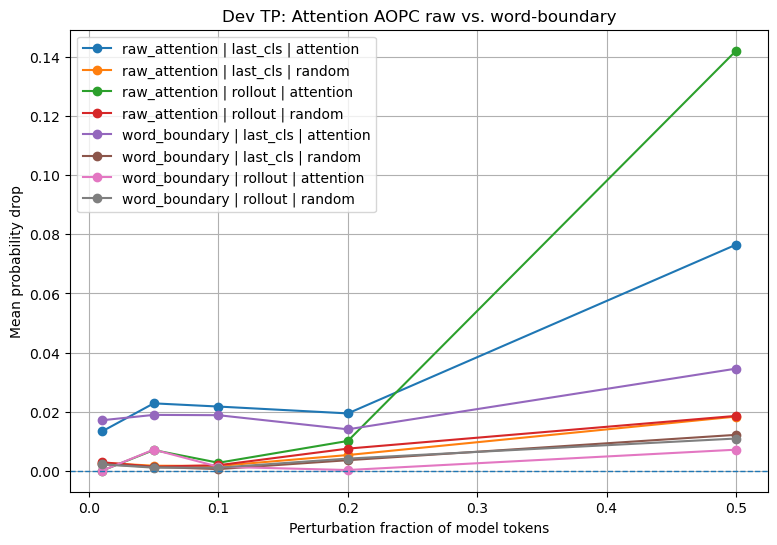

Saved plot: attention_results_aopc/aopc_ranking_evaluation/attention_aopc_dev_tp_raw_vs_word_boundary_curve.png


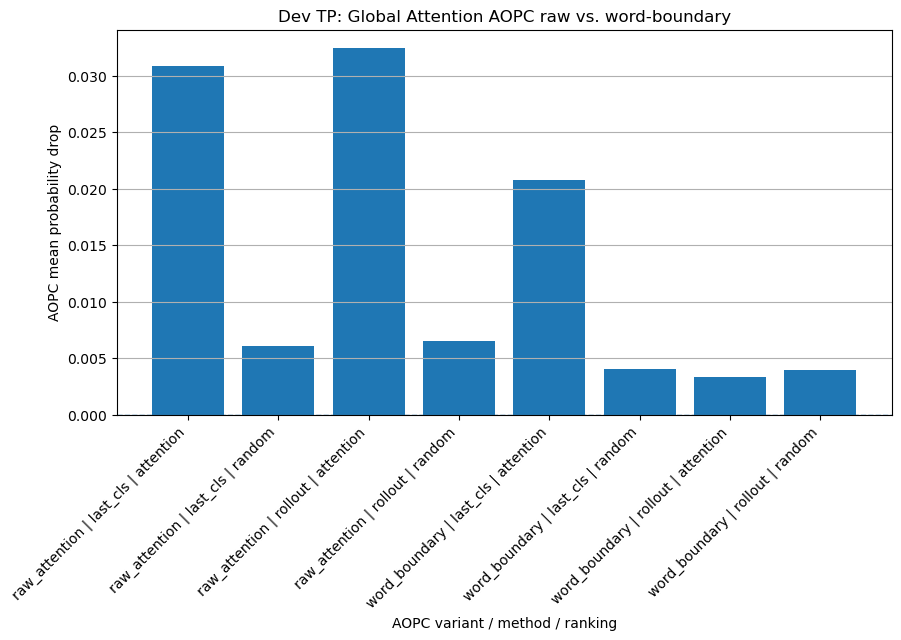

Saved plot: attention_results_aopc/aopc_ranking_evaluation/attention_aopc_dev_tp_raw_vs_word_boundary_global_bar.png


In [65]:
dev_aopc_curve_summary_combined = pd.concat(
    [
        dev_aopc_raw_curve_summary,
        dev_aopc_word_boundary_curve_summary
    ],
    ignore_index=True
)

dev_aopc_global_summary_combined = pd.concat(
    [
        dev_aopc_raw_global_summary,
        dev_aopc_word_boundary_global_summary
    ],
    ignore_index=True
)

display(dev_aopc_curve_summary_combined)
display(dev_aopc_global_summary_combined)

dev_aopc_curve_summary_combined.to_csv(
    AOPC_OUTPUT_DIR / "attention_aopc_dev_tp_raw_vs_word_boundary_curve_summary.csv",
    index=False,
    encoding="utf-8"
)

dev_aopc_global_summary_combined.to_csv(
    AOPC_OUTPUT_DIR / "attention_aopc_dev_tp_raw_vs_word_boundary_global_summary.csv",
    index=False,
    encoding="utf-8"
)

plot_attention_aopc_curve(
    curve_summary=dev_aopc_curve_summary_combined,
    output_dir=AOPC_OUTPUT_DIR,
    filename="attention_aopc_dev_tp_raw_vs_word_boundary_curve.png",
    title="Dev TP: Attention AOPC raw vs. word-boundary"
)

plot_attention_aopc_global_bar(
    global_summary=dev_aopc_global_summary_combined,
    output_dir=AOPC_OUTPUT_DIR,
    filename="attention_aopc_dev_tp_raw_vs_word_boundary_global_bar.png",
    title="Dev TP: Global Attention AOPC raw vs. word-boundary"
)

In [66]:
test_tp_positions = test_df.index[
    test_df["confusion_type"] == "TP"
].tolist()

print("Test examples:", len(test_df))
print("Test true positives:", len(test_tp_positions))

test_attention_cache = precompute_attention_cache(
    df=test_df,
    matrix_positions=test_tp_positions,
    attention_methods=[BEST_ATTENTION_METHOD],
    cache_path=TEST_ATTENTION_CACHE_PATH,
    overwrite=OVERWRITE_ATTENTION_CACHE
)

Test examples: 438
Test true positives: 186


Precomputing attention cache:   0%|          | 0/186 [00:00<?, ?it/s]

Saved attention cache to: attention_results_aopc/cache/attention_cache_test_tp.json


In [ ]:
test_aopc_raw_df = run_attention_aopc_on_indices(
    df=test_df,
    matrix_positions=test_tp_positions,
    attention_methods=[BEST_ATTENTION_METHOD],
    fractions=AOPC_FRACTIONS,
    random_runs=AOPC_RANDOM_RUNS,
    random_seed=AOPC_RANDOM_SEED,
    mask_token=MASK_TOKEN,
    attention_cache=test_attention_cache,
    use_word_boundary=False
)

test_aopc_raw_step_df, test_aopc_raw_curve_summary, test_aopc_raw_per_argument, test_aopc_raw_global_summary = summarize_attention_aopc_results(
    test_aopc_raw_df
)

display(test_aopc_raw_curve_summary)
display(test_aopc_raw_global_summary)

save_aopc_outputs(
    aopc_df=test_aopc_raw_df,
    step_df=test_aopc_raw_step_df,
    curve_summary=test_aopc_raw_curve_summary,
    per_argument_aopc=test_aopc_raw_per_argument,
    global_summary=test_aopc_raw_global_summary,
    output_dir=AOPC_OUTPUT_DIR,
    prefix="attention_aopc_test_tp_raw_attention"
)

AOPC Attention (raw_attention):   0%|          | 0/186 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/640 [00:00<?, ?it/s]

,aopc_variant,attention_method,ranking_method,perturbation_fraction,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,mean_p_original,mean_p_masked,mean_masked_token_ratio,median_masked_token_ratio,mean_selected_token_ratio,mean_top_k_tokens,mean_total_masked_tokens,mean_total_masked_chars,mean_n_merged_spans,fallback_rate
0,raw_attention,last_cls,attention,0.01,186,0.014064,0.000213,0.105409,0.801075,0.981555,0.967490,0.023032,0.016065,0.023032,1.413978,1.413978,4.069892,1.263441,0.0
1,raw_attention,last_cls,attention,0.05,186,0.011584,0.000525,0.110357,0.827957,0.981555,0.969971,0.058111,0.055556,0.058111,4.849462,4.849462,12.973118,3.392473,0.0
2,raw_attention,last_cls,attention,0.10,186,0.017006,0.000876,0.121466,0.838710,0.981555,0.964549,0.108701,0.104938,0.108701,9.241935,9.241935,23.983871,6.118280,0.0
3,raw_attention,last_cls,attention,0.20,186,0.009608,0.001598,0.120960,0.860215,0.981555,0.971947,0.208118,0.204463,0.208118,18.016129,18.016129,50.983871,10.274194,0.0
4,raw_attention,last_cls,attention,0.50,186,0.057548,0.010759,0.152849,0.940860,0.981555,0.924007,0.504578,0.500000,0.504578,44.263441,44.263441,158.311828,16.155914,0.0
5,raw_attention,last_cls,random,0.01,186,0.000022,0.000002,0.030277,0.516129,0.981555,0.981533,0.023032,0.016065,0.023032,1.413978,1.413978,5.282258,1.410215,0.0
6,raw_attention,last_cls,random,0.05,186,-0.005098,0.000110,0.043205,0.693548,0.981555,0.986653,0.058111,0.055556,0.058111,4.849462,4.849462,18.046774,4.635484,0.0
7,raw_attention,last_cls,random,0.10,186,-0.002655,0.000226,0.046762,0.741935,0.981555,0.984210,0.108701,0.104938,0.108701,9.241935,9.241935,34.684409,8.358065,0.0
8,raw_attention,last_cls,random,0.20,186,-0.003456,0.000436,0.067491,0.758065,0.981555,0.985010,0.208112,0.204463,0.208118,18.016129,18.015591,69.333871,14.547312,0.0
9,raw_attention,last_cls,random,0.50,186,-0.002422,0.002405,0.066744,0.876344,0.981555,0.983977,0.504572,0.500000,0.504578,44.263441,44.262903,181.473656,22.477957,0.0


,aopc_variant,attention_method,ranking_method,n_arguments,aopc_mean_prob_drop,aopc_median_prob_drop,aopc_std_prob_drop,mean_positive_steps_rate,mean_masked_token_ratio,mean_max_masked_token_ratio,mean_total_masked_tokens,fallback_rate
0,raw_attention,last_cls,attention,186,0.021962,0.003167,0.080667,0.853763,0.180508,0.504578,15.556989,0.0
1,raw_attention,last_cls,random,186,-0.002722,0.000753,0.044844,0.717204,0.180506,0.504572,15.556774,0.0


Saved:
attention_results_aopc/aopc_ranking_evaluation/attention_aopc_test_tp_raw_attention_raw.csv
attention_results_aopc/aopc_ranking_evaluation/attention_aopc_test_tp_raw_attention_step_summary.csv
attention_results_aopc/aopc_ranking_evaluation/attention_aopc_test_tp_raw_attention_curve_summary.csv
attention_results_aopc/aopc_ranking_evaluation/attention_aopc_test_tp_raw_attention_per_argument.csv
attention_results_aopc/aopc_ranking_evaluation/attention_aopc_test_tp_raw_attention_global_summary.csv


In [ ]:
test_aopc_word_boundary_df = run_attention_aopc_on_indices(
    df=test_df,
    matrix_positions=test_tp_positions,
    attention_methods=[BEST_ATTENTION_METHOD],
    fractions=AOPC_FRACTIONS,
    random_runs=AOPC_RANDOM_RUNS,
    random_seed=AOPC_RANDOM_SEED,
    mask_token=MASK_TOKEN,
    attention_cache=test_attention_cache,
    use_word_boundary=True
)

test_aopc_word_boundary_step_df, test_aopc_word_boundary_curve_summary, test_aopc_word_boundary_per_argument, test_aopc_word_boundary_global_summary = summarize_attention_aopc_results(
    test_aopc_word_boundary_df
)

display(test_aopc_word_boundary_curve_summary)
display(test_aopc_word_boundary_global_summary)

save_aopc_outputs(
    aopc_df=test_aopc_word_boundary_df,
    step_df=test_aopc_word_boundary_step_df,
    curve_summary=test_aopc_word_boundary_curve_summary,
    per_argument_aopc=test_aopc_word_boundary_per_argument,
    global_summary=test_aopc_word_boundary_global_summary,
    output_dir=WORD_BOUNDARY_OUTPUT_DIR / "aopc_ranking_evaluation",
    prefix="attention_aopc_test_tp_word_boundary"
)

AOPC Attention (word_boundary):   0%|          | 0/186 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/640 [00:00<?, ?it/s]

,aopc_variant,attention_method,ranking_method,perturbation_fraction,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,mean_p_original,mean_p_masked,mean_masked_token_ratio,median_masked_token_ratio,mean_selected_token_ratio,mean_top_k_tokens,mean_total_masked_tokens,mean_total_masked_chars,mean_n_merged_spans,fallback_rate
0,word_boundary,last_cls,attention,0.01,186,0.014700,0.000250,0.107392,0.822581,0.981555,0.966855,0.024905,0.015095,0.023032,1.413978,1.360215,4.172043,1.064516,0.112903
1,word_boundary,last_cls,attention,0.05,186,0.014165,0.000419,0.133130,0.817204,0.981555,0.967390,0.049980,0.046785,0.058111,4.849462,3.946237,13.112903,1.962366,0.053763
2,word_boundary,last_cls,attention,0.10,186,0.011495,0.000568,0.108033,0.806452,0.981555,0.970060,0.086565,0.081085,0.108701,9.241935,7.403226,23.994624,3.279570,0.010753
3,word_boundary,last_cls,attention,0.20,186,0.004661,0.000749,0.129263,0.801075,0.981555,0.976894,0.172357,0.166667,0.208118,18.016129,15.086022,50.145161,6.580645,0.005376
4,word_boundary,last_cls,attention,0.50,186,0.018715,0.002525,0.136133,0.887097,0.981555,0.962840,0.452383,0.450000,0.504578,44.263441,39.413978,154.290323,13.602151,0.000000
5,word_boundary,last_cls,random,0.01,186,-0.001314,0.000007,0.030988,0.559140,0.981555,0.982868,0.025758,0.017667,0.023032,1.413978,1.557527,5.719892,1.323656,0.071505
6,word_boundary,last_cls,random,0.05,186,-0.007436,0.000096,0.045420,0.682796,0.981555,0.988991,0.061243,0.057160,0.058111,4.849462,5.041398,19.202688,4.105376,0.011828
7,word_boundary,last_cls,random,0.10,186,-0.005644,0.000210,0.048334,0.715054,0.981555,0.987198,0.111687,0.108717,0.108701,9.241935,9.418280,36.469892,7.359677,0.002151
8,word_boundary,last_cls,random,0.20,186,-0.008452,0.000381,0.055665,0.747312,0.981555,0.990007,0.209042,0.209206,0.208118,18.016129,18.002688,71.808065,12.892473,0.000000
9,word_boundary,last_cls,random,0.50,186,-0.006303,0.001335,0.068123,0.849462,0.981555,0.987858,0.485774,0.484681,0.504578,44.263441,42.360753,182.137097,20.443548,0.000000


,aopc_variant,attention_method,ranking_method,n_arguments,aopc_mean_prob_drop,aopc_median_prob_drop,aopc_std_prob_drop,mean_positive_steps_rate,mean_masked_token_ratio,mean_max_masked_token_ratio,mean_total_masked_tokens,fallback_rate
0,word_boundary,last_cls,attention,186,0.012747,0.001107,0.079798,0.826882,0.157238,0.452383,13.441935,0.036559
1,word_boundary,last_cls,random,186,-0.005830,0.000470,0.045428,0.710753,0.178701,0.485774,15.276129,0.017097


Saved:
attention_results_aopc/attention_results_word_boundary/aopc_ranking_evaluation/attention_aopc_test_tp_word_boundary_raw.csv
attention_results_aopc/attention_results_word_boundary/aopc_ranking_evaluation/attention_aopc_test_tp_word_boundary_step_summary.csv
attention_results_aopc/attention_results_word_boundary/aopc_ranking_evaluation/attention_aopc_test_tp_word_boundary_curve_summary.csv
attention_results_aopc/attention_results_word_boundary/aopc_ranking_evaluation/attention_aopc_test_tp_word_boundary_per_argument.csv
attention_results_aopc/attention_results_word_boundary/aopc_ranking_evaluation/attention_aopc_test_tp_word_boundary_global_summary.csv


,aopc_variant,attention_method,ranking_method,perturbation_fraction,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,mean_p_original,mean_p_masked,mean_masked_token_ratio,median_masked_token_ratio,mean_selected_token_ratio,mean_top_k_tokens,mean_total_masked_tokens,mean_total_masked_chars,mean_n_merged_spans,fallback_rate
0,raw_attention,last_cls,attention,0.01,186,0.014064,0.000213,0.105409,0.801075,0.981555,0.967490,0.023032,0.016065,0.023032,1.413978,1.413978,4.069892,1.263441,0.000000
1,raw_attention,last_cls,attention,0.05,186,0.011584,0.000525,0.110357,0.827957,0.981555,0.969971,0.058111,0.055556,0.058111,4.849462,4.849462,12.973118,3.392473,0.000000
2,raw_attention,last_cls,attention,0.10,186,0.017006,0.000876,0.121466,0.838710,0.981555,0.964549,0.108701,0.104938,0.108701,9.241935,9.241935,23.983871,6.118280,0.000000
3,raw_attention,last_cls,attention,0.20,186,0.009608,0.001598,0.120960,0.860215,0.981555,0.971947,0.208118,0.204463,0.208118,18.016129,18.016129,50.983871,10.274194,0.000000
4,raw_attention,last_cls,attention,0.50,186,0.057548,0.010759,0.152849,0.940860,0.981555,0.924007,0.504578,0.500000,0.504578,44.263441,44.263441,158.311828,16.155914,0.000000
5,raw_attention,last_cls,random,0.01,186,0.000022,0.000002,0.030277,0.516129,0.981555,0.981533,0.023032,0.016065,0.023032,1.413978,1.413978,5.282258,1.410215,0.000000
6,raw_attention,last_cls,random,0.05,186,-0.005098,0.000110,0.043205,0.693548,0.981555,0.986653,0.058111,0.055556,0.058111,4.849462,4.849462,18.046774,4.635484,0.000000
7,raw_attention,last_cls,random,0.10,186,-0.002655,0.000226,0.046762,0.741935,0.981555,0.984210,0.108701,0.104938,0.108701,9.241935,9.241935,34.684409,8.358065,0.000000
8,raw_attention,last_cls,random,0.20,186,-0.003456,0.000436,0.067491,0.758065,0.981555,0.985010,0.208112,0.204463,0.208118,18.016129,18.015591,69.333871,14.547312,0.000000
9,raw_attention,last_cls,random,0.50,186,-0.002422,0.002405,0.066744,0.876344,0.981555,0.983977,0.504572,0.500000,0.504578,44.263441,44.262903,181.473656,22.477957,0.000000


,aopc_variant,attention_method,ranking_method,n_arguments,aopc_mean_prob_drop,aopc_median_prob_drop,aopc_std_prob_drop,mean_positive_steps_rate,mean_masked_token_ratio,mean_max_masked_token_ratio,mean_total_masked_tokens,fallback_rate
0,raw_attention,last_cls,attention,186,0.021962,0.003167,0.080667,0.853763,0.180508,0.504578,15.556989,0.000000
1,raw_attention,last_cls,random,186,-0.002722,0.000753,0.044844,0.717204,0.180506,0.504572,15.556774,0.000000
2,word_boundary,last_cls,attention,186,0.012747,0.001107,0.079798,0.826882,0.157238,0.452383,13.441935,0.036559
3,word_boundary,last_cls,random,186,-0.005830,0.000470,0.045428,0.710753,0.178701,0.485774,15.276129,0.017097


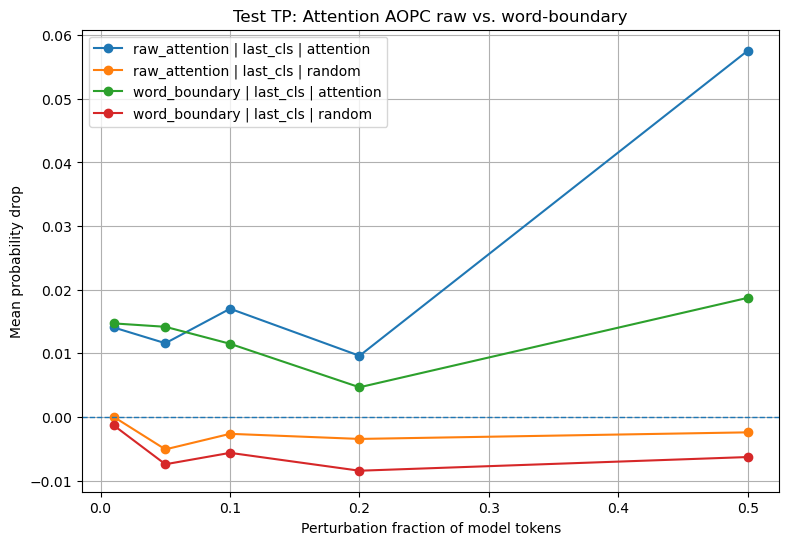

Saved plot: attention_results_aopc/aopc_ranking_evaluation/attention_aopc_test_tp_raw_vs_word_boundary_curve.png


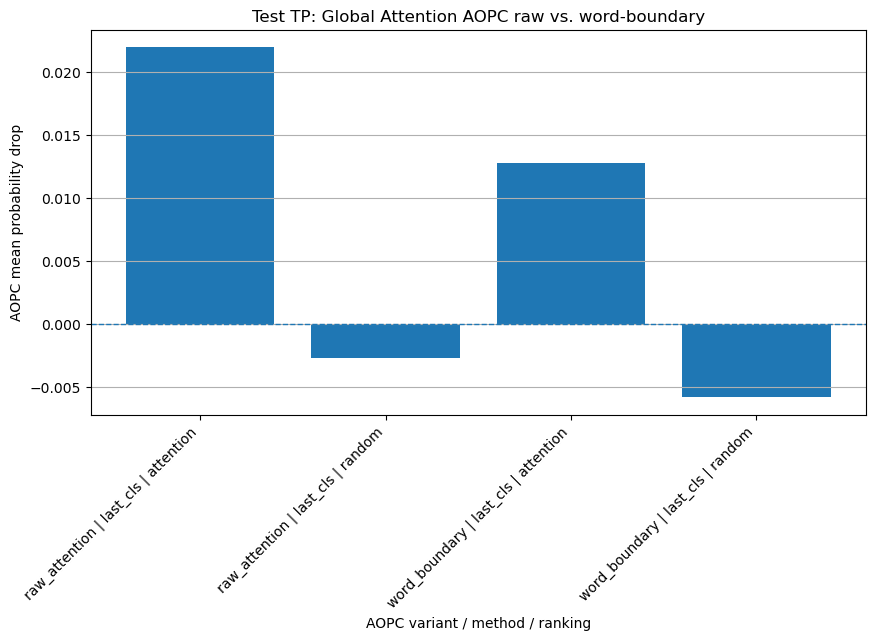

Saved plot: attention_results_aopc/aopc_ranking_evaluation/attention_aopc_test_tp_raw_vs_word_boundary_global_bar.png


In [69]:
test_aopc_curve_summary_combined = pd.concat(
    [
        test_aopc_raw_curve_summary,
        test_aopc_word_boundary_curve_summary
    ],
    ignore_index=True
)

test_aopc_global_summary_combined = pd.concat(
    [
        test_aopc_raw_global_summary,
        test_aopc_word_boundary_global_summary
    ],
    ignore_index=True
)

display(test_aopc_curve_summary_combined)
display(test_aopc_global_summary_combined)

test_aopc_curve_summary_combined.to_csv(
    AOPC_OUTPUT_DIR / "attention_aopc_test_tp_raw_vs_word_boundary_curve_summary.csv",
    index=False,
    encoding="utf-8"
)

test_aopc_global_summary_combined.to_csv(
    AOPC_OUTPUT_DIR / "attention_aopc_test_tp_raw_vs_word_boundary_global_summary.csv",
    index=False,
    encoding="utf-8"
)

plot_attention_aopc_curve(
    curve_summary=test_aopc_curve_summary_combined,
    output_dir=AOPC_OUTPUT_DIR,
    filename="attention_aopc_test_tp_raw_vs_word_boundary_curve.png",
    title="Test TP: Attention AOPC raw vs. word-boundary"
)

plot_attention_aopc_global_bar(
    global_summary=test_aopc_global_summary_combined,
    output_dir=AOPC_OUTPUT_DIR,
    filename="attention_aopc_test_tp_raw_vs_word_boundary_global_bar.png",
    title="Test TP: Global Attention AOPC raw vs. word-boundary"
)

In [70]:
dev_config_comparison = dev_config_summary.merge(
    dev_config_summary_word_boundary,
    on=["attention_method", "window_size", "quantile"],
    how="inner",
    suffixes=("_raw", "_word_boundary")
)

dev_config_comparison["mean_prob_drop_diff_word_boundary_minus_raw"] = (
    dev_config_comparison["mean_prob_drop_word_boundary"]
    - dev_config_comparison["mean_prob_drop_raw"]
)

dev_config_comparison["mean_masked_token_ratio_diff_word_boundary_minus_raw"] = (
    dev_config_comparison["mean_masked_token_ratio_word_boundary"]
    - dev_config_comparison["mean_masked_token_ratio_raw"]
)

dev_config_comparison["positive_drop_rate_diff_word_boundary_minus_raw"] = (
    dev_config_comparison["positive_drop_rate_word_boundary"]
    - dev_config_comparison["positive_drop_rate_raw"]
)

comparison_cols = [
    "attention_method",
    "quantile",
    "window_size",
    "mean_prob_drop_raw",
    "mean_prob_drop_word_boundary",
    "mean_prob_drop_diff_word_boundary_minus_raw",
    "mean_masked_token_ratio_raw",
    "mean_masked_token_ratio_word_boundary",
    "mean_masked_token_ratio_diff_word_boundary_minus_raw",
    "positive_drop_rate_raw",
    "positive_drop_rate_word_boundary",
    "positive_drop_rate_diff_word_boundary_minus_raw",
]

display(
    dev_config_comparison[comparison_cols]
    .sort_values("mean_prob_drop_diff_word_boundary_minus_raw", ascending=False)
)

dev_config_comparison.to_csv(
    OUTPUT_DIR / "attention_dev_config_comparison_raw_vs_word_boundary.csv",
    index=False,
    encoding="utf-8"
)

,attention_method,quantile,window_size,mean_prob_drop_raw,mean_prob_drop_word_boundary,mean_prob_drop_diff_word_boundary_minus_raw,mean_masked_token_ratio_raw,mean_masked_token_ratio_word_boundary,mean_masked_token_ratio_diff_word_boundary_minus_raw,positive_drop_rate_raw,positive_drop_rate_word_boundary,positive_drop_rate_diff_word_boundary_minus_raw
63,rollout,0.30,3,0.323902,0.337927,0.014025,0.934173,0.910289,-0.023885,0.983963,0.980527,-0.003436
24,last_cls,0.85,2,0.020069,0.021834,0.001765,0.186859,0.152811,-0.034049,0.901489,0.860252,-0.041237
33,last_cls,0.85,3,0.021096,0.022712,0.001616,0.206784,0.171382,-0.035401,0.899198,0.856816,-0.042383
32,last_cls,0.80,3,0.019837,0.020721,0.000884,0.283034,0.242323,-0.040711,0.894616,0.865979,-0.028637
53,rollout,0.95,1,0.007087,0.007707,0.000620,0.059467,0.052916,-0.006550,0.615120,0.588774,-0.026346
...,...,...,...,...,...,...,...,...,...,...,...,...
1,last_cls,0.40,0,0.158977,0.050718,-0.108259,0.599704,0.551774,-0.047930,0.965636,0.931271,-0.034364
38,rollout,0.50,0,0.141957,0.007233,-0.134724,0.505005,0.431021,-0.073984,0.958763,0.861397,-0.097365
0,last_cls,0.30,0,0.300063,0.096136,-0.203927,0.697161,0.653482,-0.043679,0.979381,0.947308,-0.032073
37,rollout,0.40,0,0.275997,0.030468,-0.245529,0.599708,0.536379,-0.063329,0.972509,0.899198,-0.073310


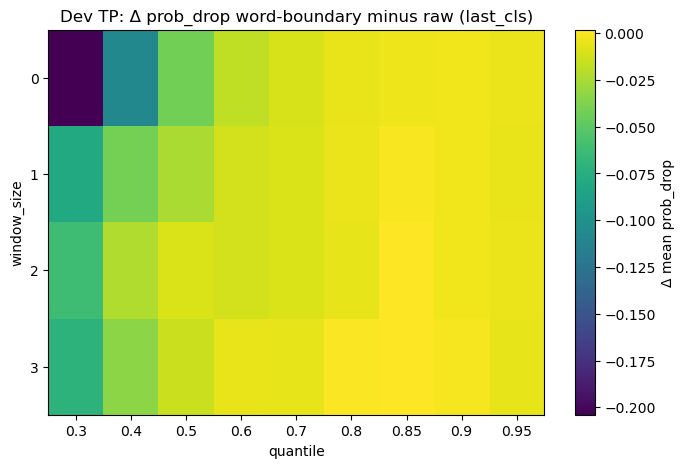

Saved plot: attention_results_aopc/attention_dev_delta_prob_drop_word_boundary_minus_raw_last_cls.png


quantile,0.30,0.40,0.50,0.60,0.70,0.80,0.85,0.90,0.95
window_size,,,,,,,,,
0,-0.203927,-0.108259,-0.041864,-0.017996,-0.011013,-0.005371,-0.003470,-0.002919,-0.003896
1,-0.079235,-0.041391,-0.024374,-0.012365,-0.009733,-0.004078,-0.000459,-0.002510,-0.005450
2,-0.062144,-0.022533,-0.010210,-0.012165,-0.010121,-0.005980,0.001765,-0.002277,-0.004245
3,-0.071014,-0.033641,-0.014913,-0.004979,-0.005532,0.000884,0.001616,-0.001448,-0.005475


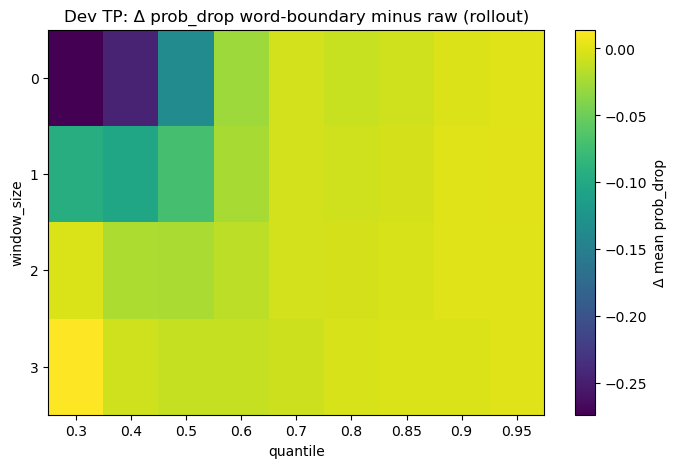

Saved plot: attention_results_aopc/attention_dev_delta_prob_drop_word_boundary_minus_raw_rollout.png


quantile,0.30,0.40,0.50,0.60,0.70,0.80,0.85,0.90,0.95
window_size,,,,,,,,,
0,-0.273701,-0.245529,-0.134724,-0.027564,-0.005982,-0.009815,-0.007169,-0.001357,0.000145
1,-0.094189,-0.104930,-0.070829,-0.023952,-0.005414,-0.007042,-0.004952,0.000177,0.000620
2,-0.002715,-0.021050,-0.022290,-0.014173,-0.005778,-0.004984,-0.003891,-0.000337,0.000195
3,0.014025,-0.006654,-0.011229,-0.011238,-0.008222,-0.003474,-0.002400,-0.002321,-0.000481


In [71]:
for method in sorted(dev_config_comparison["attention_method"].unique()):
    method_df = dev_config_comparison[
        dev_config_comparison["attention_method"] == method
    ].copy()
    
    heatmap_data = method_df.pivot(
        index="window_size",
        columns="quantile",
        values="mean_prob_drop_diff_word_boundary_minus_raw"
    )
    
    plt.figure(figsize=(8, 5))
    plt.imshow(heatmap_data, aspect="auto")
    plt.colorbar(label="Δ mean prob_drop")
    
    plt.xticks(
        ticks=np.arange(len(heatmap_data.columns)),
        labels=heatmap_data.columns
    )
    plt.yticks(
        ticks=np.arange(len(heatmap_data.index)),
        labels=heatmap_data.index
    )
    
    plt.xlabel("quantile")
    plt.ylabel("window_size")
    plt.title(f"Dev TP: Δ prob_drop word-boundary minus raw ({method})")
    
    plot_path = OUTPUT_DIR / f"attention_dev_delta_prob_drop_word_boundary_minus_raw_{method}.png"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Saved plot:", plot_path)
    display(heatmap_data)

In [72]:
test_raw_selected_results = run_attention_config_on_indices(
    df=test_df,
    matrix_positions=list(range(len(test_df))),
    attention_methods=[BEST_ATTENTION_METHOD],
    quantile_values=[BEST_QUANTILE],
    window_size_values=[BEST_WINDOW_SIZE],
    mask_token=MASK_TOKEN
)

test_raw_selected_argument_df = build_argument_level_df(test_raw_selected_results)
test_raw_selected_span_df = build_span_level_df(test_raw_selected_results)

display(test_raw_selected_argument_df.head())
display(test_raw_selected_span_df.head())

Building attention spans:   0%|          | 0/438 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/28 [00:00<?, ?it/s]

,global_row_id,split,post_id,issue,label,predicted_label,predicted_score,confusion_type,is_true_positive,is_false_negative,...,merged_span_texts,merged_span_token_start_indices,merged_span_token_end_indices,merged_span_char_start_indices,merged_span_char_end_indices,selected_tokens_json,merged_spans_json,text,masked_text,error
0,1753,test,0,Is the school uniform a good or bad idea:,1,LABEL_0,0.892726,FN,False,True,...,"[students should wear, they, and feel, clothes]","[1, 5, 7, 12]","[3, 5, 8, 12]","[0, 26, 36, 62]","[20, 30, 44, 69]","[""▁students"", ""▁should"", ""▁wear"", ""▁they"", ""▁a...","[{""char_start"": 0, ""char_end"": 20, ""token_star...",students should wear what they like and feel f...,[MASK] [MASK] [MASK] what [MASK] like [MASK] [...,None
1,1754,test,8,Tv is better than books:,1,LABEL_1,0.997475,TP,True,False,...,"[I thick that book are better than TV is, i, y...","[1, 13, 16, 18, 24]","[9, 13, 16, 18, 27]","[0, 53, 63, 70, 91]","[39, 54, 66, 71, 112]","[""▁I"", ""▁thick"", ""▁that"", ""▁book"", ""▁are"", ""▁b...","[{""char_start"": 0, ""char_end"": 39, ""token_star...",I thick that book are better than TV is it is ...,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None
2,1755,test,9,Tv is better than books:,1,LABEL_1,0.998255,TP,True,False,...,[Books enlighten the soul. Books don't destroy...,"[1, 21, 23, 25, 35, 41, 48, 53, 55, 57, 61, 63...","[16, 21, 23, 25, 38, 44, 49, 53, 55, 59, 61, 6...","[0, 96, 105, 117, 169, 196, 235, 261, 269, 282...","[75, 97, 107, 118, 183, 214, 244, 262, 271, 29...","[""▁Books"", ""▁enlighten"", ""▁the"", ""▁soul"", ""."",...","[{""char_start"": 0, ""char_end"": 75, ""token_star...",Books enlighten the soul. Books don't destroy ...,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None
3,1756,test,12,India has the potential to lead the world:,1,LABEL_1,0.995627,TP,True,False,...,"[india is is, but a, developer and, should, a,...","[1, 6, 9, 12, 14, 16]","[3, 7, 10, 12, 14, 16]","[0, 25, 35, 56, 66, 74]","[11, 30, 48, 62, 67, 83]","[""▁india"", ""▁is"", ""▁is"", ""▁but"", ""▁a"", ""▁devel...","[{""char_start"": 0, ""char_end"": 11, ""token_star...",india is is good adopter but a bad developer a...,[MASK] [MASK] [MASK] good adopter [MASK] [MASK...,None
4,1757,test,15,Is it better to have a lousy father or to be f...,0,LABEL_0,0.993661,TN,False,False,...,"[Honestly, I'd rather be completely, less, not...","[1, 10, 16, 27, 38, 40, 48, 50, 54, 57, 65, 75...","[8, 12, 17, 36, 38, 40, 48, 52, 55, 63, 67, 76...","[0, 41, 67, 119, 164, 181, 224, 234, 254, 272,...","[34, 50, 76, 160, 174, 185, 227, 248, 264, 306...","[""▁Honestly"", "","", ""▁I"", ""'"", ""d"", ""▁rather"", ...","[{""char_start"": 0, ""char_end"": 34, ""token_star...","Honestly, I'd rather be completely fatherless,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None


,global_row_id,split,post_id,issue,label,predicted_label,confusion_type,is_true_positive,is_false_negative,is_false_positive,...,span_score_max_attention,p_inappropriate_original,p_inappropriate_masked,prob_drop,n_model_tokens,n_selected_tokens,selected_token_ratio,masked_token_ratio,text,masked_text
0,1753,test,0,Is the school uniform a good or bad idea:,1,LABEL_0,FN,False,True,False,...,0.141857,0.107274,0.975958,-0.868684,12,7,0.583333,0.583333,students should wear what they like and feel f...,[MASK] [MASK] [MASK] what [MASK] like [MASK] [...
1,1753,test,0,Is the school uniform a good or bad idea:,1,LABEL_0,FN,False,True,False,...,0.076449,0.107274,0.975958,-0.868684,12,7,0.583333,0.583333,students should wear what they like and feel f...,[MASK] [MASK] [MASK] what [MASK] like [MASK] [...
2,1753,test,0,Is the school uniform a good or bad idea:,1,LABEL_0,FN,False,True,False,...,0.116373,0.107274,0.975958,-0.868684,12,7,0.583333,0.583333,students should wear what they like and feel f...,[MASK] [MASK] [MASK] what [MASK] like [MASK] [...
3,1753,test,0,Is the school uniform a good or bad idea:,1,LABEL_0,FN,False,True,False,...,0.116921,0.107274,0.975958,-0.868684,12,7,0.583333,0.583333,students should wear what they like and feel f...,[MASK] [MASK] [MASK] what [MASK] like [MASK] [...
4,1754,test,8,Tv is better than books:,1,LABEL_1,TP,True,False,False,...,0.168771,0.997475,0.975725,0.021751,27,16,0.592593,0.592593,I thick that book are better than TV is it is ...,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...


In [73]:
test_raw_vs_word_boundary = test_raw_selected_argument_df.merge(
    test_argument_df,
    on="global_row_id",
    how="inner",
    suffixes=("_raw", "_word_boundary")
)

test_raw_vs_word_boundary_tp = test_raw_vs_word_boundary[
    test_raw_vs_word_boundary["confusion_type_word_boundary"] == "TP"
].copy()

test_raw_vs_word_boundary_tp["prob_drop_diff_word_boundary_minus_raw"] = (
    test_raw_vs_word_boundary_tp["prob_drop_word_boundary"]
    - test_raw_vs_word_boundary_tp["prob_drop_raw"]
)

test_raw_vs_word_boundary_tp["masked_token_ratio_diff_word_boundary_minus_raw"] = (
    test_raw_vs_word_boundary_tp["masked_token_ratio_word_boundary"]
    - test_raw_vs_word_boundary_tp["masked_token_ratio_raw"]
)

display(
    test_raw_vs_word_boundary_tp[
        [
            "global_row_id",
            "post_id_word_boundary",
            "prob_drop_raw",
            "prob_drop_word_boundary",
            "prob_drop_diff_word_boundary_minus_raw",
            "masked_token_ratio_raw",
            "masked_token_ratio_word_boundary",
            "masked_token_ratio_diff_word_boundary_minus_raw",
            "merged_span_texts_raw",
            "merged_span_texts_word_boundary",
        ]
    ].sort_values("prob_drop_diff_word_boundary_minus_raw", ascending=False)
)

test_raw_vs_word_boundary_tp.to_csv(
    OUTPUT_DIR / "attention_test_tp_raw_vs_word_boundary_paired_comparison.csv",
    index=False,
    encoding="utf-8"
)

,global_row_id,post_id_word_boundary,prob_drop_raw,prob_drop_word_boundary,prob_drop_diff_word_boundary_minus_raw,masked_token_ratio_raw,masked_token_ratio_word_boundary,masked_token_ratio_diff_word_boundary_minus_raw,merged_span_texts_raw,merged_span_texts_word_boundary
279,2032,1341,0.335488,0.558890,0.223402,0.601942,0.524272,-0.077670,[What?!? And all these years I've been paying....,[What?!? And all these years I've been paying....
282,2035,1357,0.460162,0.638583,0.178421,0.603774,0.537736,-0.066038,"[Marriage is a business, and the license makes...","[Marriage is a business, and the license makes..."
433,2186,2153,0.665764,0.766855,0.101091,0.604167,0.520833,-0.083333,"[Hope that didn't come, as, crazy sounding or ...","[Hope that didn't come, as, crazy sounding or ..."
234,1987,1137,0.081930,0.162179,0.080250,0.601695,0.610169,0.008475,[What - is God coming in the year 2100 to judg...,[What - is God coming in the year 2100 to judg...
318,2071,1574,-0.370510,-0.311955,0.058554,0.611111,0.333333,-0.277778,"[All TV shows are, scripts (, ) first...]","[All TV shows are, scripts, first]"
...,...,...,...,...,...,...,...,...,...,...
102,1855,489,0.610674,0.008851,-0.601824,0.600000,0.560000,-0.040000,[The scientific rigor you mention is not prese...,[The scientific rigor you mention is not prese...
400,2153,1980,0.608690,0.001706,-0.606984,0.598985,0.532995,-0.065990,"[Yes, in North Carolina, there is a three day ...","[Yes, in North Carolina, there is a three day ..."
60,1813,291,0.599458,-0.007704,-0.607162,0.600000,0.466667,-0.133333,[Anything intelligence created by a more intel...,[Anything intelligence created by a more intel...
254,2007,1241,0.639754,0.024106,-0.615648,0.598985,0.588832,-0.010152,[Violence is perpetuated and caused by society...,[Violence is perpetuated and caused by society...


In [74]:
test_raw_vs_word_boundary_summary = pd.DataFrame([
    {
        "variant": "raw_attention",
        "n_arguments": test_raw_vs_word_boundary_tp["global_row_id"].nunique(),
        "mean_prob_drop": test_raw_vs_word_boundary_tp["prob_drop_raw"].mean(),
        "median_prob_drop": test_raw_vs_word_boundary_tp["prob_drop_raw"].median(),
        "positive_drop_rate": (test_raw_vs_word_boundary_tp["prob_drop_raw"] > 0).mean(),
        "mean_masked_token_ratio": test_raw_vs_word_boundary_tp["masked_token_ratio_raw"].mean(),
        "mean_n_merged_spans": test_raw_vs_word_boundary_tp["n_merged_spans_raw"].mean(),
    },
    {
        "variant": "word_boundary",
        "n_arguments": test_raw_vs_word_boundary_tp["global_row_id"].nunique(),
        "mean_prob_drop": test_raw_vs_word_boundary_tp["prob_drop_word_boundary"].mean(),
        "median_prob_drop": test_raw_vs_word_boundary_tp["prob_drop_word_boundary"].median(),
        "positive_drop_rate": (test_raw_vs_word_boundary_tp["prob_drop_word_boundary"] > 0).mean(),
        "mean_masked_token_ratio": test_raw_vs_word_boundary_tp["masked_token_ratio_word_boundary"].mean(),
        "mean_n_merged_spans": test_raw_vs_word_boundary_tp["n_merged_spans_word_boundary"].mean(),
    }
])

display(test_raw_vs_word_boundary_summary)

test_raw_vs_word_boundary_summary.to_csv(
    OUTPUT_DIR / "attention_test_tp_raw_vs_word_boundary_summary.csv",
    index=False,
    encoding="utf-8"
)

,variant,n_arguments,mean_prob_drop,median_prob_drop,positive_drop_rate,mean_masked_token_ratio,mean_n_merged_spans
0,raw_attention,186,0.136776,0.037209,0.951613,0.600029,16.010753
1,word_boundary,186,0.035410,0.003776,0.919355,0.548492,14.010753


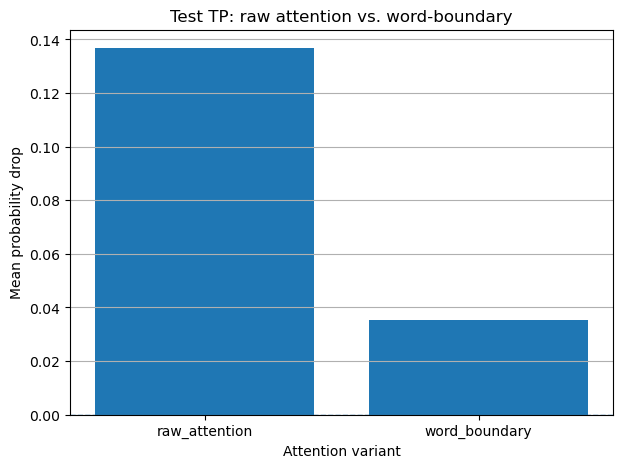

Saved plot: attention_results_aopc/attention_test_tp_raw_vs_word_boundary_mean_prob_drop_bar.png


In [75]:
plot_df = test_raw_vs_word_boundary_summary.copy()

plt.figure(figsize=(7, 5))

plt.bar(
    plot_df["variant"],
    plot_df["mean_prob_drop"]
)

plt.axhline(0.0, linestyle="--", linewidth=1)
plt.xlabel("Attention variant")
plt.ylabel("Mean probability drop")
plt.title("Test TP: raw attention vs. word-boundary")
plt.grid(axis="y")

plot_path = OUTPUT_DIR / "attention_test_tp_raw_vs_word_boundary_mean_prob_drop_bar.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)

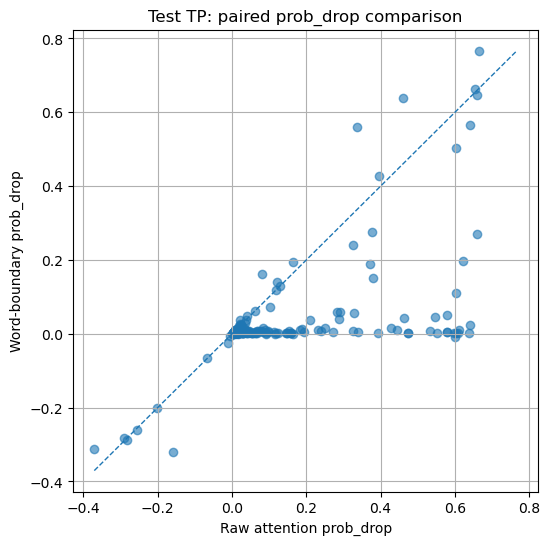

Saved plot: attention_results_aopc/attention_test_tp_raw_vs_word_boundary_paired_prob_drop_scatter.png


In [76]:
plt.figure(figsize=(6, 6))

plt.scatter(
    test_raw_vs_word_boundary_tp["prob_drop_raw"],
    test_raw_vs_word_boundary_tp["prob_drop_word_boundary"],
    alpha=0.6
)

min_val = min(
    test_raw_vs_word_boundary_tp["prob_drop_raw"].min(),
    test_raw_vs_word_boundary_tp["prob_drop_word_boundary"].min()
)

max_val = max(
    test_raw_vs_word_boundary_tp["prob_drop_raw"].max(),
    test_raw_vs_word_boundary_tp["prob_drop_word_boundary"].max()
)

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", linewidth=1)

plt.xlabel("Raw attention prob_drop")
plt.ylabel("Word-boundary prob_drop")
plt.title("Test TP: paired prob_drop comparison")
plt.grid(True)

plot_path = OUTPUT_DIR / "attention_test_tp_raw_vs_word_boundary_paired_prob_drop_scatter.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)